In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
trainset = pd.read_csv('/content/drive/MyDrive/data-b/trainsetsansregnotfire.csv')
testset = pd.read_csv('/content/drive/MyDrive/data-b/testsetsansregnotfire.csv')

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mode
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import NearMiss
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler


y_test_combined_list = []
predictions = []
random_wafaa_models= []
classes_predictions_finales = []
# Nombre de tuples à inclure dans chaque ensemble
fire_indices = np.where(trainset['fire'] == 1)[0]
fire_samples = len(fire_indices)
print(fire_samples)

#np.where(y_train == 1)[0]

# Liste pour stocker les 100 ensembles de données
data_sets = []
class_1_subset = trainset.iloc[fire_indices]

for i in range(150):

    class_0_subset = trainset[trainset['fire'] == 0].sample(n=fire_samples)
    subset = pd.concat([class_0_subset, class_1_subset])
    data_sets.append(subset)


i=0

for dataset in data_sets:

    print("*******************************************")
    i=i+1
    print("tree:",i)
    # Séparation des caractéristiques et des étiquettes
    X = dataset.drop('fire', axis=1)  # Supprimez la colonne 'fire' pour obtenir les caractéristiques
    y = dataset['fire']  # Obtenez les étiquettes 'fire'

    stratified_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
    for train_index, val_index in stratified_split.split(X,y):
        X_train, X_test = X.iloc[train_index], X.iloc[val_index]
        y_train, y_test = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
        scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
        X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
        X_test = scaler.transform(X_test)

    # Création du modèle d'arbre de décision
        rf_classifier = LogisticRegression(C=0.1, solver='newton-cg', max_iter=1000)
        rf_classifier.fit(X_train, y_train)

    # Prédiction sur l'ensemble de test
        y_pred_rf = rf_classifier.predict(X_test)

        y_test_combined_list.append(y_test)

    # Ajout des prédictions à la liste
        predictions.append(y_pred_rf)

        random_wafaa_models.append(rf_classifier)

    # Évaluation des performances du modèle
        accuracy = accuracy_score(y_test, y_pred_rf)
        precision = precision_score(y_test, y_pred_rf)
        recall = recall_score(y_test, y_pred_rf)
        f1 = f1_score(y_test, y_pred_rf)


        print(f"Accuracy: {accuracy:.2f}")
        print(f"Precision: {precision:.2f}")
        print(f"Recall: {recall:.2f}")
        print(f"F1 Score: {f1:.2f}")

    # Affichage du rapport de classification
        print(classification_report(y_test, y_pred_rf))

    # Matrice de confusion
        cm = confusion_matrix(y_test, y_pred_rf)
        cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
        plt.xlabel('Prédiction')
        plt.ylabel('Vraie Valeur')
        plt.title('Matrice de Confusion Normalisée')
        plt.show()

# Convertir les prédictions en un tableau numpy
predictions_array = np.array(predictions)

# Calculer le mode (vote majoritaire) pour chaque tuple de données
ensemble_predictions = mode(predictions_array, axis=0)[0]

print("*********************************************")
# Boucle pour évaluer chaque ensemble de test combiné sauvegardé
for y_test_combined_saved in y_test_combined_list:
    accuracy = accuracy_score(y_test_combined_saved, ensemble_predictions)
    precision = precision_score(y_test_combined_saved, ensemble_predictions)
    recall = recall_score(y_test_combined_saved, ensemble_predictions)
    f1 = f1_score(y_test_combined_saved, ensemble_predictions)


    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")

    # Affichage du rapport de classification
    print(classification_report(y_test_combined_saved, ensemble_predictions))

    # Matrice de confusion
    cm = confusion_matrix(y_test_combined_saved, ensemble_predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie Valeur')
    plt.title('Matrice de Confusion Normalisée')
    plt.show()
#avec proba ###################################################################################################

for index in range(len(predictions[0])):
    # Initialisez la somme des prédictions pour cet indice
    sum_predictions = 0

    # Pour chaque modèle, ajoutez sa prédiction à la somme
    for i in range(len(predictions)):
        sum_predictions += predictions[i][index]

    # Divisez la somme par le nombre de modèles pour obtenir la prédiction finale pour cet indice
    final_prediction = sum_predictions / len(predictions)

    # Ajoutez la prédiction finale à votre liste de prédictions finales
    ensemble_predictions_avecproba=np.append(ensemble_predictions_avecproba,final_prediction)

seuil_decision = 0.5
classes_predictions_finales = []

for prediction in ensemble_predictions_avecproba:
    classe_prediction = 1 if prediction >= seuil_decision else 0
    classes_predictions_finales.append(classe_prediction)

print("*********************************************")
# Boucle pour évaluer chaque ensemble de test combiné sauvegardé
for y_test_combined_saved in y_test_combined_list:
    accuracy = accuracy_score(y_test_combined_saved, classes_predictions_finales)
    precision = precision_score(y_test_combined_saved, classes_predictions_finales)
    recall = recall_score(y_test_combined_saved, classes_predictions_finales)
    f1 = f1_score(y_test_combined_saved, classes_predictions_finales)


    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")

    # Affichage du rapport de classification
    print(classification_report(y_test_combined_saved, classes_predictions_finales))

    # Matrice de confusion
    cm = confusion_matrix(y_test_combined_saved, classes_predictions_finales)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie Valeur')
    plt.title('Matrice de Confusion Normalisée')
    plt.show()
#avec poinds au recalls#####################################################################################



Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



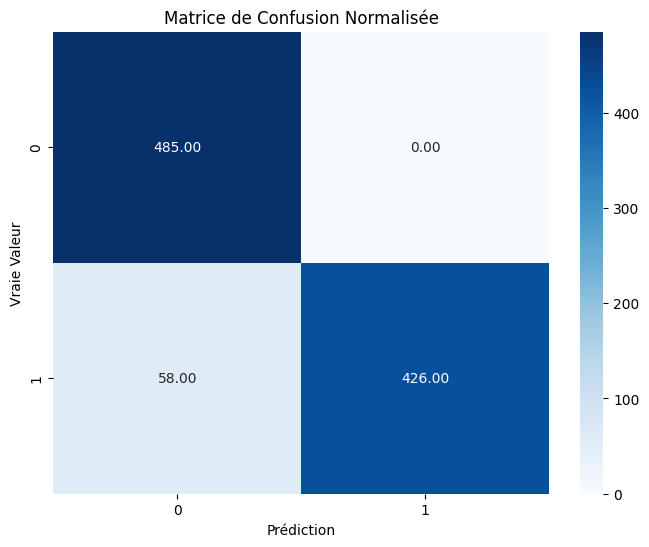

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



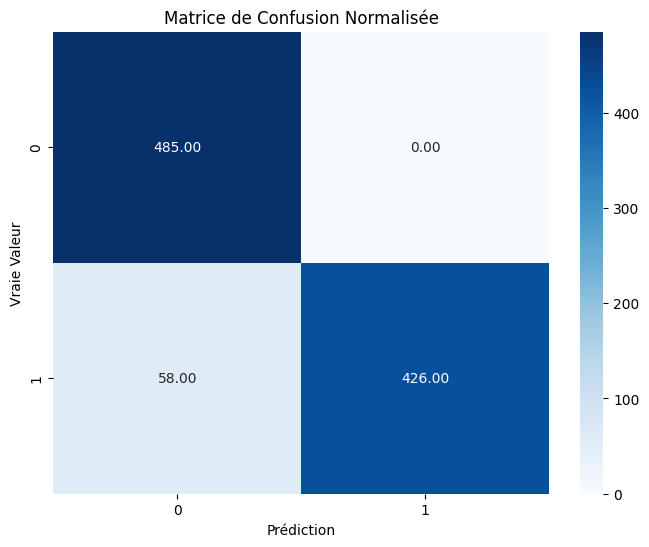

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



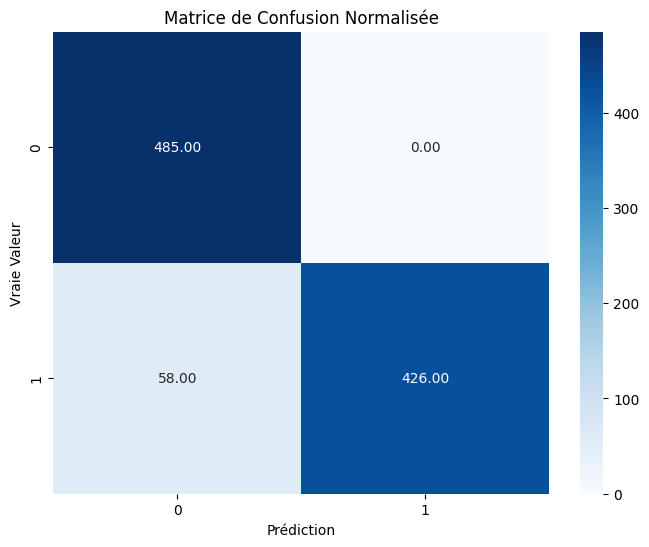

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



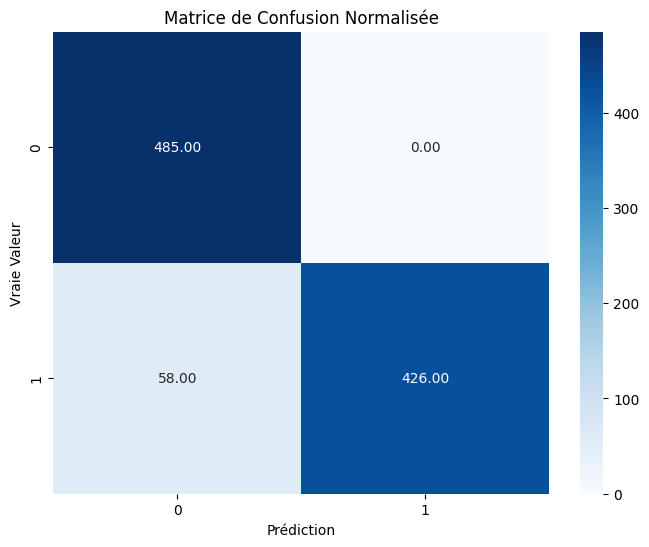

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



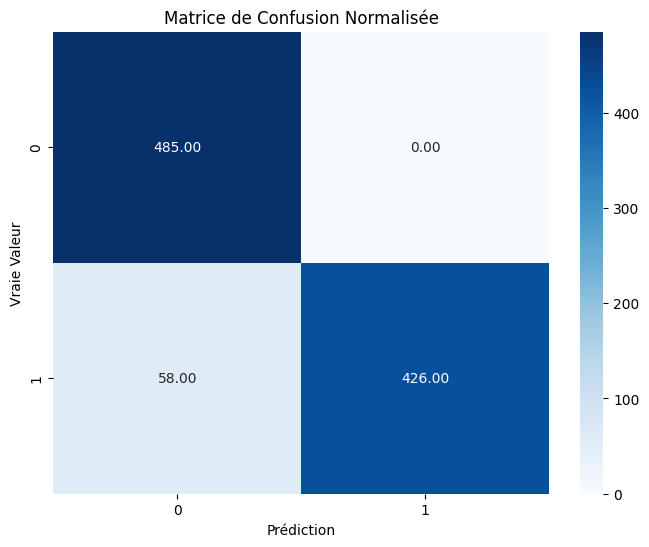

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



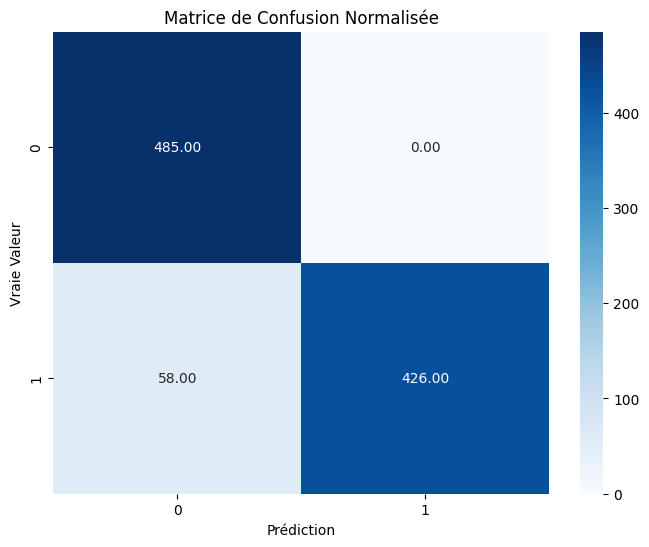

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



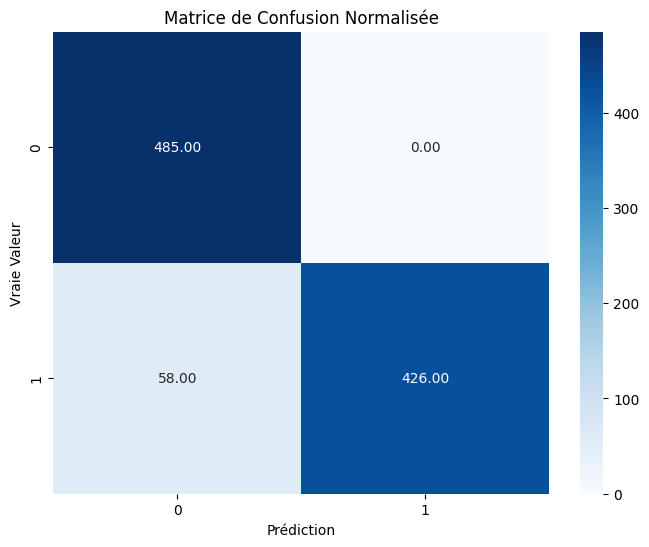

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



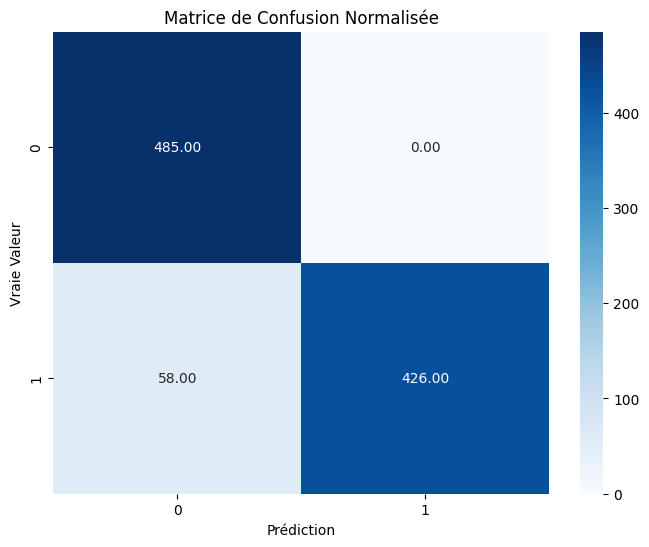

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



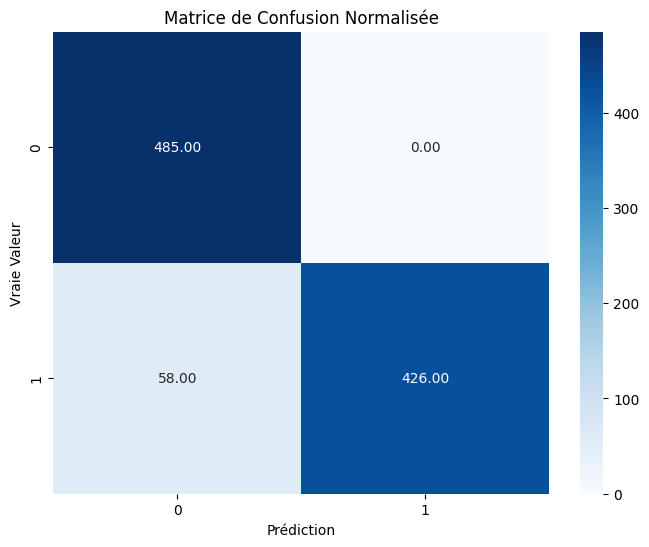

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



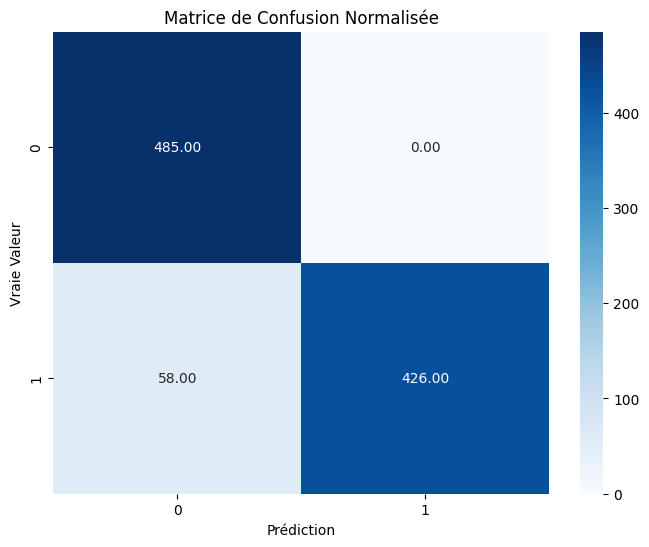

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



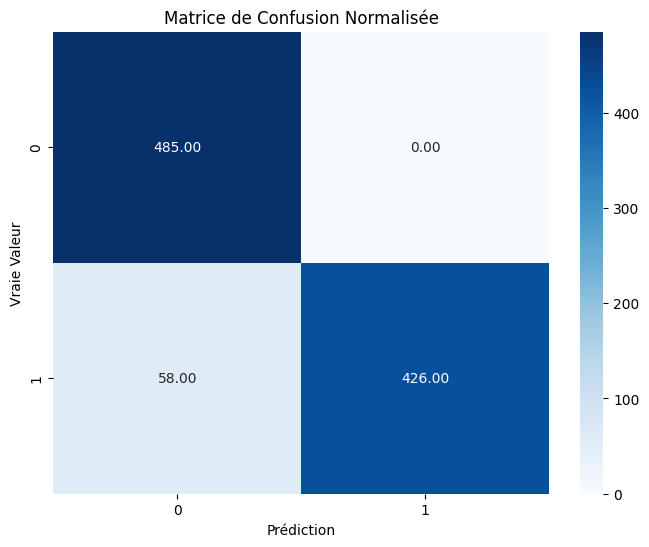

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



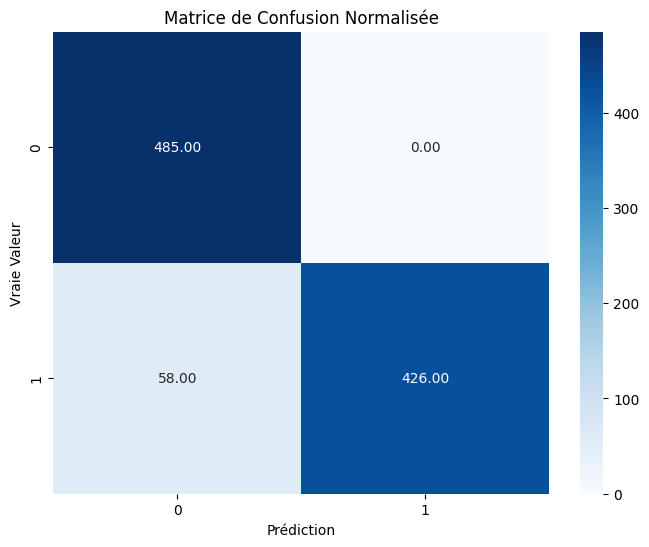

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



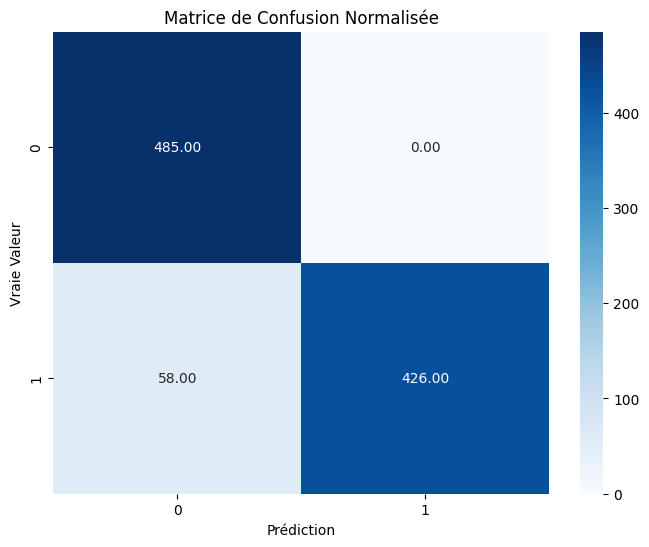

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



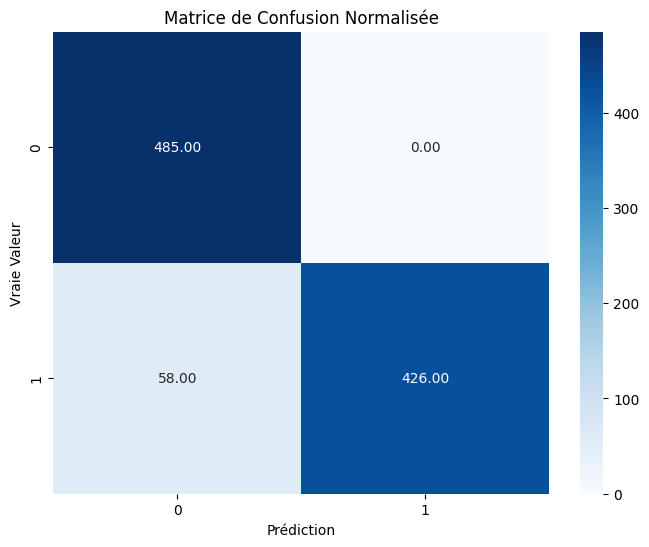

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



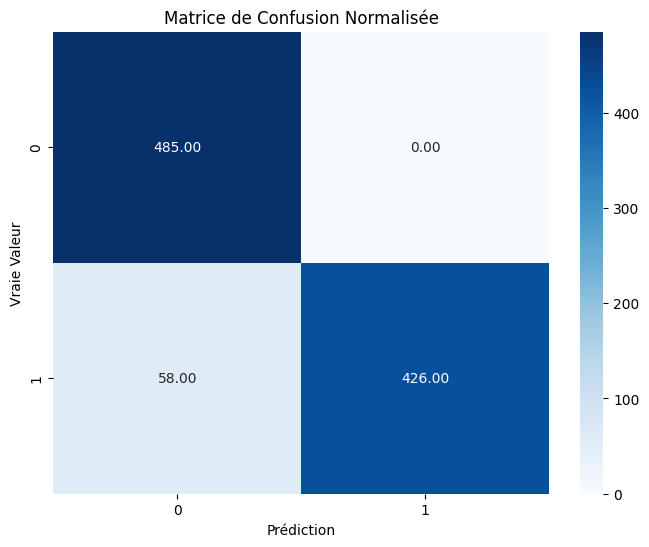

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



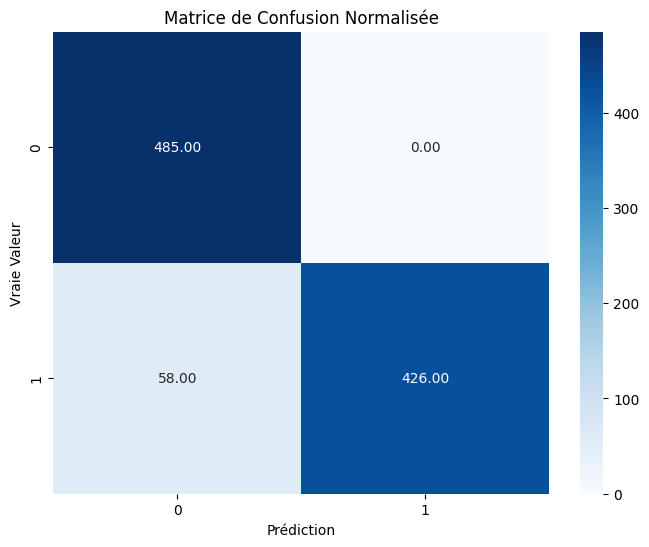

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



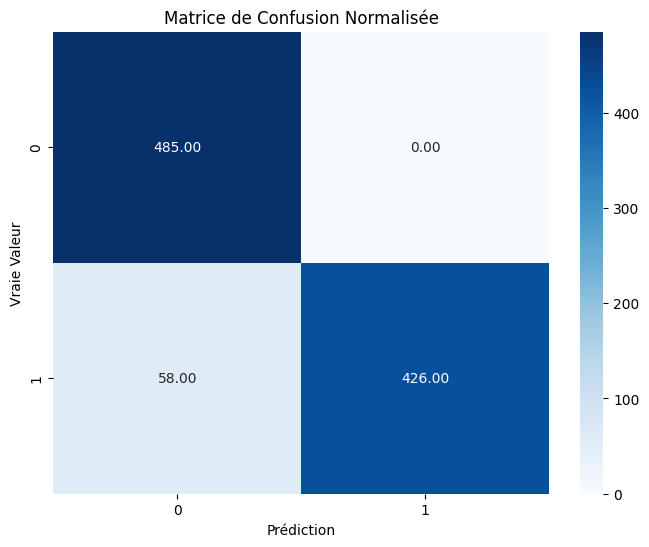

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



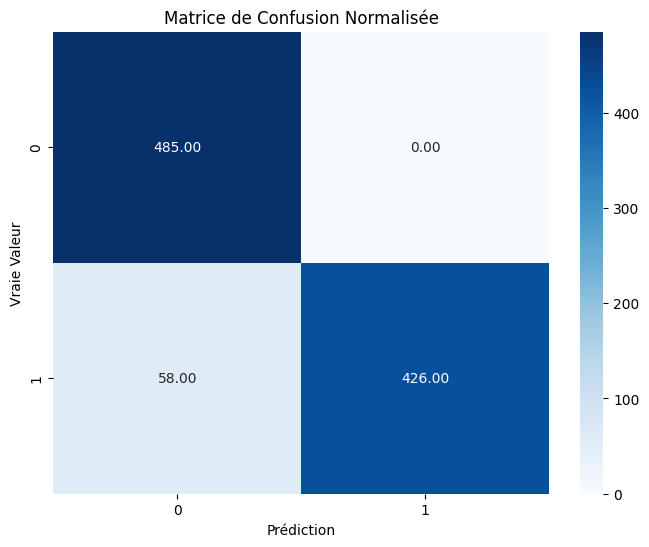

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



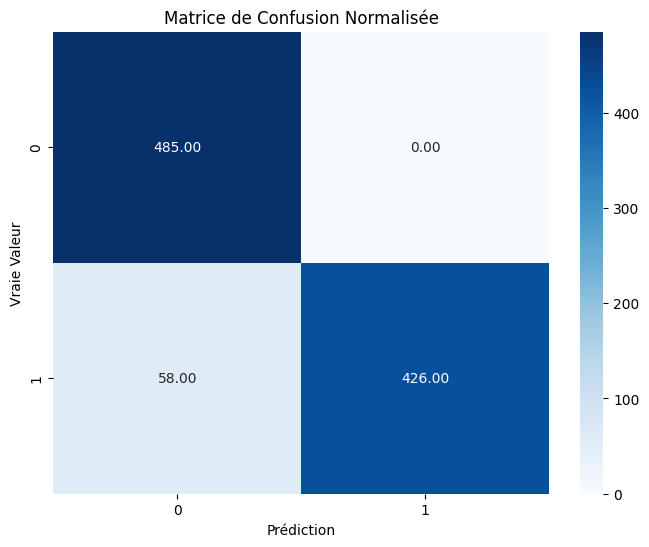

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



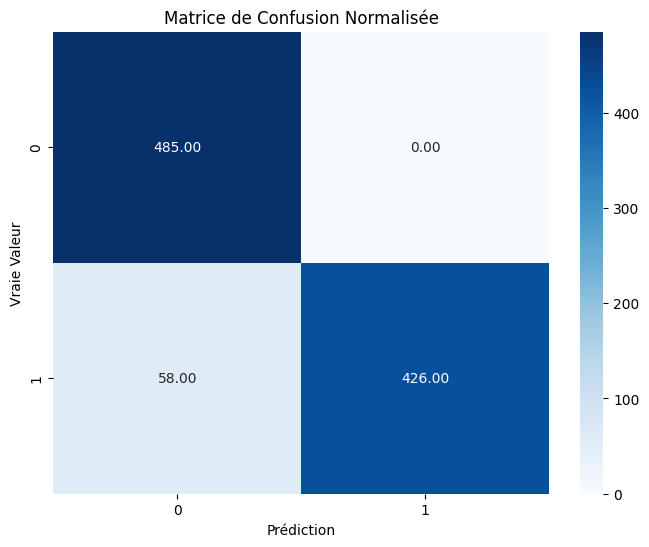

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



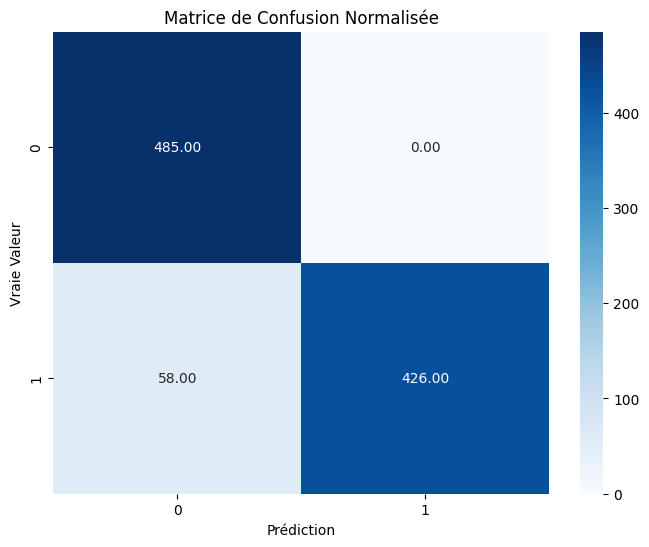

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



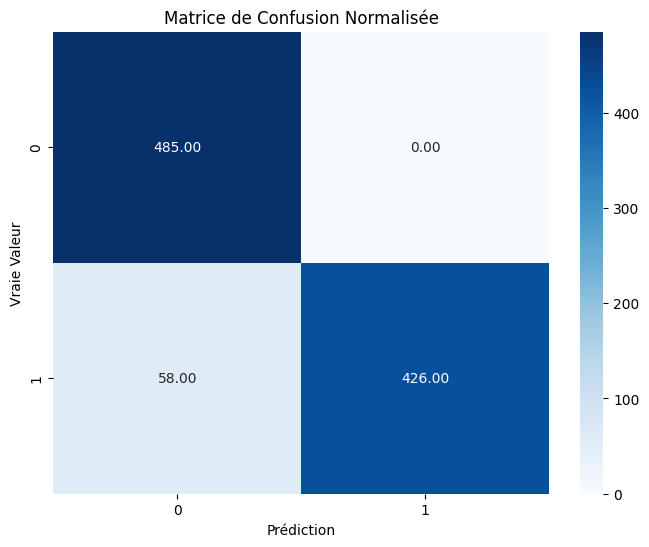

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



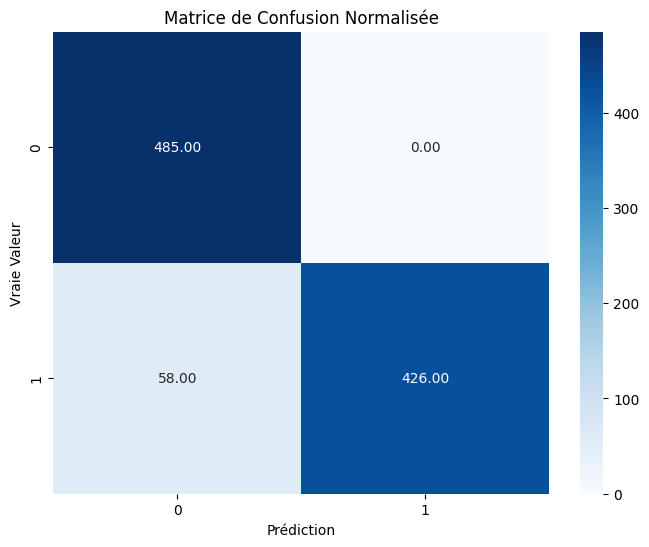

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



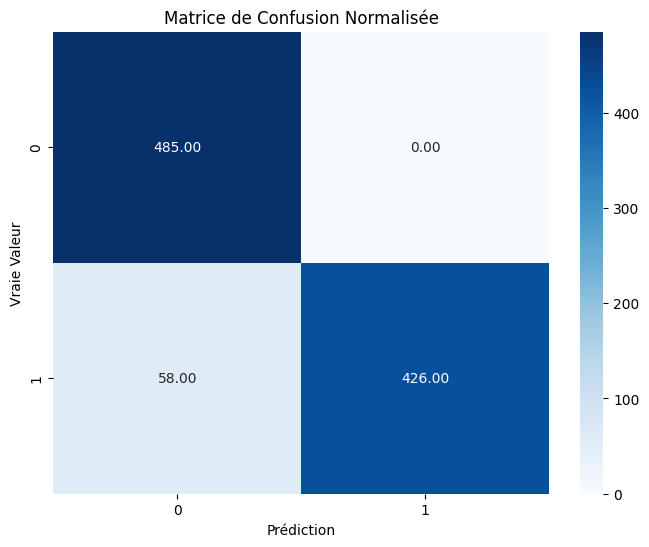

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



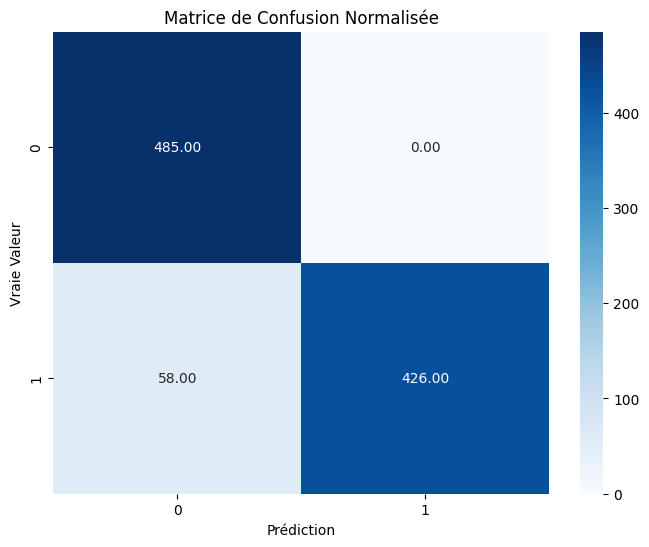

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



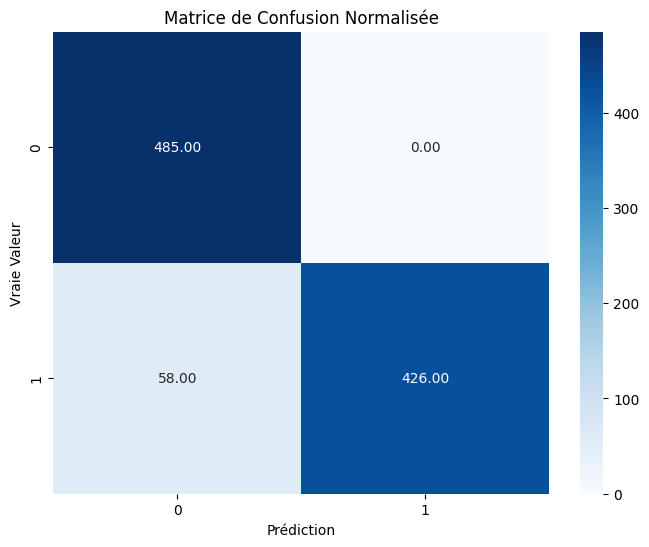

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



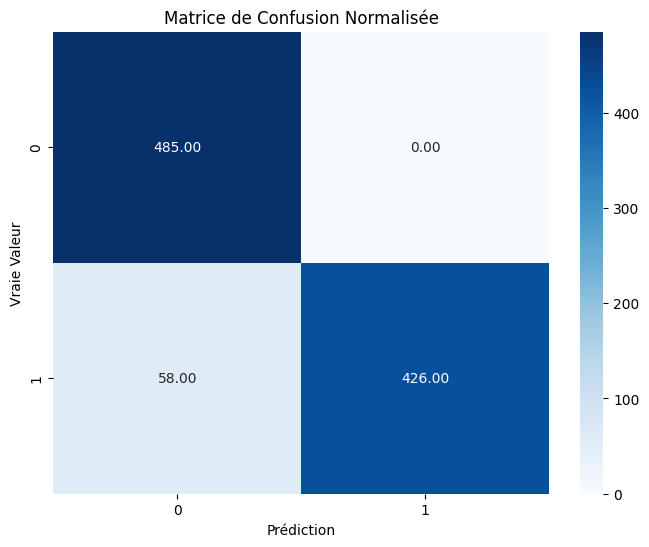

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



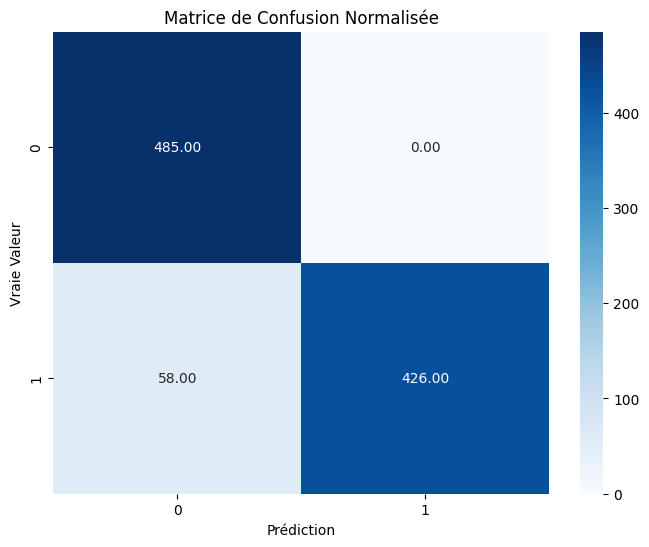

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



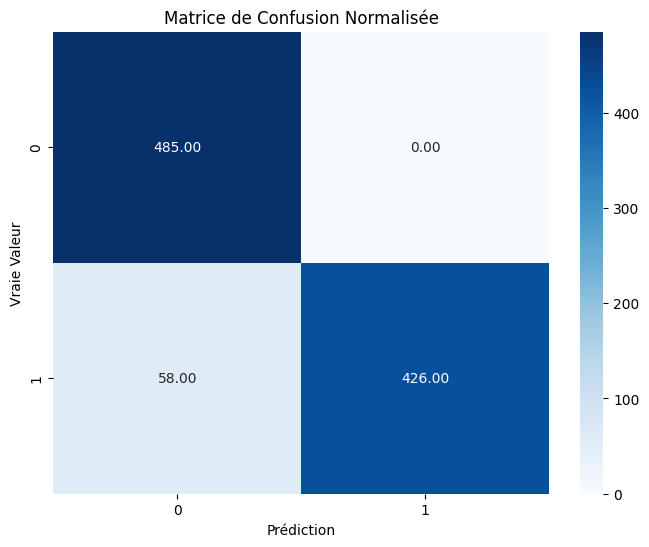

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



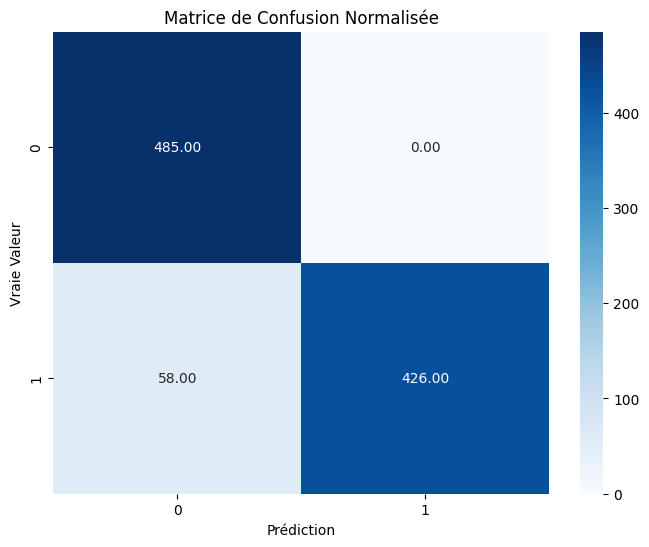

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



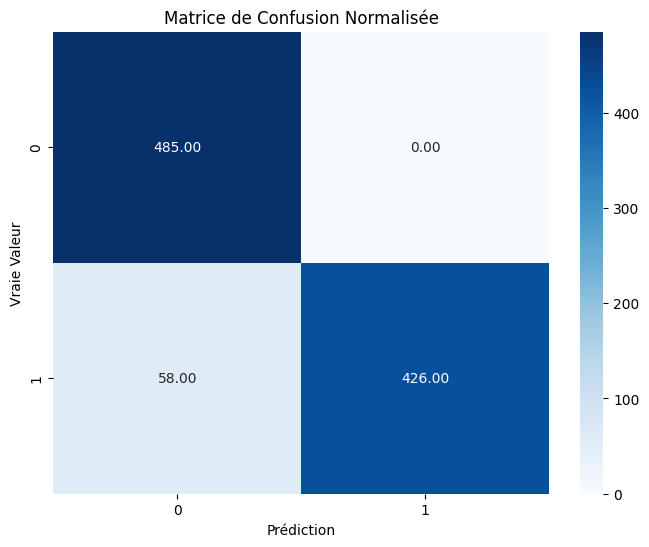

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



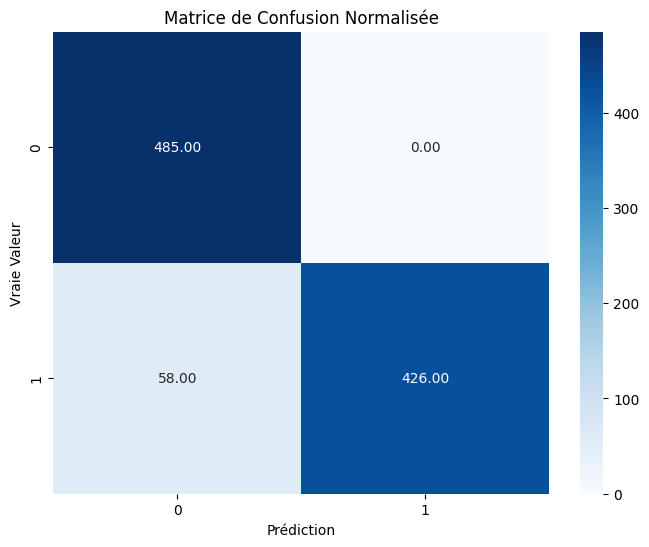

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



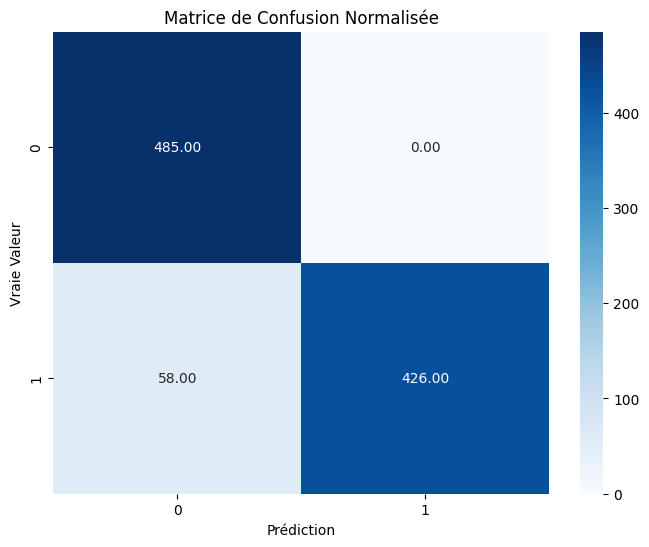

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



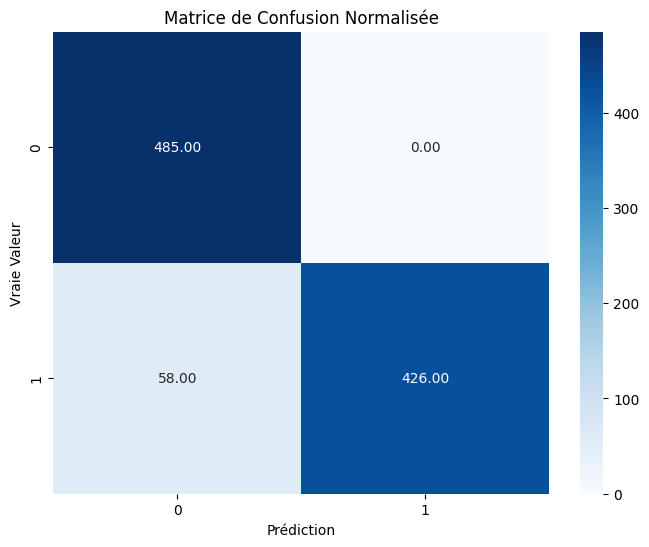

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



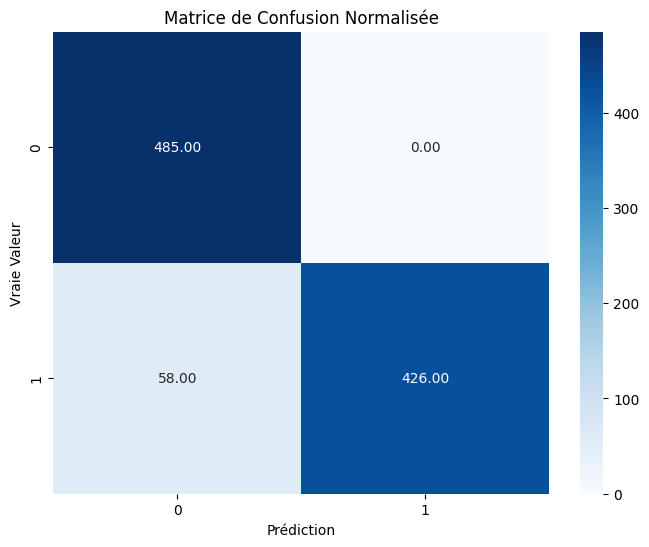

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



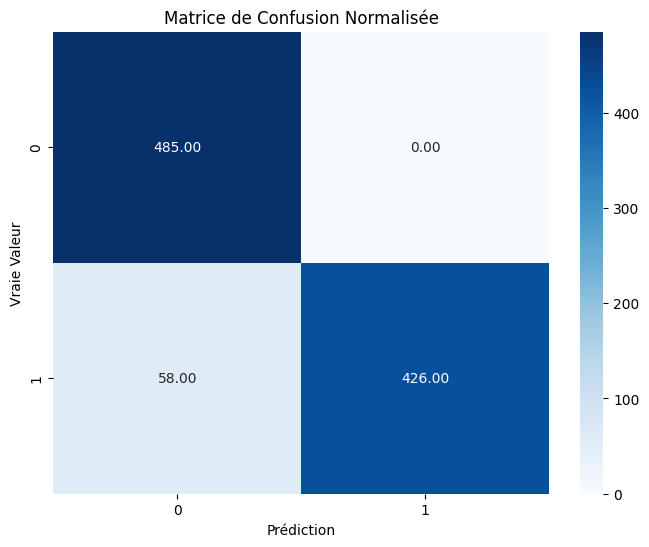

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



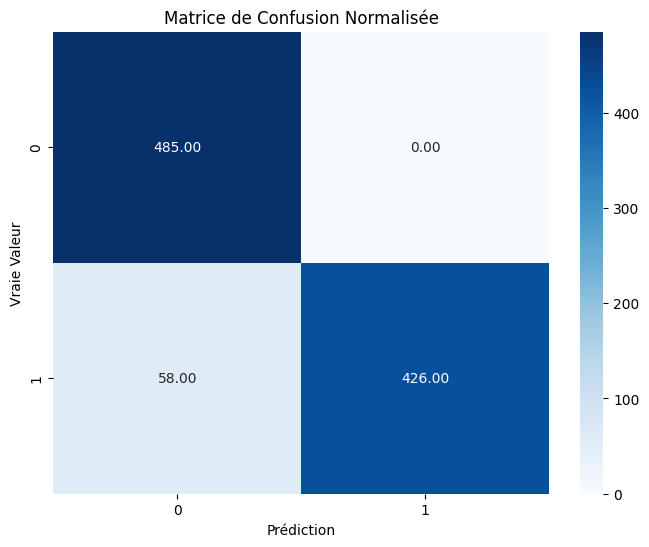

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



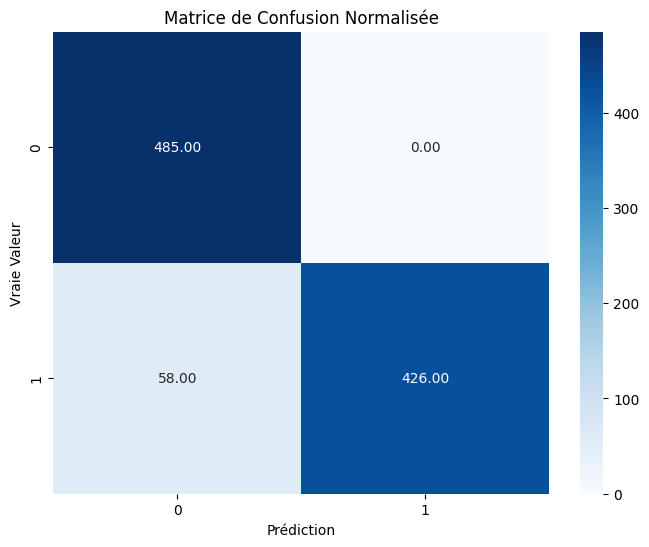

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



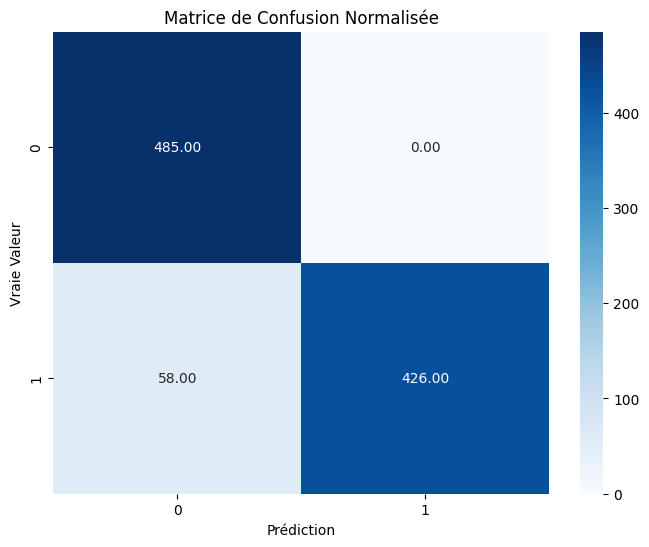

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



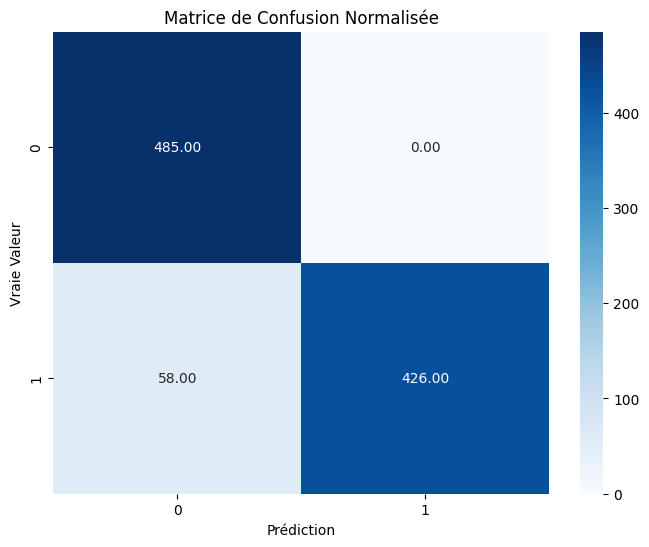

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



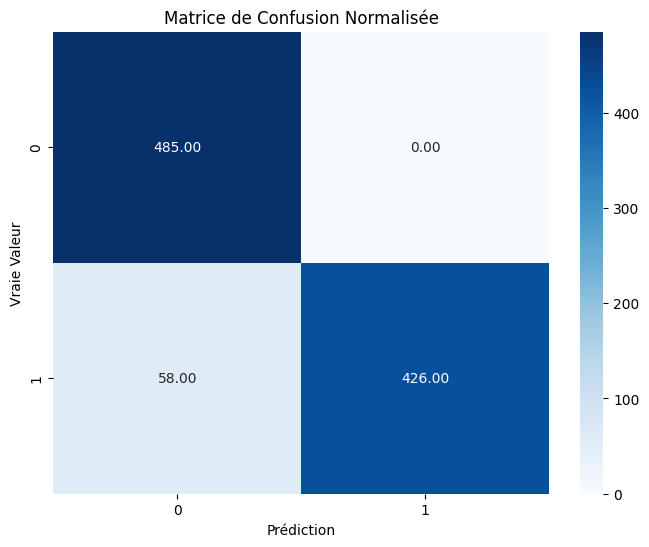

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



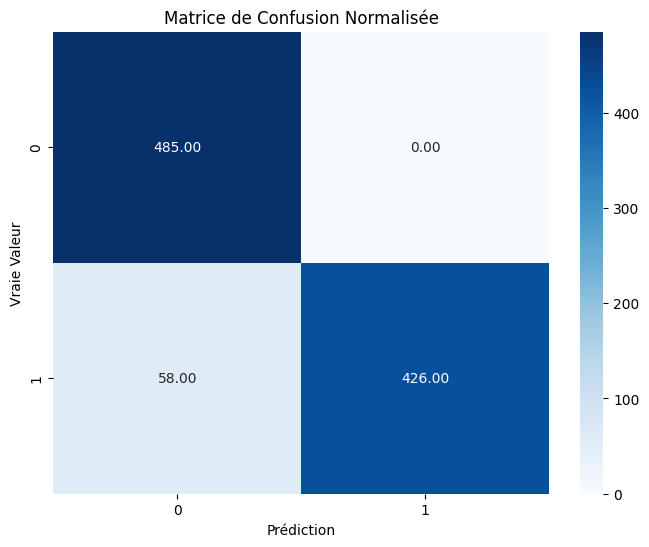

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



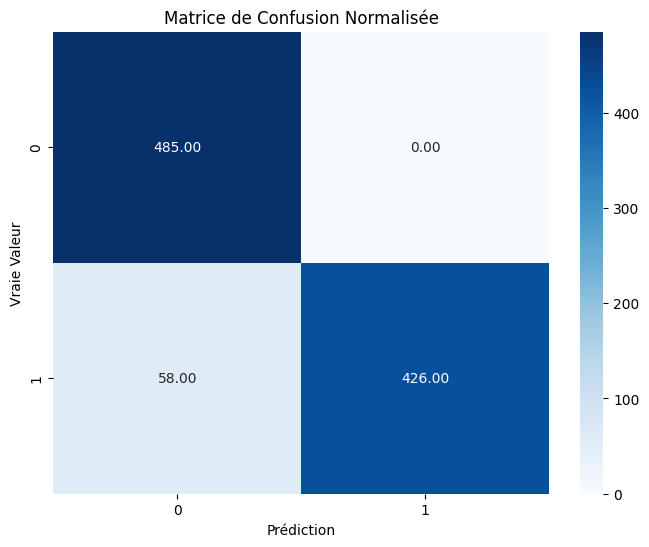

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



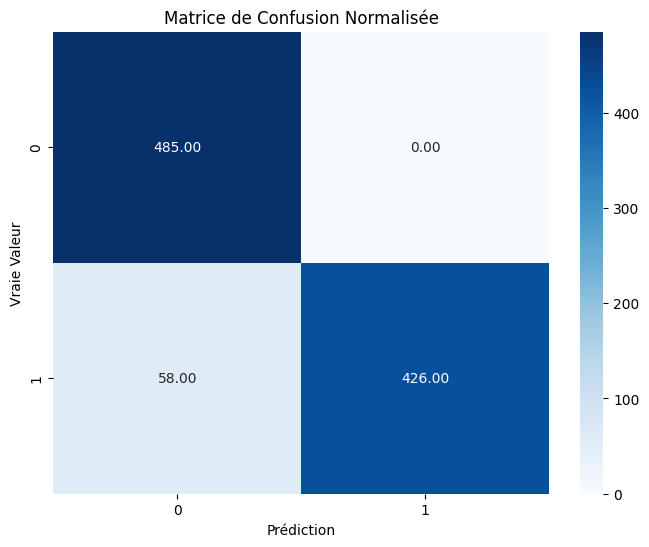

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



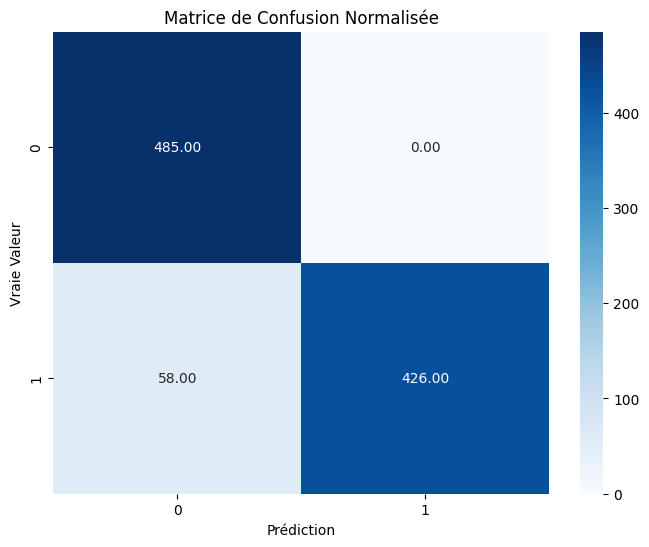

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



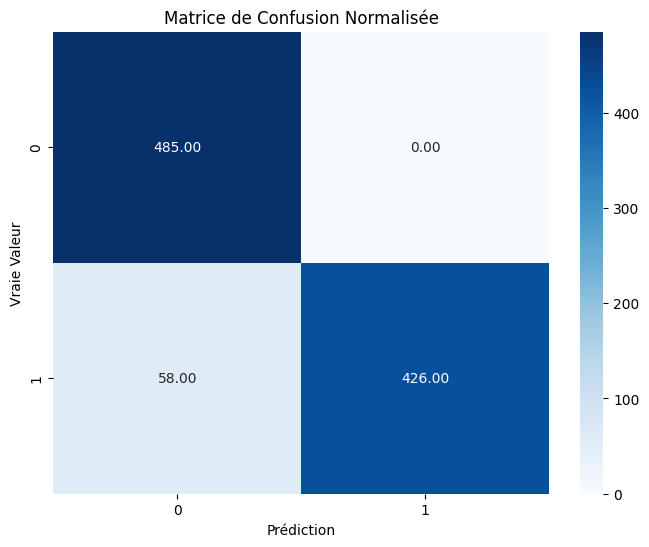

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



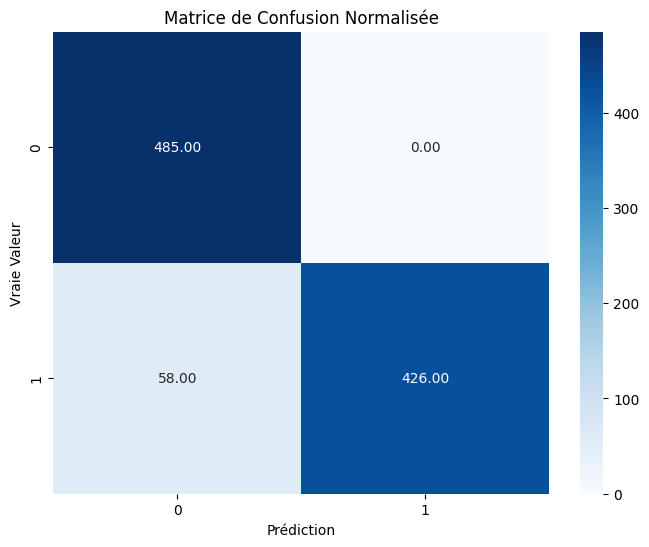

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



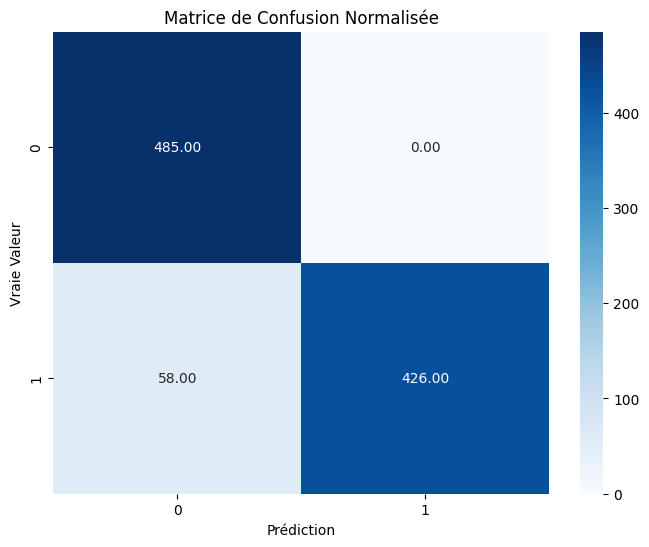

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



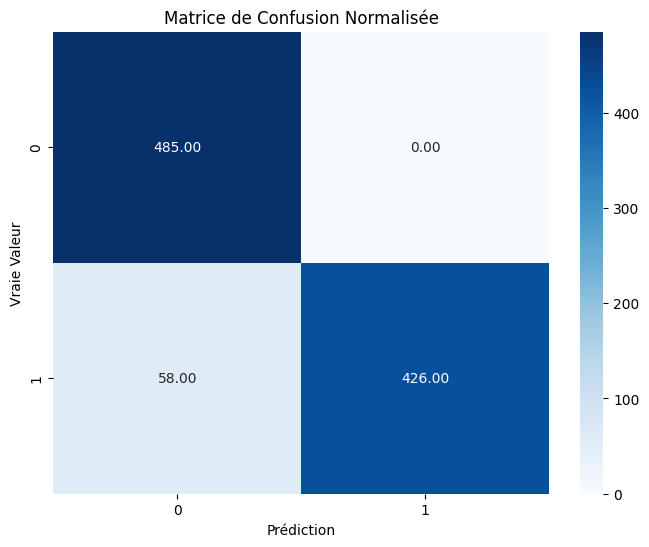

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



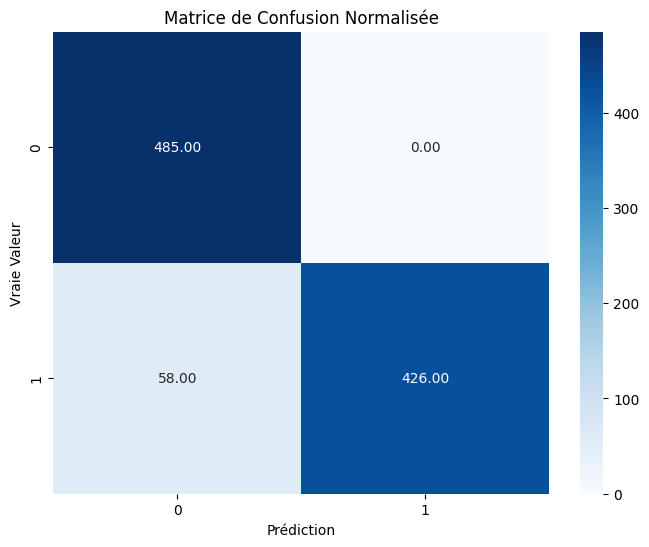

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



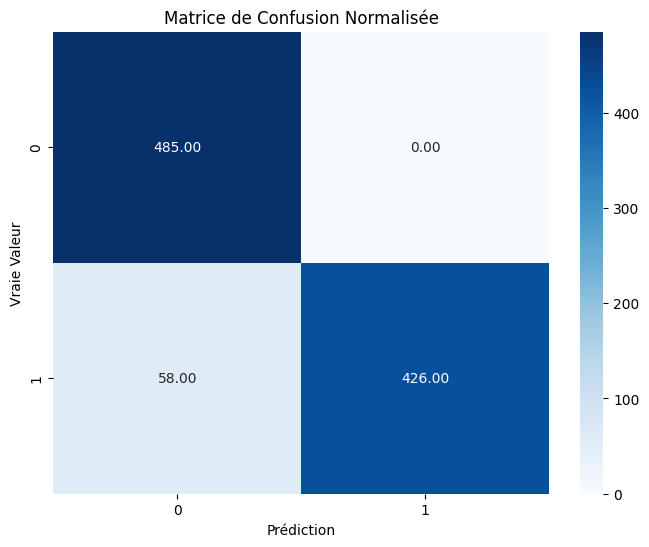

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



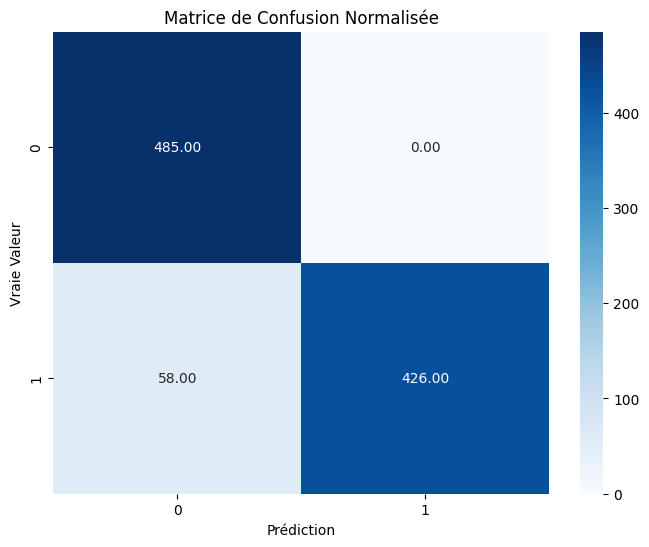

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



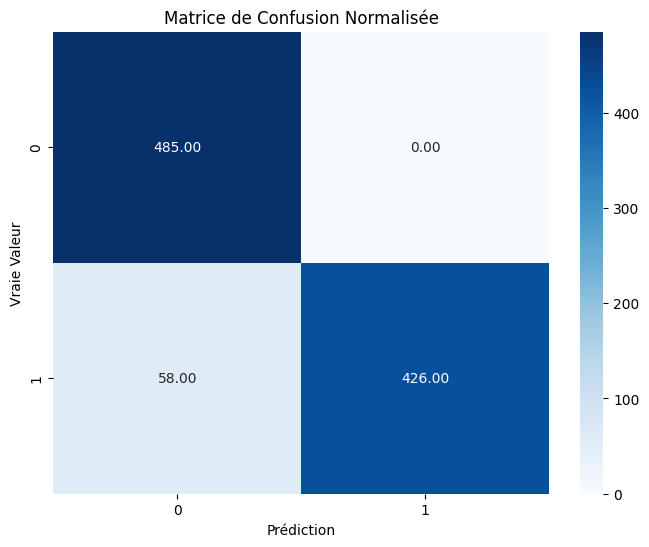

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



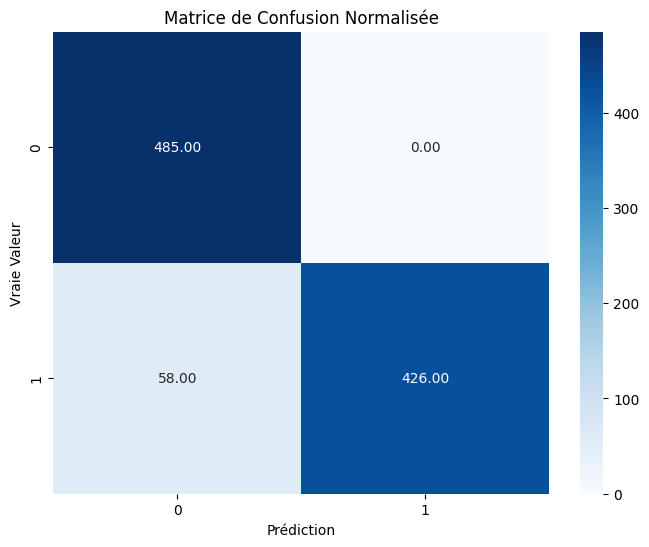

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



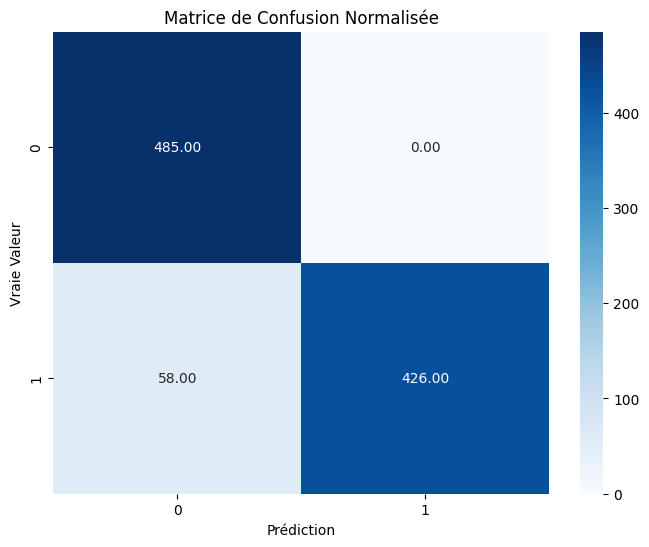

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



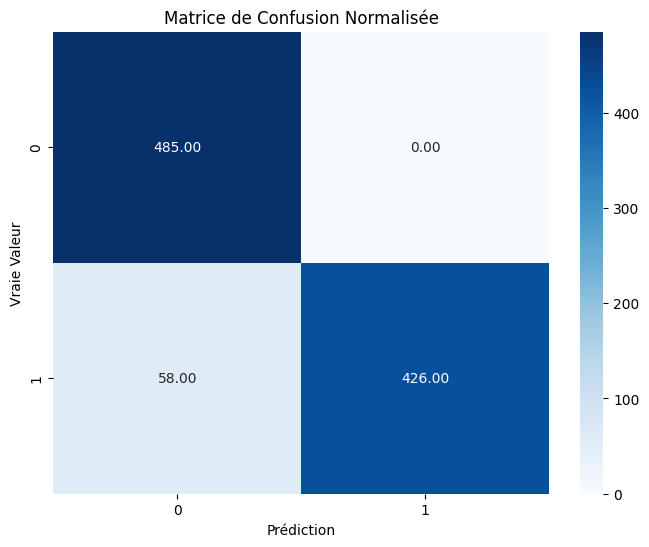

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



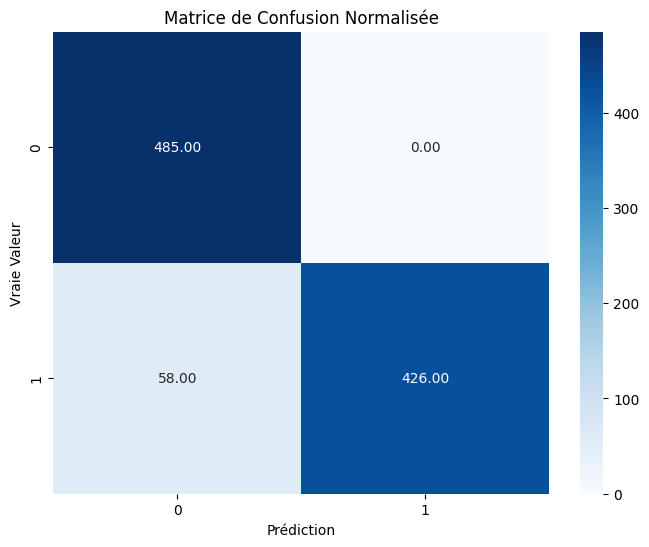

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



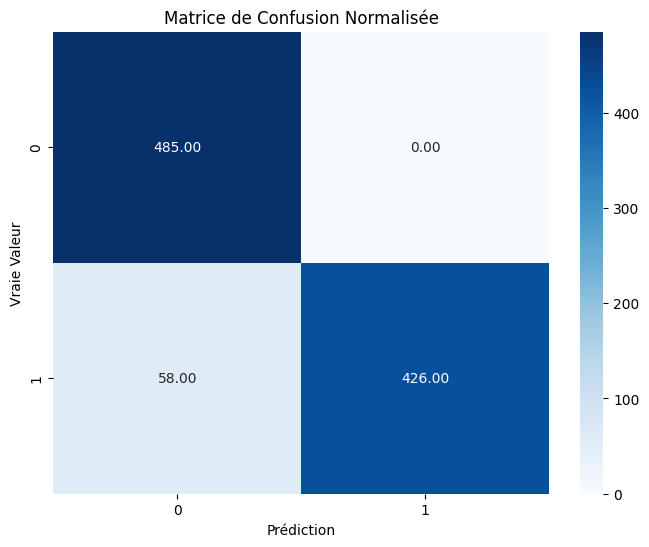

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



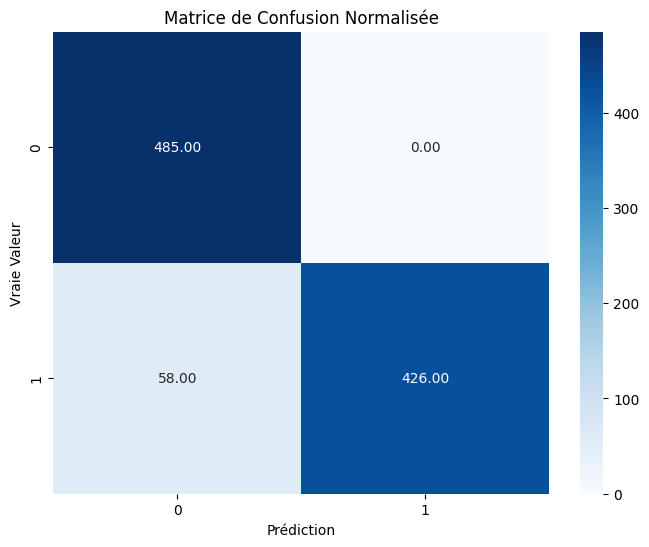

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



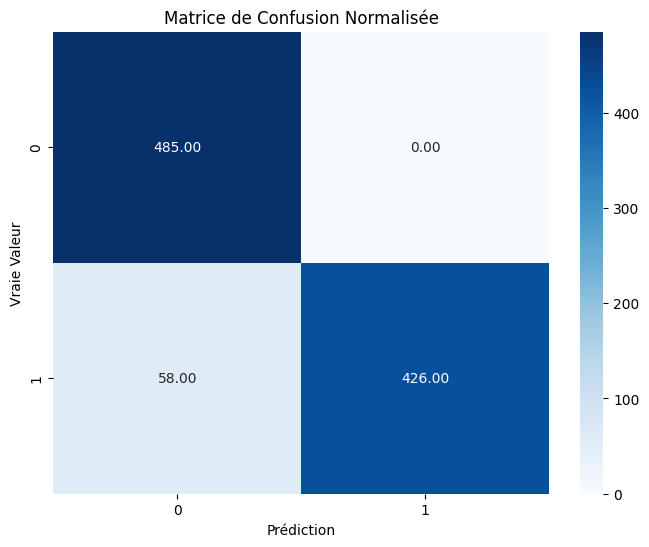

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



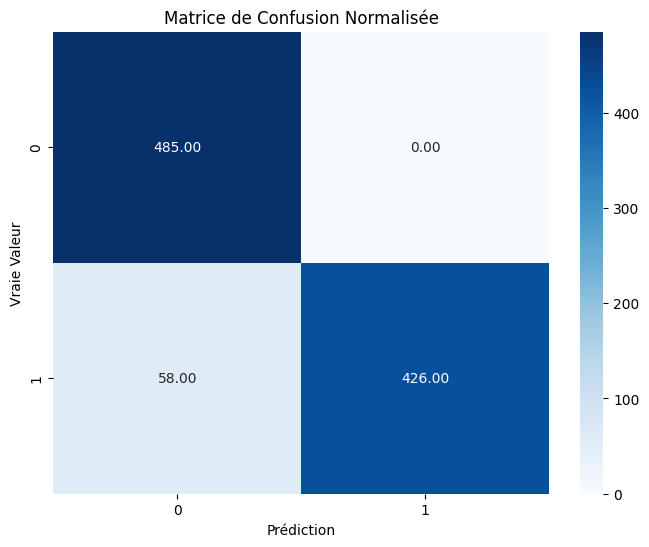

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



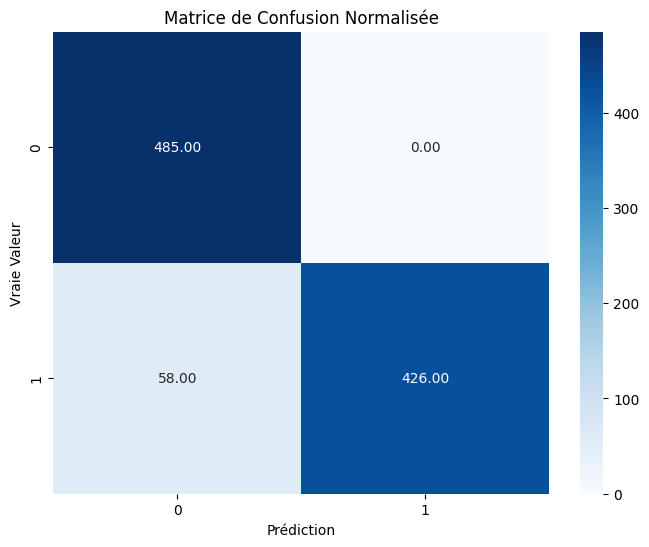

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



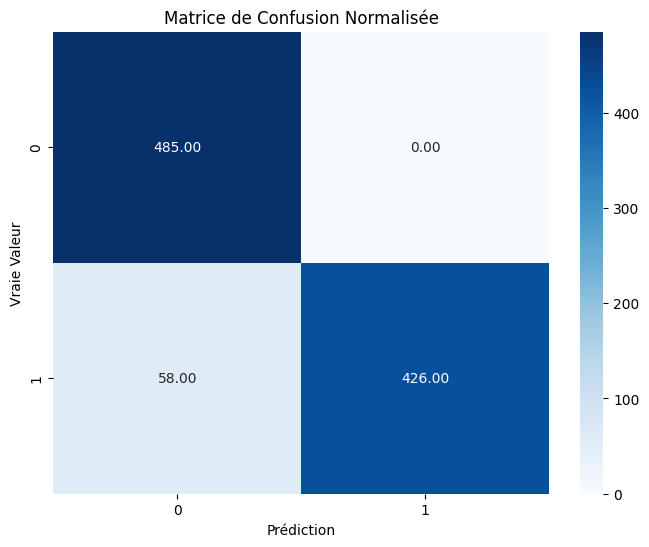

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



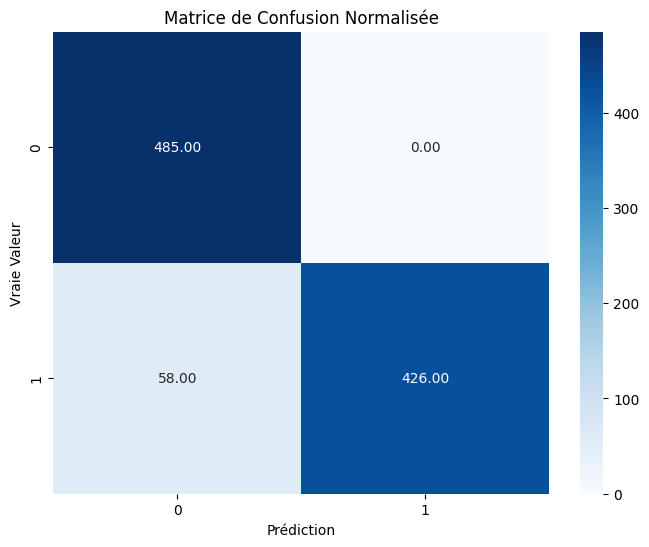

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



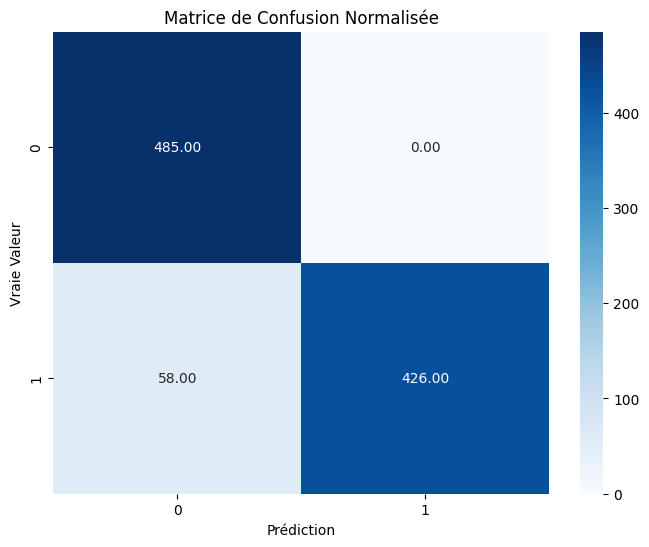

Accuracy: 0.94
Precision: 1.00
Recall: 0.88
F1 Score: 0.94
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       485
           1       1.00      0.88      0.94       484

    accuracy                           0.94       969
   macro avg       0.95      0.94      0.94       969
weighted avg       0.95      0.94      0.94       969



In [ ]:
ensemble_predictions_avecproba=[]
for index in range(len(predictions[0])):
    # Initialisez la somme des prédictions pour cet indice
    sum_predictions = 0

    # Pour chaque modèle, ajoutez sa prédiction à la somme
    for i in range(len(predictions)):
        sum_predictions += predictions[i][index]

    # Divisez la somme par le nombre de modèles pour obtenir la prédiction finale pour cet indice
    final_prediction = sum_predictions / len(predictions)

    # Ajoutez la prédiction finale à votre liste de prédictions finales
    ensemble_predictions_avecproba=np.append(ensemble_predictions_avecproba,final_prediction)

seuil_decision = 0.5
classes_predictions_finales = []

for prediction in ensemble_predictions_avecproba:
    classe_prediction = 1 if prediction >= seuil_decision else 0
    classes_predictions_finales.append(classe_prediction)

for y_test_combined_saved in y_test_combined_list:
    accuracy = accuracy_score(y_test_combined_saved, classes_predictions_finales)
    precision = precision_score(y_test_combined_saved, classes_predictions_finales)
    recall = recall_score(y_test_combined_saved, classes_predictions_finales)
    f1 = f1_score(y_test_combined_saved, classes_predictions_finales)


    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")

    # Affichage du rapport de classification
    print(classification_report(y_test_combined_saved, classes_predictions_finales))

    # Matrice de confusion
    cm = confusion_matrix(y_test_combined_saved, classes_predictions_finales)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie Valeur')
    plt.title('Matrice de Confusion Normalisée')
    plt.show()
#avec poinds au

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warning

Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.51
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.51
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.51
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.50
Recall: 1.00
F1 Score: 0.

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warning

Accuracy: 0.51
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.51
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warning

...

Accuracy: 0.51
Precision: 0.51
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warning

Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.51
Precision: 0.51
Recall: 1.00
F1 Score: 0.67


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warning

Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
              precision    recall  f1-score   support

           0       1.00      0.01      0.02       622
           1       0.50      1.00      0.67       622

    accuracy                           0.50      1244
   macro avg       0.75      0.50      0.34      1244
weighted avg       0.75      0.50      0.34      1244



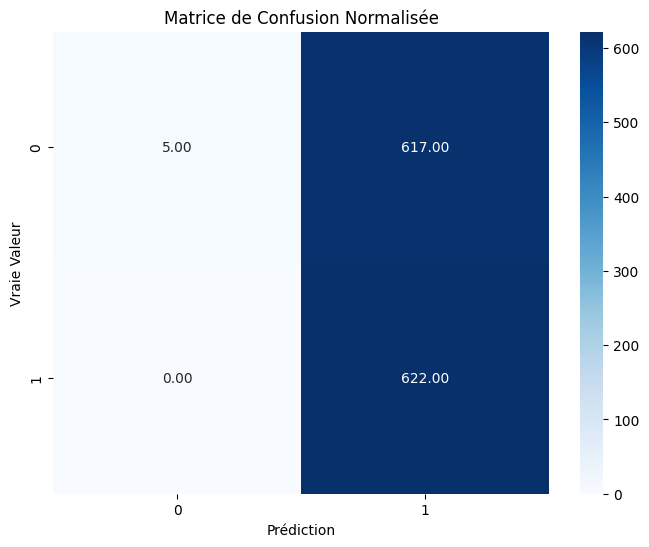

Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1 Score: 0.67
Accuracy: 0.50
              precision    recall  f1-score   support

           0       1.00      0.01      0.02       622
           1       0.50      1.00      0.67       622

    accuracy                           0.50      1244
   macro avg       0.75      0.50      0.34      1244
weighted avg       0.75      0.50      0.34      1244



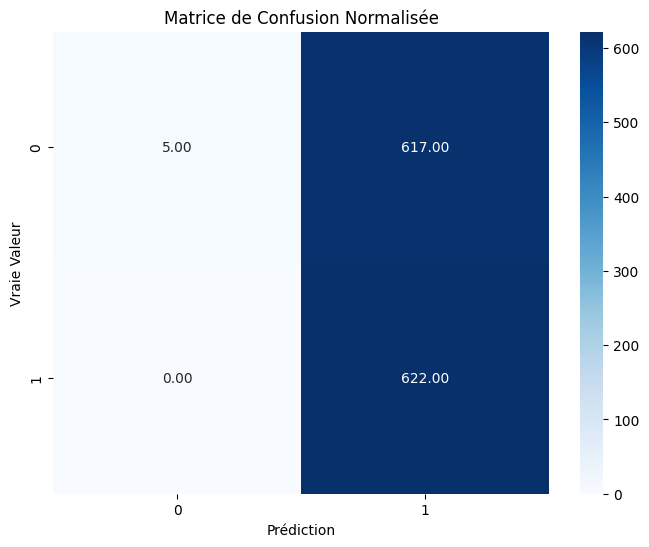

In [ ]:
predictions = []
X_test = testset.drop('fire', axis=1)  # Supprimez la colonne 'fire' pour obtenir les caractéristiques
y_test = testset['fire']
for model in random_wafaa_models:#


    y_pred_rf = model.predict(X_test)

    # Ajout des prédictions à la liste
    predictions.append(y_pred_rf)

    # Évaluation des performances du modèle
    accuracy = accuracy_score(y_test, y_pred_rf)
    precision = precision_score(y_test, y_pred_rf)
    recall = recall_score(y_test, y_pred_rf)
    f1 = f1_score(y_test, y_pred_rf)


    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")

# Convertir les prédictions en un tableau numpy
predictions_array = np.array(predictions)

# Calculer le mode (vote majoritaire) pour chaque tuple de données
ensemble_predictions = mode(predictions_array, axis=0)[0]

accuracy = accuracy_score( y_test, ensemble_predictions)
precision = precision_score( y_test, ensemble_predictions)
recall = recall_score( y_test, ensemble_predictions)
f1 = f1_score( y_test, ensemble_predictions)


print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f'Accuracy: {accuracy:.2f}')

    # Affichage du rapport de classification
print(classification_report(y_test, ensemble_predictions))

    # Matrice de confusion
cm = confusion_matrix(y_test, ensemble_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()

#AVEC PROBA##################################################################################################
ensemble_predictions_avecproba=[]
for index in range(len(predictions[0])):
    # Initialisez la somme des prédictions pour cet indice
    sum_predictions = 0

    # Pour chaque modèle, ajoutez sa prédiction à la somme
    for i in range(len(predictions)):
        sum_predictions += predictions[i][index]

    # Divisez la somme par le nombre de modèles pour obtenir la prédiction finale pour cet indice
    final_prediction = sum_predictions / len(predictions)

    # Ajoutez la prédiction finale à votre liste de prédictions finales
    ensemble_predictions_avecproba=np.append(ensemble_predictions_avecproba,final_prediction)

seuil_decision = 0.5
classes_predictions_finales = []

for prediction in ensemble_predictions_avecproba:
    classe_prediction = 1 if prediction >= seuil_decision else 0
    classes_predictions_finales.append(classe_prediction)

accuracy = accuracy_score( y_test, classes_predictions_finales)
precision = precision_score( y_test, classes_predictions_finales)
recall = recall_score( y_test, classes_predictions_finales)
f1 = f1_score( y_test, classes_predictions_finales)


print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f'Accuracy: {accuracy:.2f}')

    # Affichage du rapport de classification
print(classification_report(y_test, classes_predictions_finales))

    # Matrice de confusion
cm = confusion_matrix(y_test, classes_predictions_finales)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()


Accuracy: 0.85
Precision: 0.82
Recall: 0.89
F1 Score: 0.85
              precision    recall  f1-score   support

           0       0.88      0.81      0.84       478
           1       0.82      0.89      0.85       478

    accuracy                           0.85       956
   macro avg       0.85      0.85      0.85       956
weighted avg       0.85      0.85      0.85       956



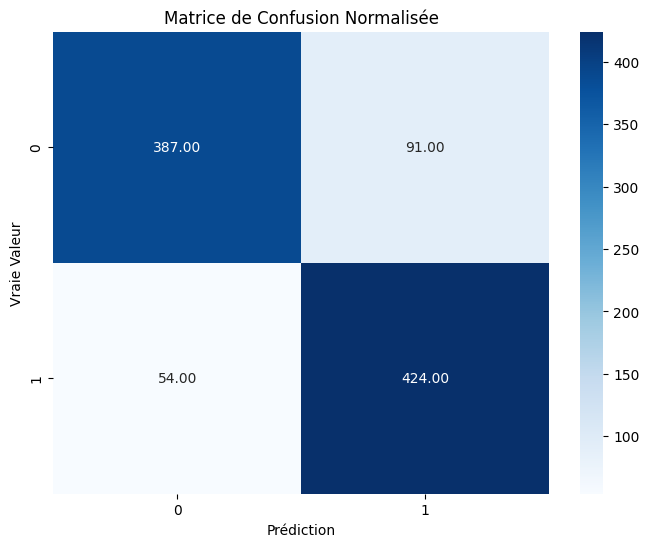

Accuracy: 0.85
Precision: 0.84
Recall: 0.87
F1 Score: 0.85
              precision    recall  f1-score   support

           0       0.86      0.83      0.85       478
           1       0.84      0.87      0.85       478

    accuracy                           0.85       956
   macro avg       0.85      0.85      0.85       956
weighted avg       0.85      0.85      0.85       956



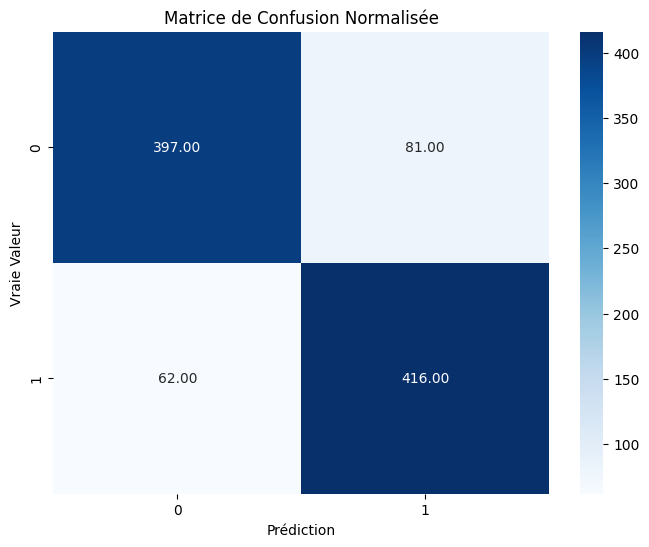

Accuracy: 0.84
Precision: 0.83
Recall: 0.85
F1 Score: 0.84
              precision    recall  f1-score   support

           0       0.85      0.82      0.84       478
           1       0.83      0.85      0.84       478

    accuracy                           0.84       956
   macro avg       0.84      0.84      0.84       956
weighted avg       0.84      0.84      0.84       956



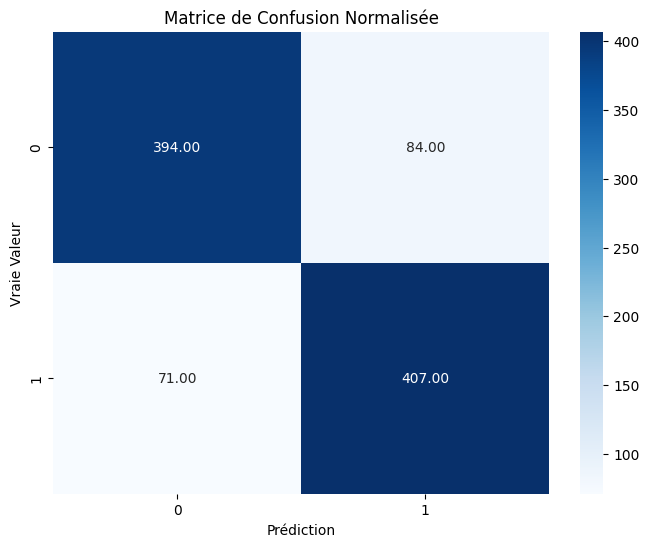

Accuracy: 0.84
Precision: 0.83
Recall: 0.86
F1 Score: 0.84
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       478
           1       0.83      0.86      0.84       478

    accuracy                           0.84       956
   macro avg       0.84      0.84      0.84       956
weighted avg       0.84      0.84      0.84       956



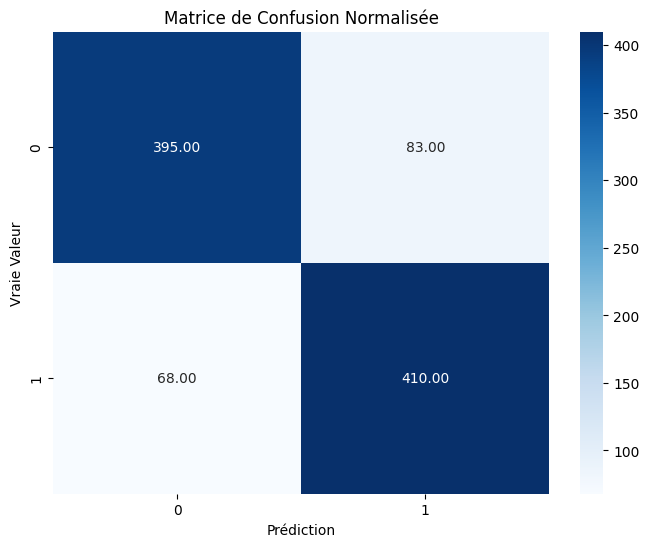

Accuracy: 0.85
Precision: 0.84
Recall: 0.86
F1 Score: 0.85
              precision    recall  f1-score   support

           0       0.86      0.83      0.84       478
           1       0.84      0.86      0.85       478

    accuracy                           0.85       956
   macro avg       0.85      0.85      0.85       956
weighted avg       0.85      0.85      0.85       956



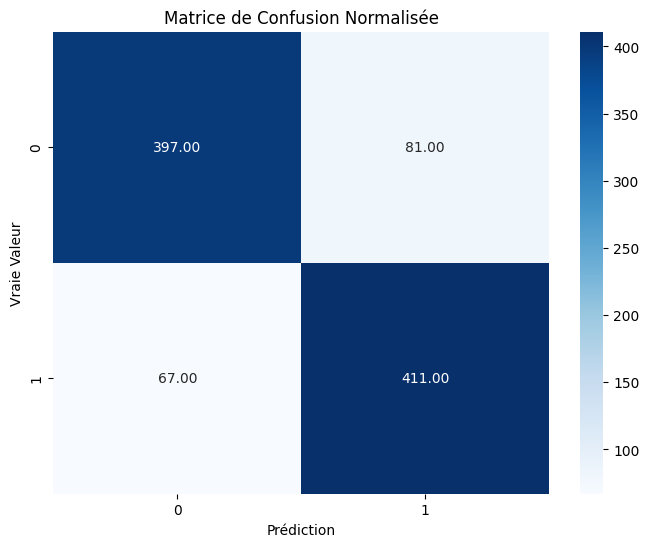

Modèle sélectionné avec un rappel proche de la moyenne des rappels.
Accuracy: 0.60
Precision: 0.70
Recall: 0.36
F1 Score: 0.48
              precision    recall  f1-score   support

           0       0.57      0.84      0.68       653
           1       0.70      0.36      0.48       653

    accuracy                           0.60      1306
   macro avg       0.63      0.60      0.58      1306
weighted avg       0.63      0.60      0.58      1306



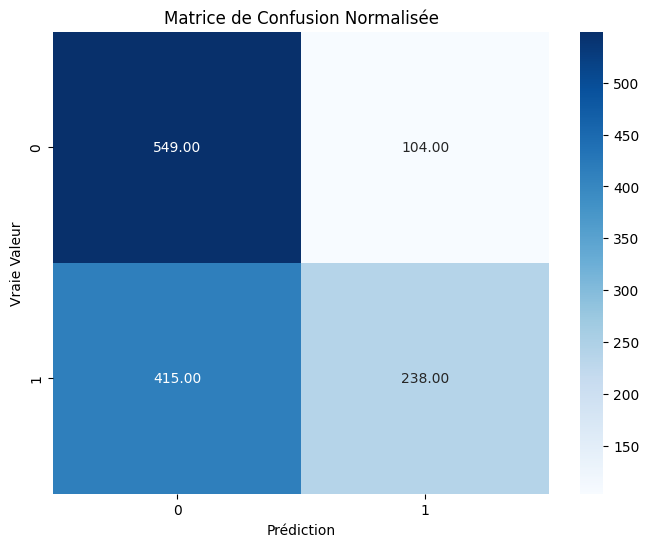

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import NearMiss
from imblearn.under_sampling import RandomUnderSampler

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]
stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)


      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      decision_tree = DecisionTreeClassifier(random_state=42)
      decision_tree.fit(X_train, y_train)
      models.append(decision_tree)

      # Prédiction sur l'ensemble de test
      y_pred = decision_tree.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      recalls.append(recall)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()

mean_recall = np.mean(recalls)

# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = None
closest_recall_diff = float('inf')  # Initialisation avec une valeur infinie
for model, recall in zip(models, recalls):
    recall_diff = abs(recall - mean_recall)
    if recall_diff < closest_recall_diff:
        closest_model = model
        closest_recall_diff = recall_diff

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()


Accuracy: 0.82
Precision: 0.79
Recall: 0.88
F1 Score: 0.83
              precision    recall  f1-score   support

           0       0.87      0.76      0.81       478
           1       0.79      0.88      0.83       478

    accuracy                           0.82       956
   macro avg       0.83      0.82      0.82       956
weighted avg       0.83      0.82      0.82       956



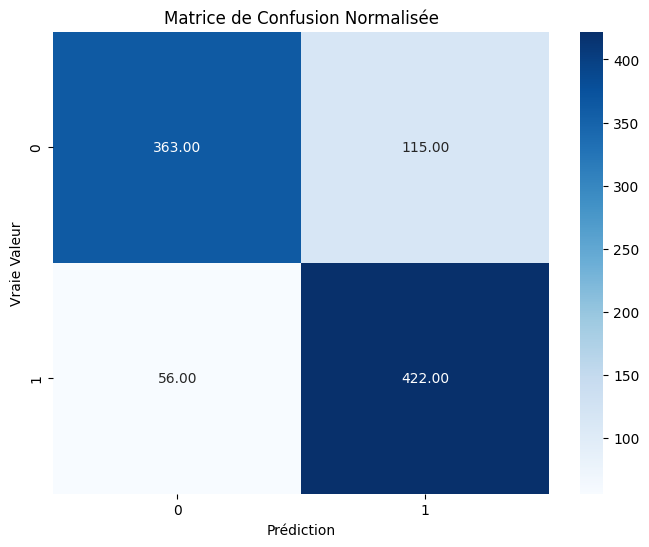

Accuracy: 0.84
Precision: 0.82
Recall: 0.89
F1 Score: 0.85
              precision    recall  f1-score   support

           0       0.88      0.80      0.84       478
           1       0.82      0.89      0.85       478

    accuracy                           0.84       956
   macro avg       0.85      0.84      0.84       956
weighted avg       0.85      0.84      0.84       956



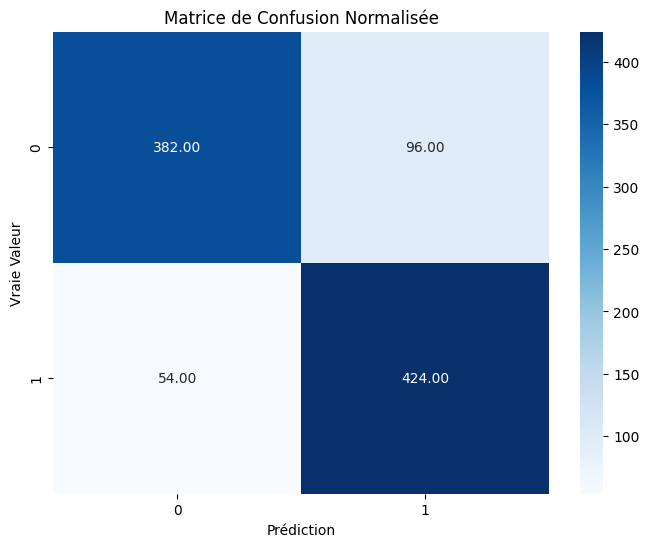

Accuracy: 0.84
Precision: 0.82
Recall: 0.86
F1 Score: 0.84
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       478
           1       0.82      0.86      0.84       478

    accuracy                           0.84       956
   macro avg       0.84      0.84      0.84       956
weighted avg       0.84      0.84      0.84       956



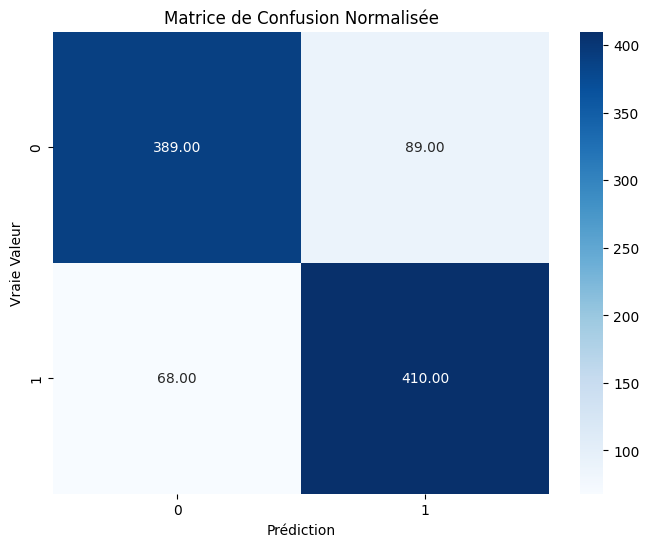

Accuracy: 0.85
Precision: 0.84
Recall: 0.88
F1 Score: 0.86
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       478
           1       0.84      0.88      0.86       478

    accuracy                           0.85       956
   macro avg       0.86      0.85      0.85       956
weighted avg       0.86      0.85      0.85       956



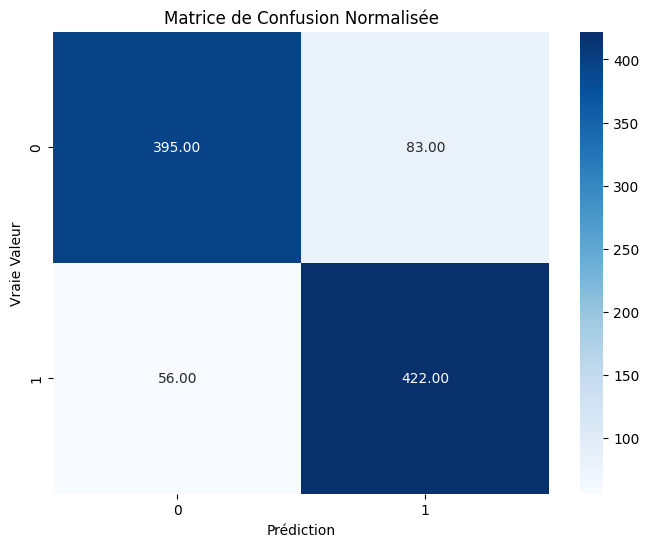

Accuracy: 0.84
Precision: 0.82
Recall: 0.87
F1 Score: 0.84
              precision    recall  f1-score   support

           0       0.86      0.81      0.83       478
           1       0.82      0.87      0.84       478

    accuracy                           0.84       956
   macro avg       0.84      0.84      0.84       956
weighted avg       0.84      0.84      0.84       956



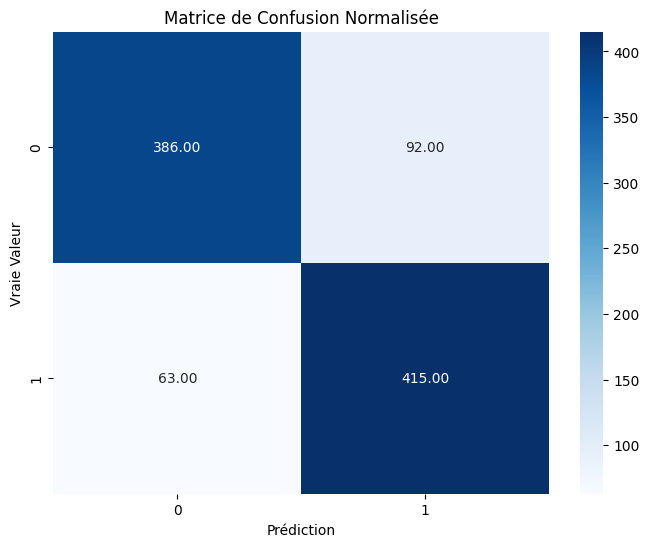

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import NearMiss
from imblearn.under_sampling import RandomUnderSampler

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)


      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      decision_tree = DecisionTreeClassifier(max_depth=10,random_state=42)
      decision_tree.fit(X_train, y_train)

      # Prédiction sur l'ensemble de test
      y_pred = decision_tree.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


Accuracy: 0.85
Precision: 0.82
Recall: 0.89
F1 Score: 0.85
              precision    recall  f1-score   support

           0       0.88      0.81      0.84       478
           1       0.82      0.89      0.85       478

    accuracy                           0.85       956
   macro avg       0.85      0.85      0.85       956
weighted avg       0.85      0.85      0.85       956



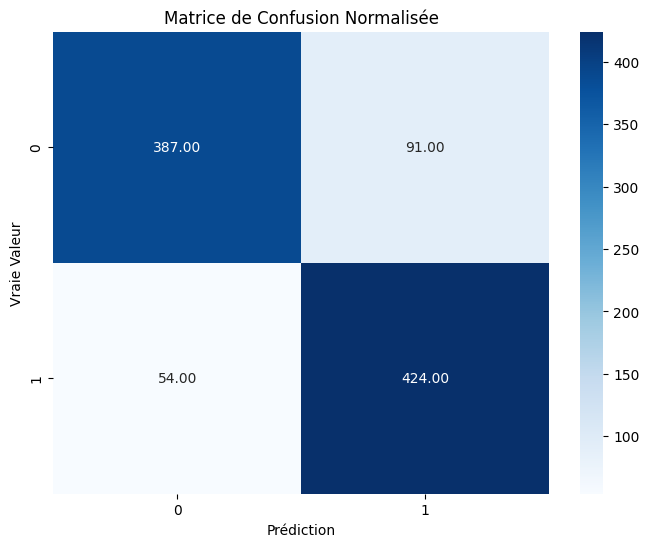

Accuracy: 0.85
Precision: 0.84
Recall: 0.87
F1 Score: 0.85
              precision    recall  f1-score   support

           0       0.86      0.83      0.85       478
           1       0.84      0.87      0.85       478

    accuracy                           0.85       956
   macro avg       0.85      0.85      0.85       956
weighted avg       0.85      0.85      0.85       956



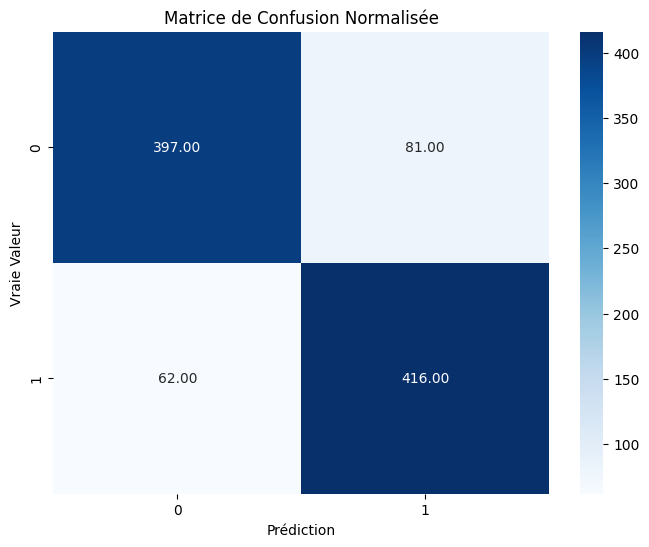

Accuracy: 0.84
Precision: 0.83
Recall: 0.85
F1 Score: 0.84
              precision    recall  f1-score   support

           0       0.85      0.82      0.84       478
           1       0.83      0.85      0.84       478

    accuracy                           0.84       956
   macro avg       0.84      0.84      0.84       956
weighted avg       0.84      0.84      0.84       956



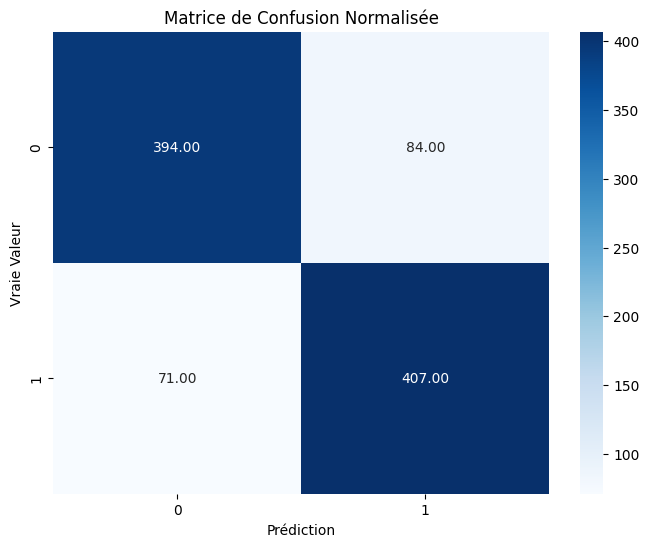

Accuracy: 0.84
Precision: 0.83
Recall: 0.86
F1 Score: 0.84
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       478
           1       0.83      0.86      0.84       478

    accuracy                           0.84       956
   macro avg       0.84      0.84      0.84       956
weighted avg       0.84      0.84      0.84       956



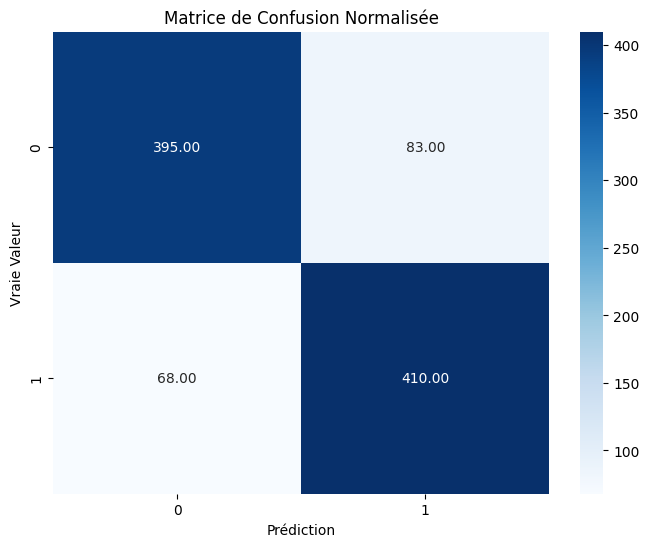

Accuracy: 0.85
Precision: 0.84
Recall: 0.86
F1 Score: 0.85
              precision    recall  f1-score   support

           0       0.86      0.83      0.84       478
           1       0.84      0.86      0.85       478

    accuracy                           0.85       956
   macro avg       0.85      0.85      0.85       956
weighted avg       0.85      0.85      0.85       956



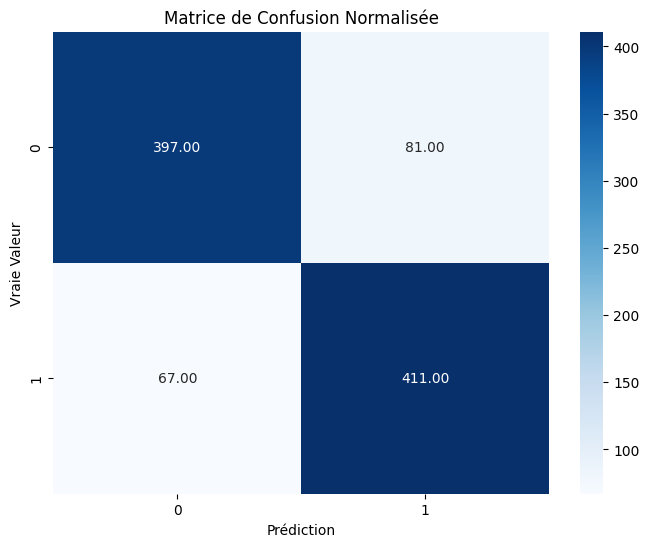

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import NearMiss
from imblearn.under_sampling import RandomUnderSampler

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)


      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      decision_tree = DecisionTreeClassifier(max_depth=50,random_state=42)
      decision_tree.fit(X_train, y_train)

      # Prédiction sur l'ensemble de test
      y_pred = decision_tree.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


Accuracy: 0.89
Precision: 0.89
Recall: 0.90
F1 Score: 0.89
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       478
           1       0.89      0.90      0.89       478

    accuracy                           0.89       956
   macro avg       0.89      0.89      0.89       956
weighted avg       0.89      0.89      0.89       956



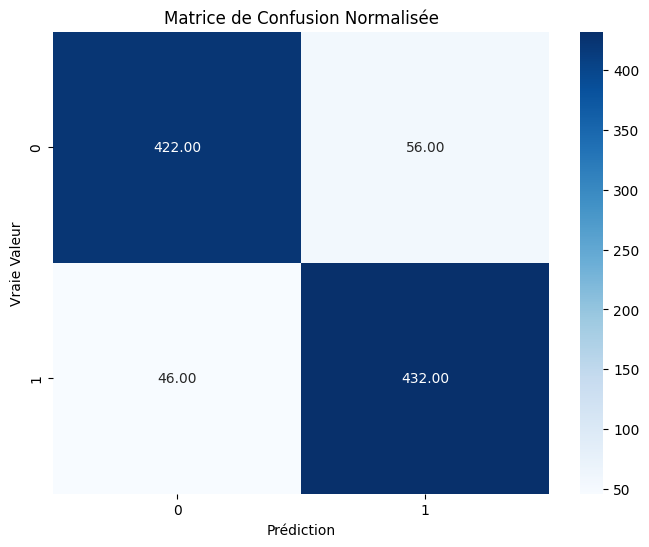

Accuracy: 0.87
Precision: 0.86
Recall: 0.89
F1 Score: 0.87
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       478
           1       0.86      0.89      0.87       478

    accuracy                           0.87       956
   macro avg       0.87      0.87      0.87       956
weighted avg       0.87      0.87      0.87       956



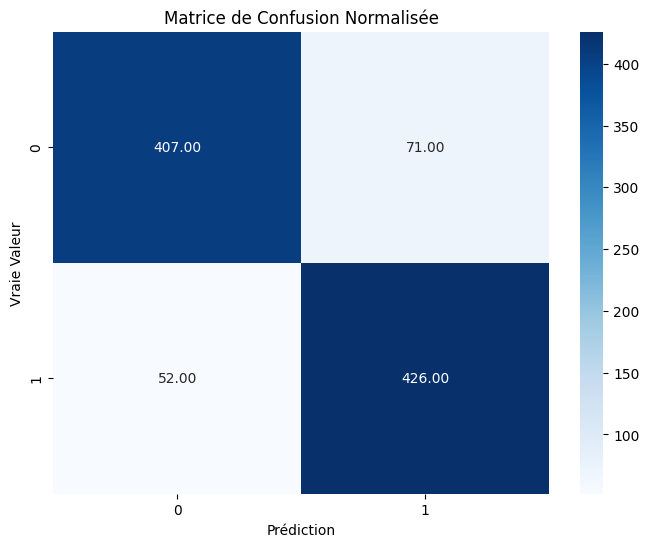

Accuracy: 0.87
Precision: 0.87
Recall: 0.86
F1 Score: 0.86
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       478
           1       0.87      0.86      0.86       478

    accuracy                           0.87       956
   macro avg       0.87      0.87      0.87       956
weighted avg       0.87      0.87      0.87       956



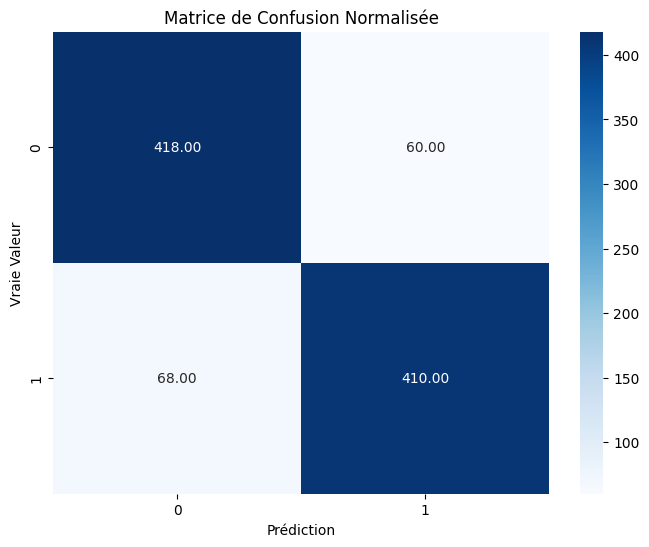

Accuracy: 0.87
Precision: 0.85
Recall: 0.90
F1 Score: 0.87
              precision    recall  f1-score   support

           0       0.89      0.84      0.87       478
           1       0.85      0.90      0.87       478

    accuracy                           0.87       956
   macro avg       0.87      0.87      0.87       956
weighted avg       0.87      0.87      0.87       956



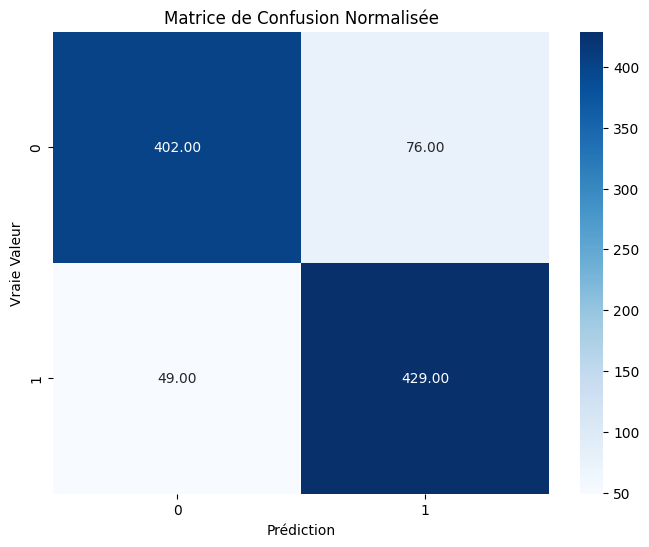

Accuracy: 0.88
Precision: 0.87
Recall: 0.89
F1 Score: 0.88
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       478
           1       0.87      0.89      0.88       478

    accuracy                           0.88       956
   macro avg       0.88      0.88      0.88       956
weighted avg       0.88      0.88      0.88       956



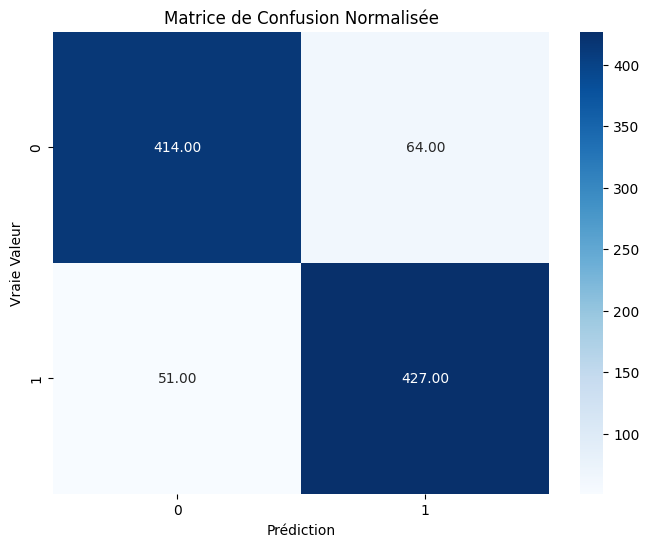

Modèle sélectionné avec un rappel proche de la moyenne des rappels.
Accuracy: 0.85
Precision: 0.90
Recall: 0.80
F1 Score: 0.85
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       653
           1       0.90      0.80      0.85       653

    accuracy                           0.85      1306
   macro avg       0.86      0.85      0.85      1306
weighted avg       0.86      0.85      0.85      1306



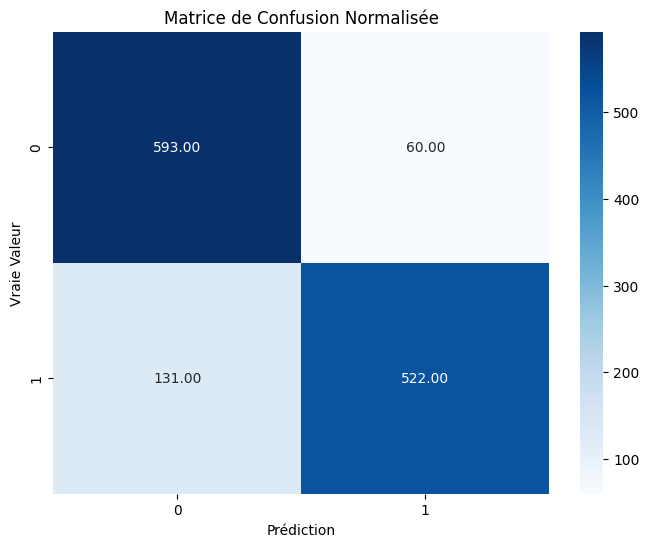

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)

      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      random_forest = RandomForestClassifier(n_estimators=100,max_depth=10)
      random_forest.fit(X_train, y_train)
      models.append(random_forest)
      # Prédiction sur l'ensemble de test
      y_pred = random_forest.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      recalls.append(recall)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


mean_recall = np.mean(recalls)

# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = None
closest_recall_diff = float('inf')  # Initialisation avec une valeur infinie
for model, recall in zip(models, recalls):
    recall_diff = abs(recall - mean_recall)
    if recall_diff < closest_recall_diff:
        closest_model = model
        closest_recall_diff = recall_diff

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()



Accuracy: 0.89
Precision: 0.89
Recall: 0.90
F1 Score: 0.89
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       478
           1       0.89      0.90      0.89       478

    accuracy                           0.89       956
   macro avg       0.89      0.89      0.89       956
weighted avg       0.89      0.89      0.89       956



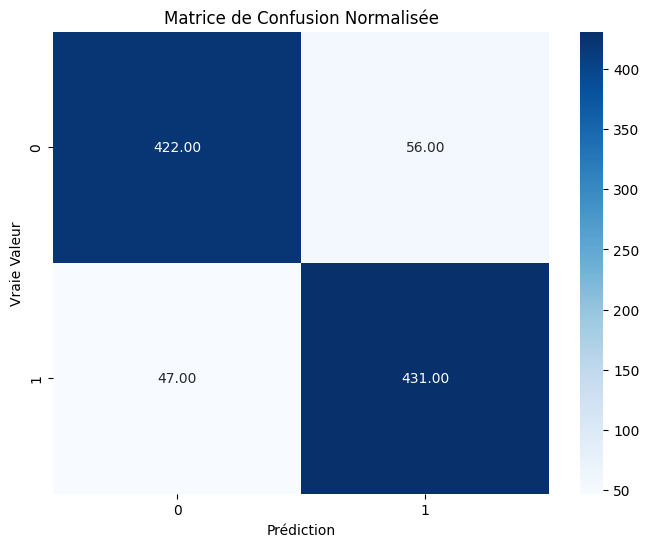

Accuracy: 0.89
Precision: 0.87
Recall: 0.91
F1 Score: 0.89
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       478
           1       0.87      0.91      0.89       478

    accuracy                           0.89       956
   macro avg       0.89      0.89      0.89       956
weighted avg       0.89      0.89      0.89       956



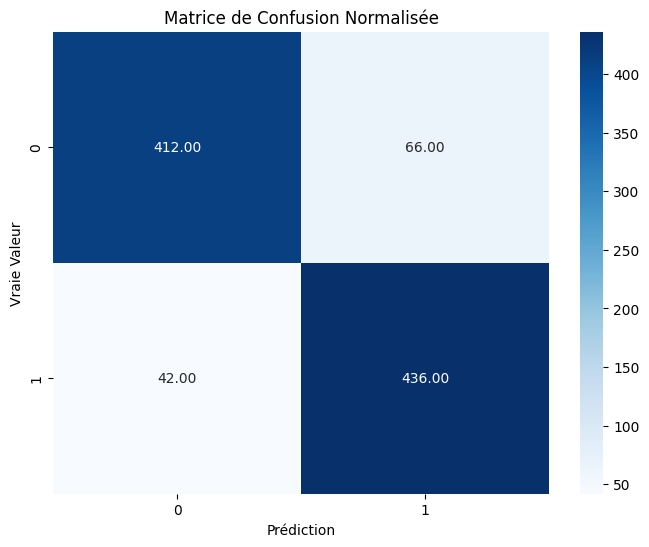

Accuracy: 0.87
Precision: 0.88
Recall: 0.87
F1 Score: 0.87
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       478
           1       0.88      0.87      0.87       478

    accuracy                           0.87       956
   macro avg       0.87      0.87      0.87       956
weighted avg       0.87      0.87      0.87       956



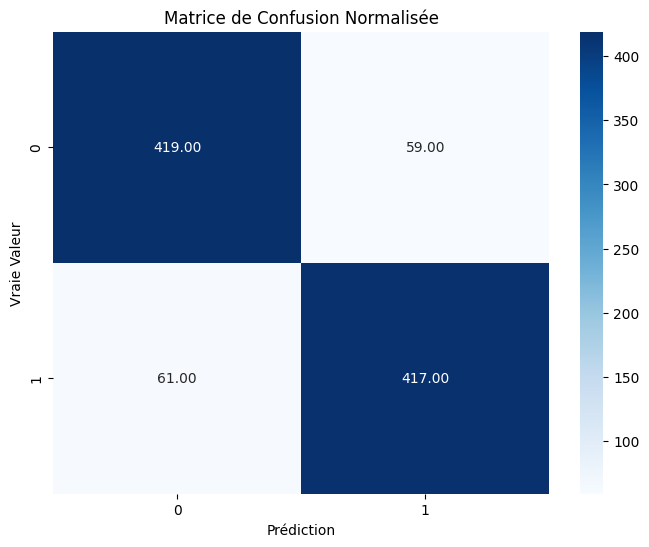

Accuracy: 0.88
Precision: 0.86
Recall: 0.90
F1 Score: 0.88
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       478
           1       0.86      0.90      0.88       478

    accuracy                           0.88       956
   macro avg       0.88      0.88      0.88       956
weighted avg       0.88      0.88      0.88       956



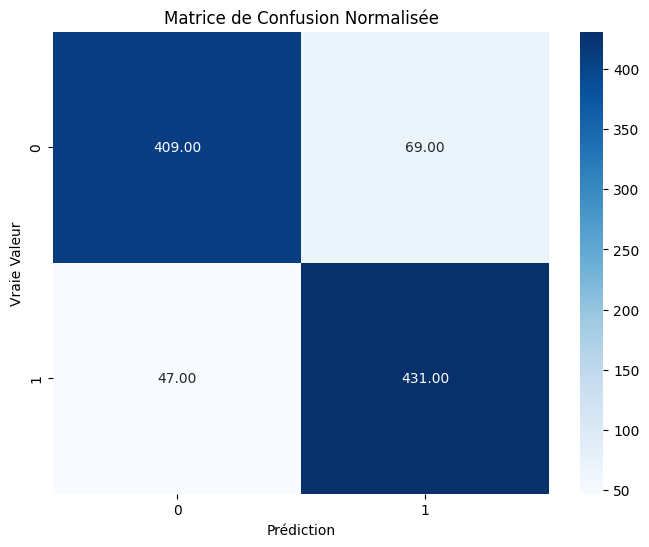

Accuracy: 0.88
Precision: 0.87
Recall: 0.89
F1 Score: 0.88
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       478
           1       0.87      0.89      0.88       478

    accuracy                           0.88       956
   macro avg       0.88      0.88      0.88       956
weighted avg       0.88      0.88      0.88       956



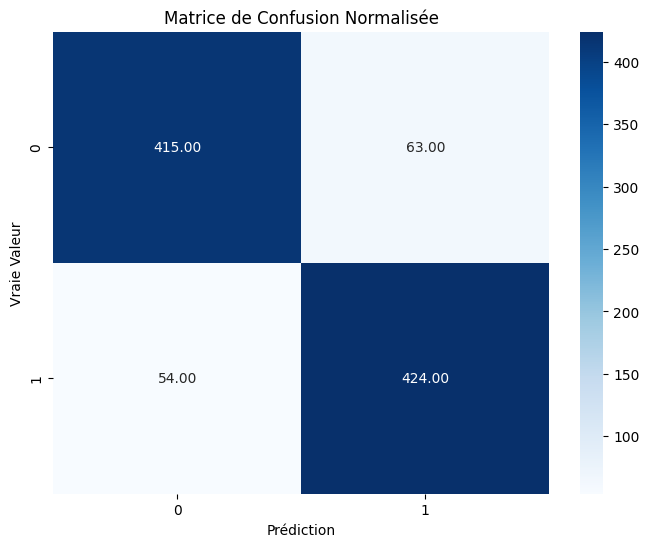

Modèle sélectionné avec un rappel proche de la moyenne des rappels.
Accuracy: 0.86
Precision: 0.89
Recall: 0.83
F1 Score: 0.86
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       653
           1       0.89      0.83      0.86       653

    accuracy                           0.86      1306
   macro avg       0.86      0.86      0.86      1306
weighted avg       0.86      0.86      0.86      1306



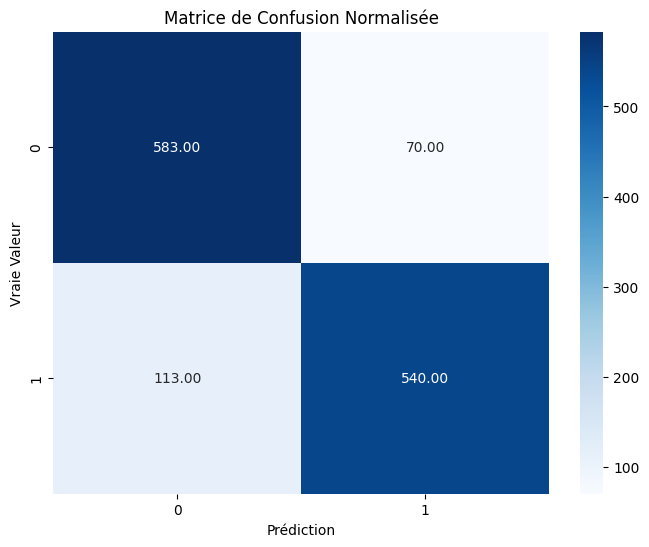

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)

      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      random_forest = RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42)
      random_forest.fit(X_train, y_train)
      models.append(random_forest)
      # Prédiction sur l'ensemble de test
      y_pred = random_forest.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      recalls.append(recall)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


mean_recall = np.mean(recalls)

# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = None
closest_recall_diff = float('inf')  # Initialisation avec une valeur infinie
for model, recall in zip(models, recalls):
    recall_diff = abs(recall - mean_recall)
    if recall_diff < closest_recall_diff:
        closest_model = model
        closest_recall_diff = recall_diff

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()



Accuracy: 0.88
Precision: 0.87
Recall: 0.90
F1 Score: 0.88
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       478
           1       0.87      0.90      0.88       478

    accuracy                           0.88       956
   macro avg       0.88      0.88      0.88       956
weighted avg       0.88      0.88      0.88       956



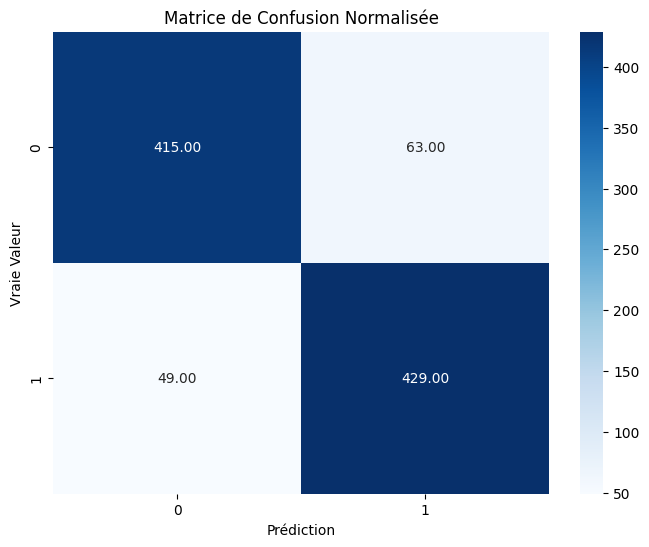

Accuracy: 0.88
Precision: 0.86
Recall: 0.90
F1 Score: 0.88
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       478
           1       0.86      0.90      0.88       478

    accuracy                           0.88       956
   macro avg       0.88      0.88      0.88       956
weighted avg       0.88      0.88      0.88       956



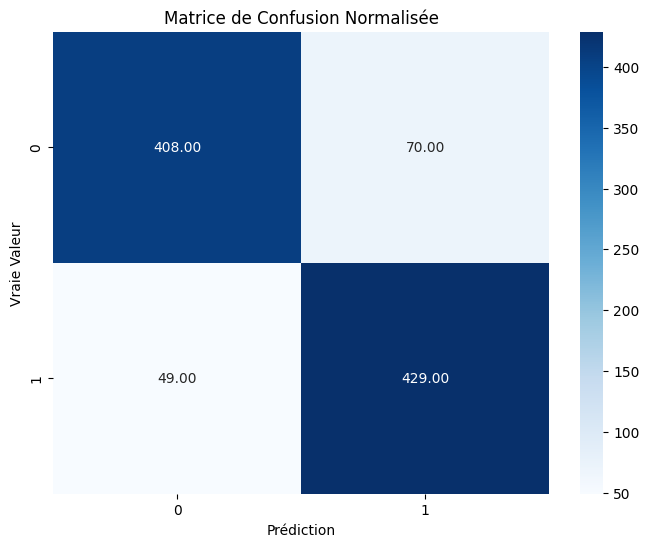

Accuracy: 0.87
Precision: 0.86
Recall: 0.87
F1 Score: 0.87
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       478
           1       0.86      0.87      0.87       478

    accuracy                           0.87       956
   macro avg       0.87      0.87      0.87       956
weighted avg       0.87      0.87      0.87       956



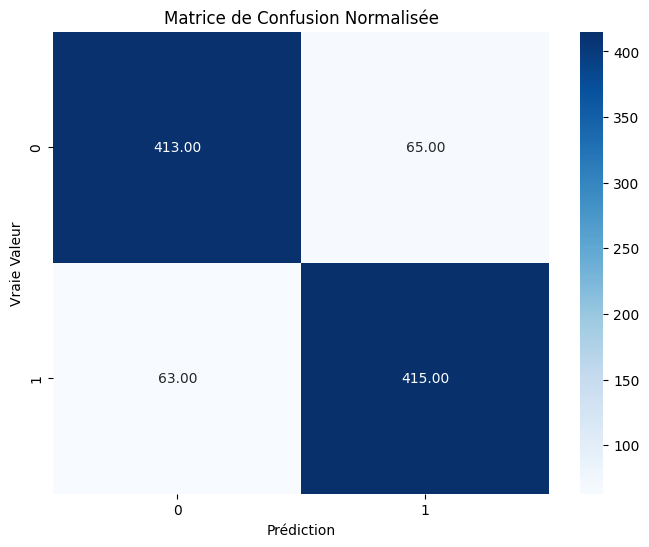

Accuracy: 0.86
Precision: 0.84
Recall: 0.89
F1 Score: 0.87
              precision    recall  f1-score   support

           0       0.89      0.83      0.86       478
           1       0.84      0.89      0.87       478

    accuracy                           0.86       956
   macro avg       0.86      0.86      0.86       956
weighted avg       0.86      0.86      0.86       956



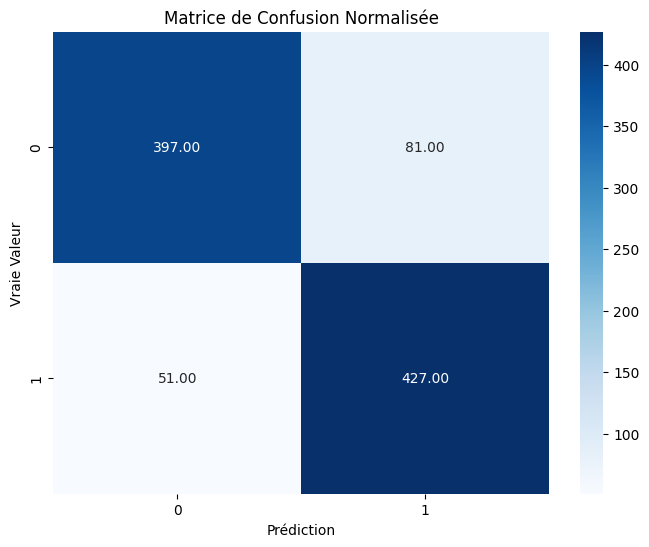

Accuracy: 0.88
Precision: 0.87
Recall: 0.89
F1 Score: 0.88
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       478
           1       0.87      0.89      0.88       478

    accuracy                           0.88       956
   macro avg       0.88      0.88      0.88       956
weighted avg       0.88      0.88      0.88       956



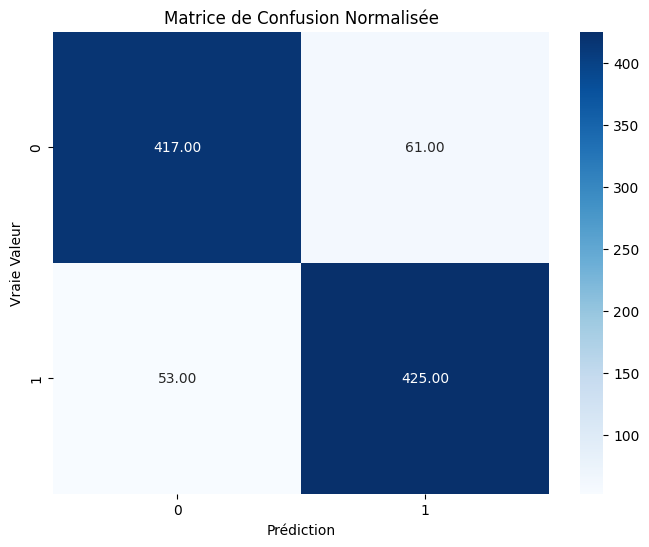

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)

      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      random_forest = RandomForestClassifier(n_estimators=150,max_depth=10)
      random_forest.fit(X_train, y_train)

      # Prédiction sur l'ensemble de test
      y_pred = random_forest.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


Accuracy: 0.90
Precision: 0.89
Recall: 0.90
F1 Score: 0.90
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       484
           1       0.89      0.90      0.90       484

    accuracy                           0.90       968
   macro avg       0.90      0.90      0.90       968
weighted avg       0.90      0.90      0.90       968



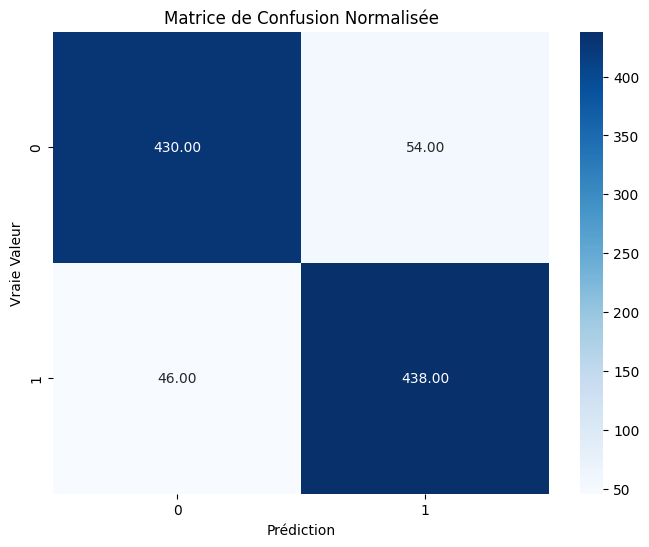

Accuracy: 0.91
Precision: 0.92
Recall: 0.89
F1 Score: 0.90
              precision    recall  f1-score   support

           0       0.89      0.92      0.91       484
           1       0.92      0.89      0.90       484

    accuracy                           0.91       968
   macro avg       0.91      0.91      0.91       968
weighted avg       0.91      0.91      0.91       968



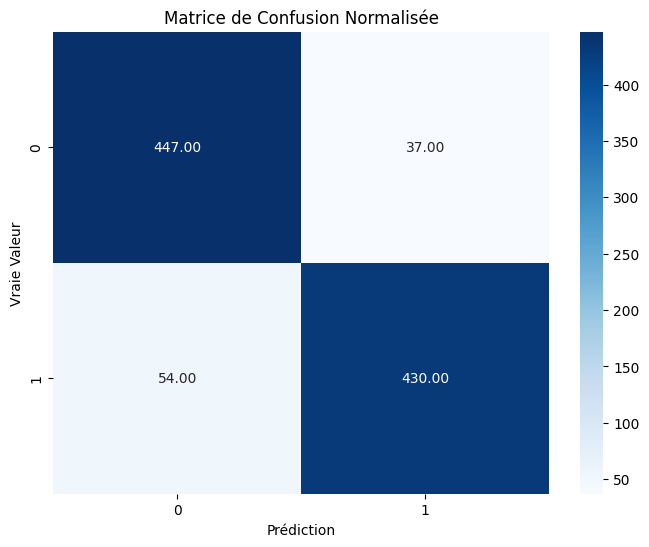

Accuracy: 0.91
Precision: 0.92
Recall: 0.89
F1 Score: 0.90
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       484
           1       0.92      0.89      0.90       484

    accuracy                           0.91       968
   macro avg       0.91      0.91      0.91       968
weighted avg       0.91      0.91      0.91       968



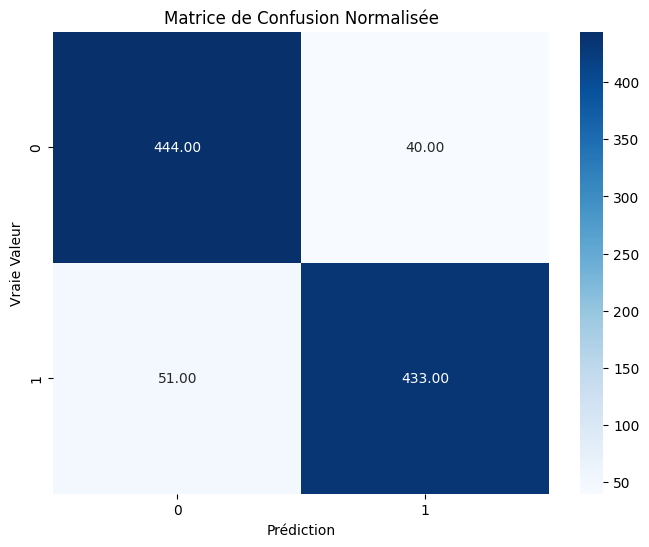

Accuracy: 0.91
Precision: 0.91
Recall: 0.91
F1 Score: 0.91
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       484
           1       0.91      0.91      0.91       484

    accuracy                           0.91       968
   macro avg       0.91      0.91      0.91       968
weighted avg       0.91      0.91      0.91       968



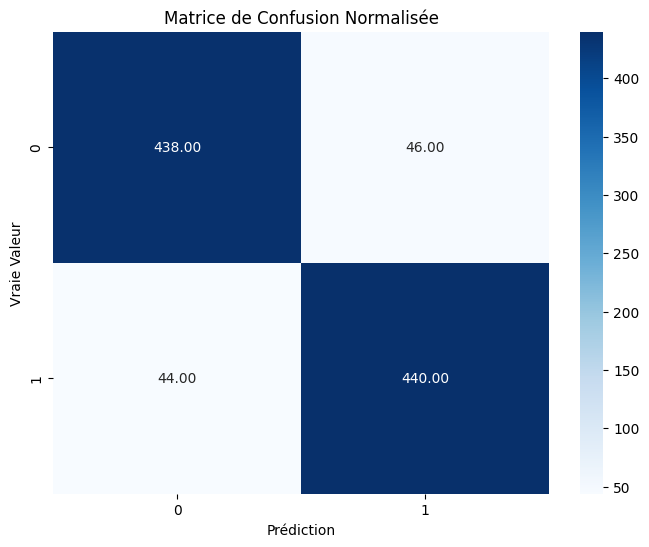

Accuracy: 0.90
Precision: 0.90
Recall: 0.90
F1 Score: 0.90
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       484
           1       0.90      0.90      0.90       484

    accuracy                           0.90       968
   macro avg       0.90      0.90      0.90       968
weighted avg       0.90      0.90      0.90       968



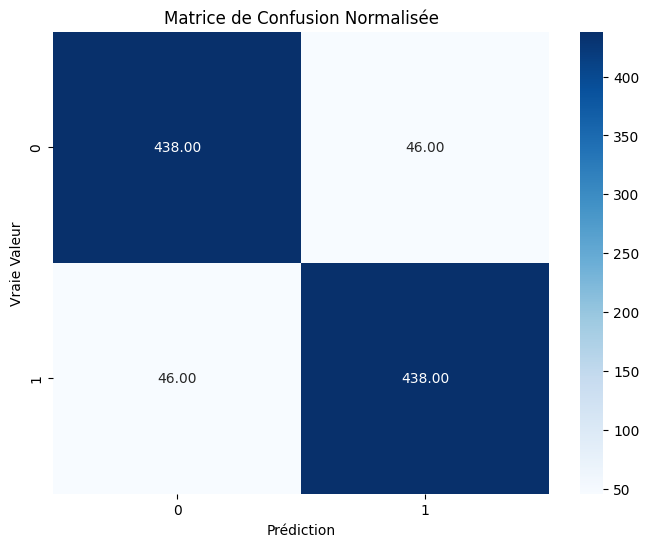

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)

      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      random_forest = RandomForestClassifier(n_estimators=200,max_depth=10)
      random_forest.fit(X_train, y_train)

      # Prédiction sur l'ensemble de test
      y_pred = random_forest.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


Accuracy: 0.91
Precision: 0.91
Recall: 0.91
F1 Score: 0.91
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       478
           1       0.91      0.91      0.91       478

    accuracy                           0.91       956
   macro avg       0.91      0.91      0.91       956
weighted avg       0.91      0.91      0.91       956



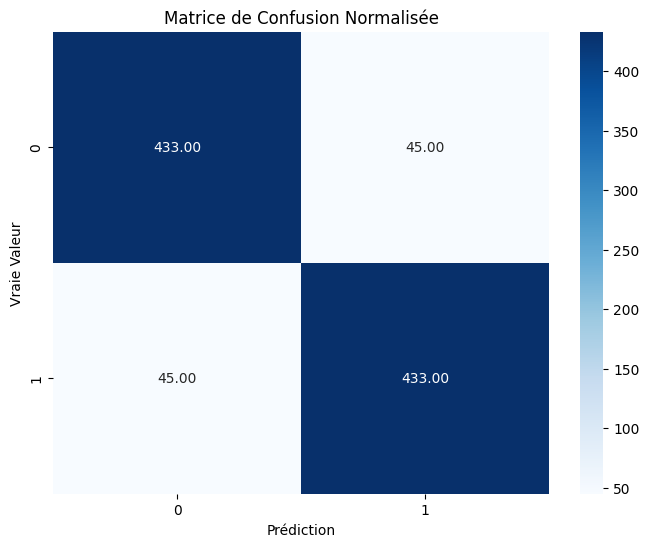

Accuracy: 0.88
Precision: 0.87
Recall: 0.90
F1 Score: 0.88
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       478
           1       0.87      0.90      0.88       478

    accuracy                           0.88       956
   macro avg       0.88      0.88      0.88       956
weighted avg       0.88      0.88      0.88       956



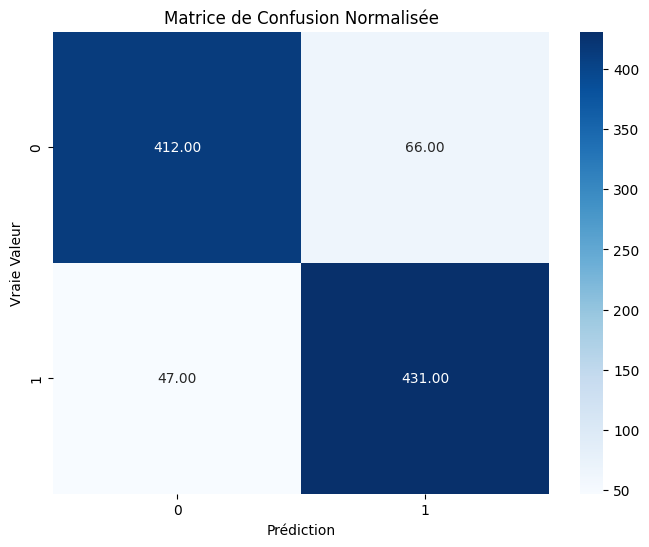

Accuracy: 0.87
Precision: 0.87
Recall: 0.87
F1 Score: 0.87
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       478
           1       0.87      0.87      0.87       478

    accuracy                           0.87       956
   macro avg       0.87      0.87      0.87       956
weighted avg       0.87      0.87      0.87       956



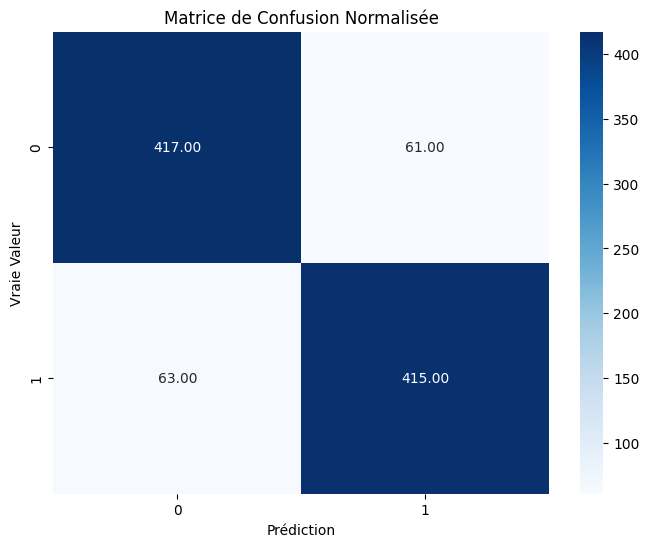

Accuracy: 0.87
Precision: 0.86
Recall: 0.90
F1 Score: 0.88
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       478
           1       0.86      0.90      0.88       478

    accuracy                           0.87       956
   macro avg       0.88      0.87      0.87       956
weighted avg       0.88      0.87      0.87       956



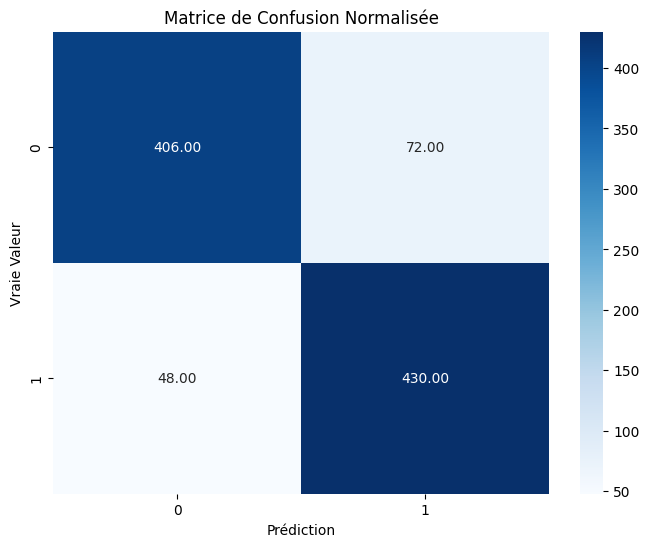

Accuracy: 0.88
Precision: 0.87
Recall: 0.89
F1 Score: 0.88
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       478
           1       0.87      0.89      0.88       478

    accuracy                           0.88       956
   macro avg       0.88      0.88      0.88       956
weighted avg       0.88      0.88      0.88       956



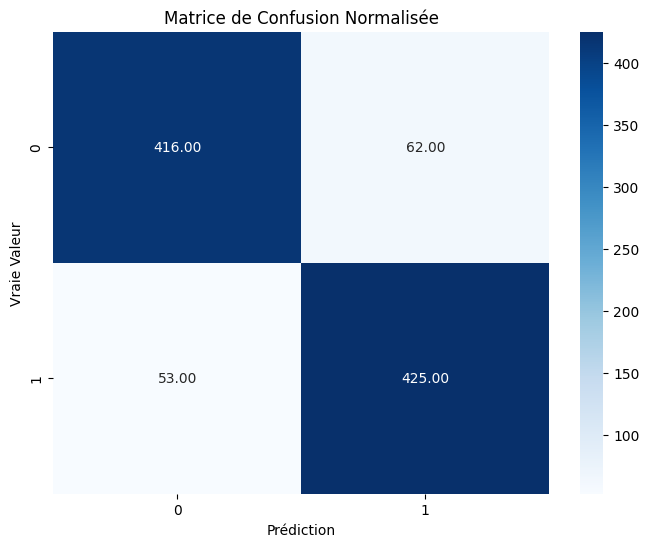

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)

      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      random_forest = RandomForestClassifier(n_estimators=500,random_state=42)
      random_forest.fit(X_train, y_train)

      # Prédiction sur l'ensemble de test
      y_pred = random_forest.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier,RandomForestClassifier

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)

      key={'dt':DecisionTreeClassifier(max_depth=10),'rl':LogisticRegression(C=0.1, solver='newton-cg', max_iter=1000)}      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      random_forest = AdaBoostClassifier(key,n_estimators=100,random_state=42)
      random_forest.fit(X_train, y_train)
      models.append(random_forest)

      # Prédiction sur l'ensemble de test
      y_pred = random_forest.predict(X_val)


      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      recalls.append(recall)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


mean_recall = np.mean(recalls)

# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = None
closest_recall_diff = float('inf')  # Initialisation avec une valeur infinie
for model, recall in zip(models, recalls):
    recall_diff = abs(recall - mean_recall)
    if recall_diff < closest_recall_diff:
        closest_model = model
        closest_recall_diff = recall_diff

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()


Accuracy: 0.81
Precision: 0.77
Recall: 0.88
F1 Score: 0.82
              precision    recall  f1-score   support

           0       0.86      0.73      0.79       478
           1       0.77      0.88      0.82       478

    accuracy                           0.81       956
   macro avg       0.81      0.81      0.80       956
weighted avg       0.81      0.81      0.80       956



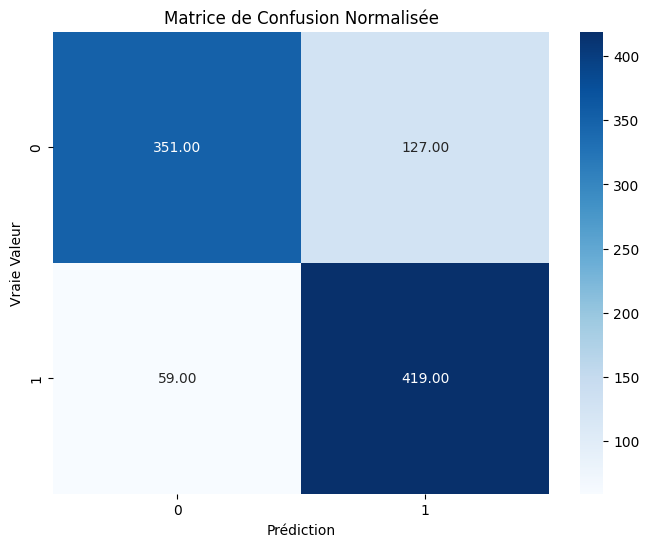

Accuracy: 0.80
Precision: 0.76
Recall: 0.87
F1 Score: 0.81
              precision    recall  f1-score   support

           0       0.85      0.73      0.78       478
           1       0.76      0.87      0.81       478

    accuracy                           0.80       956
   macro avg       0.80      0.80      0.80       956
weighted avg       0.80      0.80      0.80       956



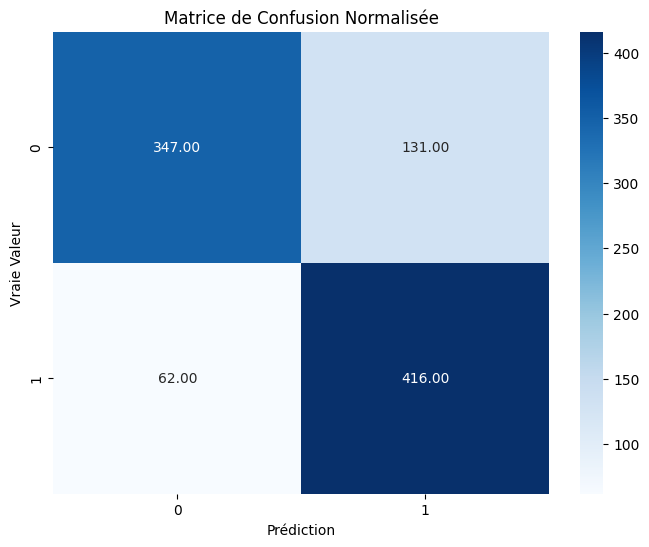

Accuracy: 0.78
Precision: 0.75
Recall: 0.83
F1 Score: 0.79
              precision    recall  f1-score   support

           0       0.81      0.73      0.77       478
           1       0.75      0.83      0.79       478

    accuracy                           0.78       956
   macro avg       0.78      0.78      0.78       956
weighted avg       0.78      0.78      0.78       956



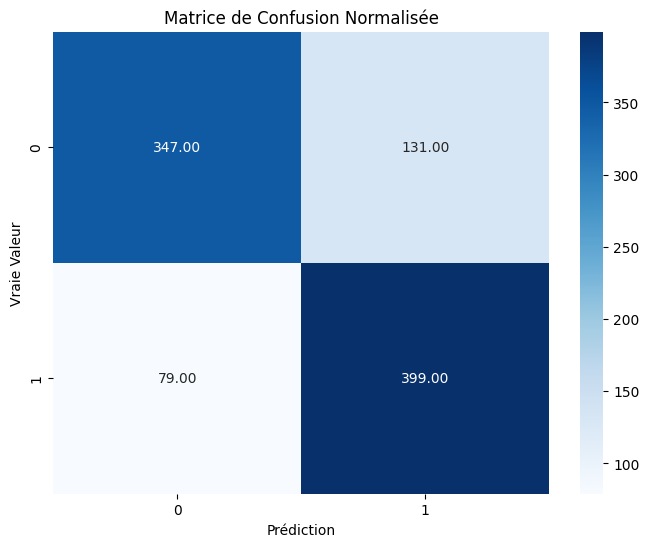

Accuracy: 0.79
Precision: 0.75
Recall: 0.85
F1 Score: 0.80
              precision    recall  f1-score   support

           0       0.83      0.72      0.77       478
           1       0.75      0.85      0.80       478

    accuracy                           0.79       956
   macro avg       0.79      0.79      0.79       956
weighted avg       0.79      0.79      0.79       956



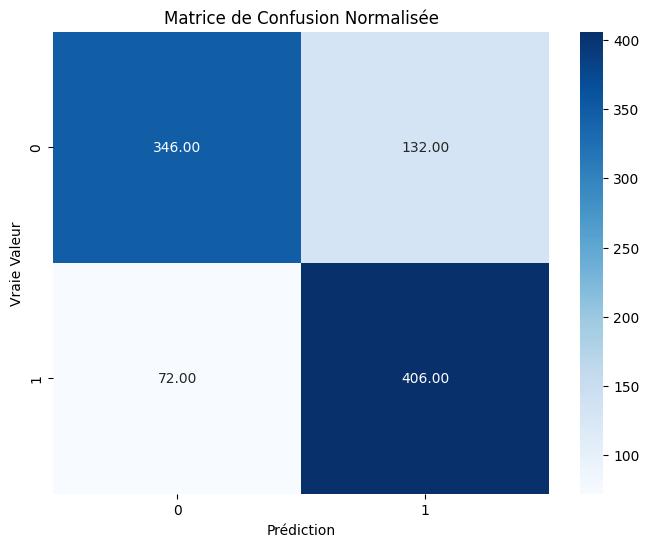

Accuracy: 0.77
Precision: 0.72
Recall: 0.87
F1 Score: 0.79
              precision    recall  f1-score   support

           0       0.84      0.66      0.74       478
           1       0.72      0.87      0.79       478

    accuracy                           0.77       956
   macro avg       0.78      0.77      0.76       956
weighted avg       0.78      0.77      0.76       956



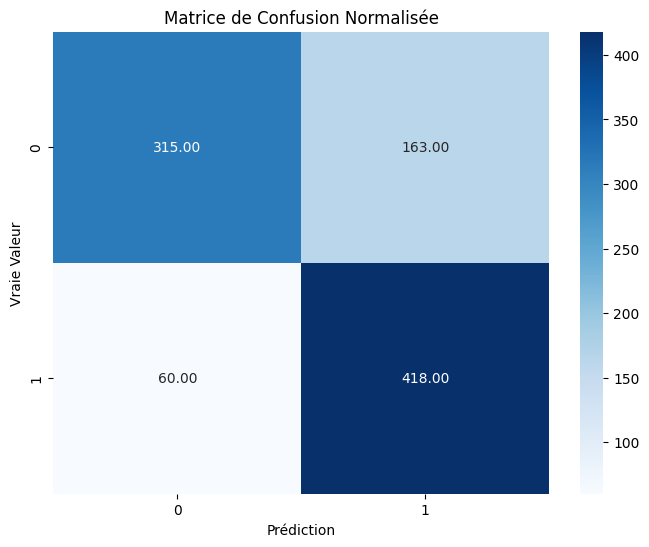

Modèle sélectionné avec un rappel proche de la moyenne des rappels.
Accuracy: 0.74
Precision: 0.67
Recall: 0.92
F1 Score: 0.78
              precision    recall  f1-score   support

           0       0.87      0.55      0.68       653
           1       0.67      0.92      0.78       653

    accuracy                           0.74      1306
   macro avg       0.77      0.74      0.73      1306
weighted avg       0.77      0.74      0.73      1306



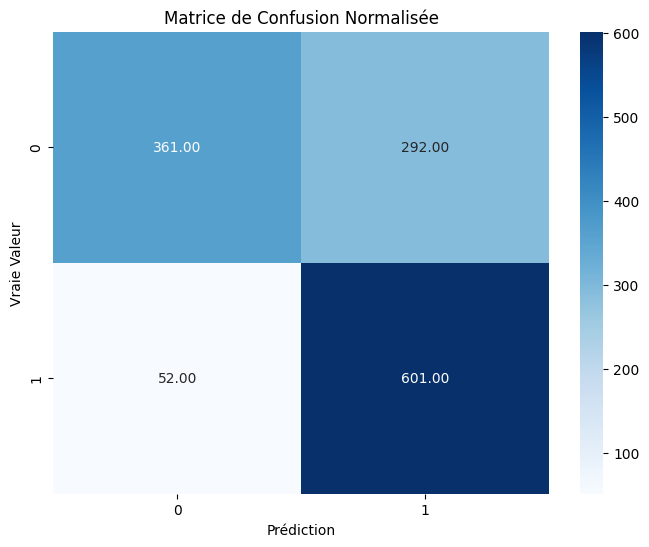

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier,RandomForestClassifier

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)


      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      random_forest = AdaBoostClassifier(LogisticRegression(C=0.1, solver='liblinear', max_iter=1000),n_estimators=100,random_state=42)
      random_forest.fit(X_train, y_train)
      models.append(random_forest)

      # Prédiction sur l'ensemble de test
      y_pred = random_forest.predict(X_val)


      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      recalls.append(recall)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()

mean_recall = np.mean(recalls)

# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = None
closest_recall_diff = float('inf')  # Initialisation avec une valeur infinie
for model, recall in zip(models, recalls):
    recall_diff = abs(recall - mean_recall)
    if recall_diff < closest_recall_diff:
        closest_model = model
        closest_recall_diff = recall_diff

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier,RandomForestClassifier
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)



      model = Sequential([
                Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
                Dense(64, activation='relu'),
                Dense(64, activation='relu'),
                Dense(1, activation='sigmoid')
            ])

      # Compiler le modèle
      model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])


# Entraîner le modèle
      history = model.fit(X_train, y_train, epochs=10)
      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      random_forest = AdaBoostClassifier(model)
      random_forest.fit(X_train, y_train)
      models.append(random_forest)

      # Prédiction sur l'ensemble de test
      y_pred = random_forest.predict(X_val)


      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      recalls.append(recall)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()

'''
# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = models[0]

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()
'''


Epoch 1/10
122/122 [==============================] - 1s 2ms/step - loss: 0.3985 - accuracy: 0.8148
Epoch 2/10
122/122 [==============================] - 0s 2ms/step - loss: 0.3071 - accuracy: 0.8635
Epoch 3/10
122/122 [==============================] - 0s 3ms/step - loss: 0.2789 - accuracy: 0.8746
Epoch 4/10
122/122 [==============================] - 0s 2ms/step - loss: 0.2680 - accuracy: 0.8839
Epoch 5/10
122/122 [==============================] - 0s 2ms/step - loss: 0.2519 - accuracy: 0.8934
Epoch 6/10
122/122 [==============================] - 0s 2ms/step - loss: 0.2419 - accuracy: 0.8929
Epoch 7/10
122/122 [==============================] - 0s 2ms/step - loss: 0.2289 - accuracy: 0.9017
Epoch 8/10
122/122 [==============================] - 0s 2ms/step - loss: 0.2200 - accuracy: 0.9051
Epoch 9/10
122/122 [==============================] - 0s 2ms/step - loss: 0.2170 - accuracy: 0.9082
Epoch 10/10
122/122 [==============================] - 0s 2ms/step - loss: 0.1990 - accuracy: 0.9172

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier,RandomForestClassifier
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)



      model = Sequential([
                Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
                Dense(64, activation='relu'),
                Dense(64, activation='relu'),
                Dense(1, activation='sigmoid')
            ])

      # Compiler le modèle
      model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])


# Entraîner le modèle
      history = model.fit(X_train, y_train, epochs=10)
      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      random_forest = AdaBoostClassifier(model)
      random_forest.fit(X_train, y_train)
      models.append(random_forest)

      # Prédiction sur l'ensemble de test
      y_pred = random_forest.predict(X_val)


      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      recalls.append(recall)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()

'''
# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = models[0]

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()
'''


Accuracy: 0.89
Precision: 0.88
Recall: 0.91
F1 Score: 0.90
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       484
           1       0.88      0.91      0.90       484

    accuracy                           0.89       968
   macro avg       0.90      0.89      0.89       968
weighted avg       0.90      0.89      0.89       968



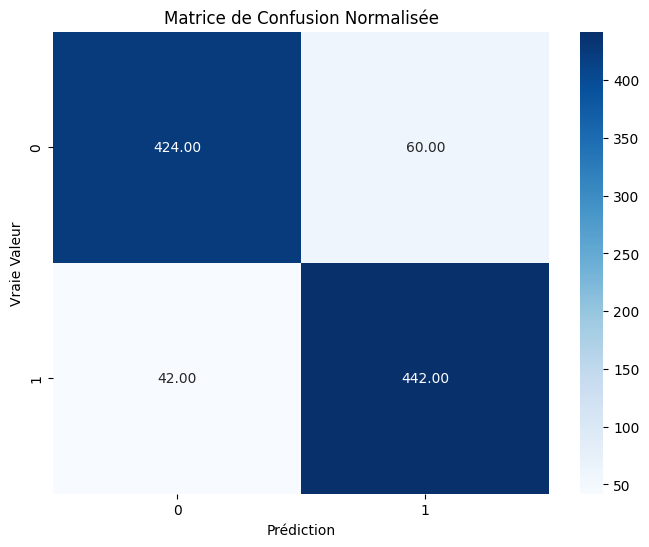

Accuracy: 0.90
Precision: 0.90
Recall: 0.90
F1 Score: 0.90
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       484
           1       0.90      0.90      0.90       484

    accuracy                           0.90       968
   macro avg       0.90      0.90      0.90       968
weighted avg       0.90      0.90      0.90       968



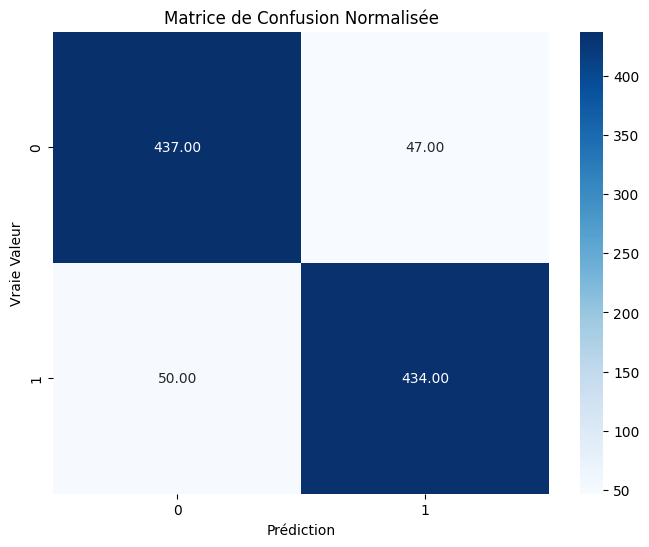

Accuracy: 0.90
Precision: 0.90
Recall: 0.88
F1 Score: 0.89
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       484
           1       0.90      0.88      0.89       484

    accuracy                           0.90       968
   macro avg       0.90      0.90      0.90       968
weighted avg       0.90      0.90      0.90       968



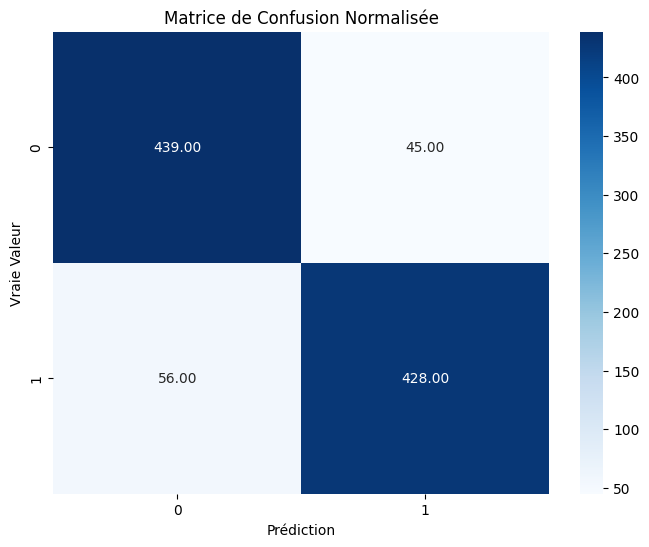

Accuracy: 0.90
Precision: 0.91
Recall: 0.89
F1 Score: 0.90
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       484
           1       0.91      0.89      0.90       484

    accuracy                           0.90       968
   macro avg       0.91      0.90      0.90       968
weighted avg       0.91      0.90      0.90       968



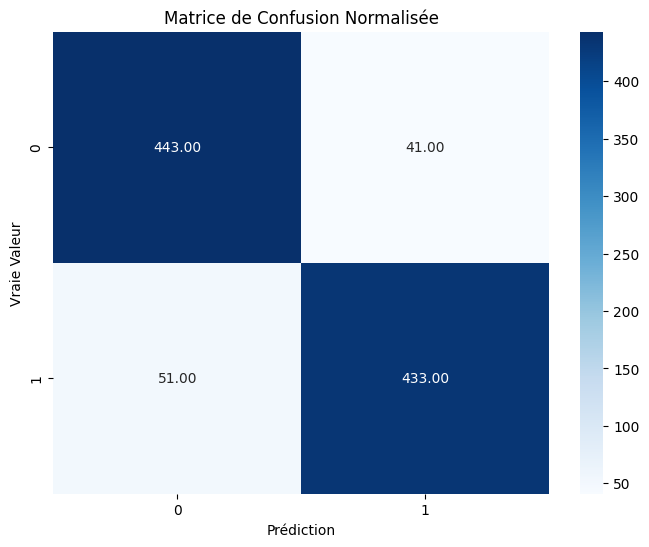

Accuracy: 0.90
Precision: 0.88
Recall: 0.92
F1 Score: 0.90
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       484
           1       0.88      0.92      0.90       484

    accuracy                           0.90       968
   macro avg       0.90      0.90      0.90       968
weighted avg       0.90      0.90      0.90       968



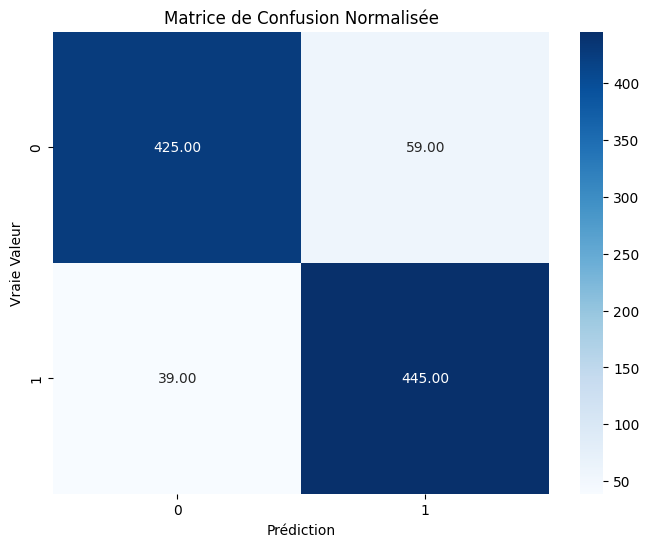

Modèle sélectionné avec un rappel proche de la moyenne des rappels.
Accuracy: 0.87
Precision: 0.87
Recall: 0.88
F1 Score: 0.87
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       622
           1       0.87      0.88      0.87       622

    accuracy                           0.87      1244
   macro avg       0.87      0.87      0.87      1244
weighted avg       0.87      0.87      0.87      1244



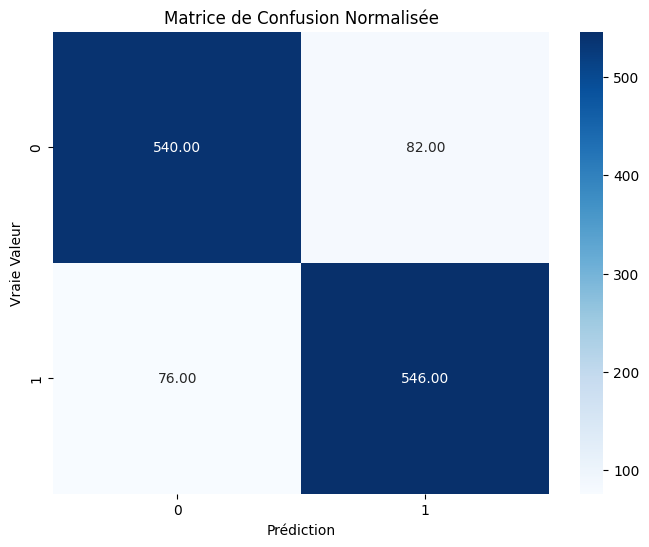

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier,RandomForestClassifier
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)


      #class_weight={0:1,1:99}
      random_forest =  BaggingClassifier(DecisionTreeClassifier(max_depth=10),n_estimators=100,random_state=42)
      random_forest.fit(X_train, y_train)
      models.append(random_forest)

      # Prédiction sur l'ensemble de test
      y_pred = random_forest.predict(X_val)


      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      recalls.append(recall)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()

mean_recall = np.mean(recalls)

# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = None
closest_recall_diff = float('inf')  # Initialisation avec une valeur infinie
for model, recall in zip(models, recalls):
    recall_diff = abs(recall - mean_recall)
    if recall_diff < closest_recall_diff:
        closest_model = model
        closest_recall_diff = recall_diff

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()


Accuracy: 0.83
Precision: 0.81
Recall: 0.85
F1 Score: 0.83
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       478
           1       0.81      0.85      0.83       478

    accuracy                           0.83       956
   macro avg       0.83      0.83      0.83       956
weighted avg       0.83      0.83      0.83       956



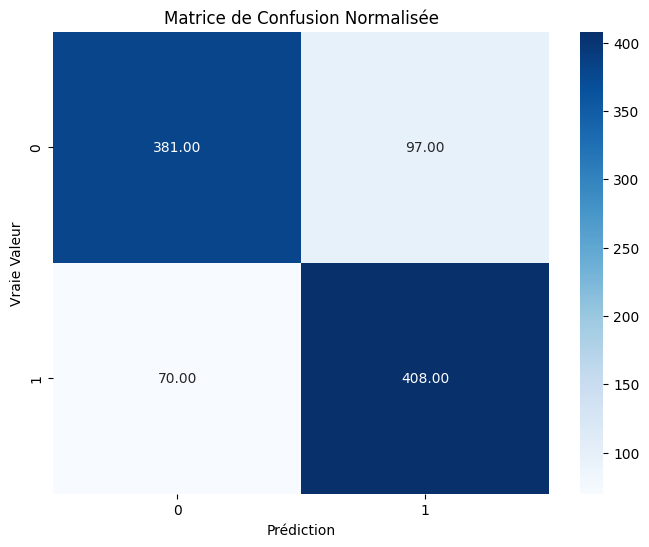

Accuracy: 0.81
Precision: 0.80
Recall: 0.83
F1 Score: 0.82
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       478
           1       0.80      0.83      0.82       478

    accuracy                           0.81       956
   macro avg       0.81      0.81      0.81       956
weighted avg       0.81      0.81      0.81       956



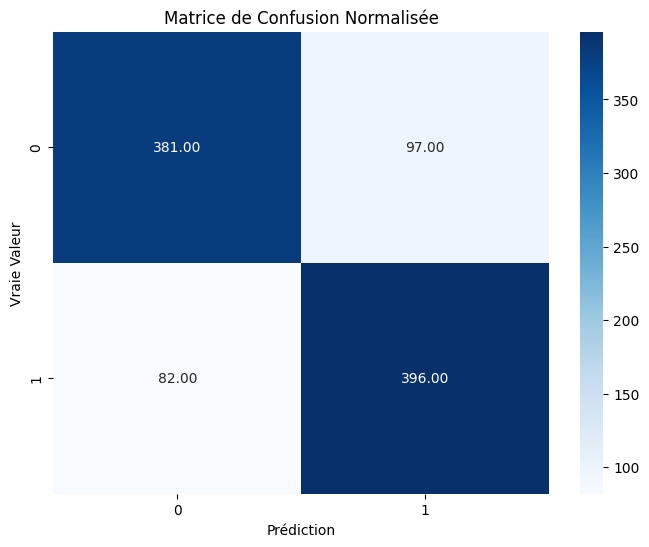

Accuracy: 0.81
Precision: 0.81
Recall: 0.81
F1 Score: 0.81
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       478
           1       0.81      0.81      0.81       478

    accuracy                           0.81       956
   macro avg       0.81      0.81      0.81       956
weighted avg       0.81      0.81      0.81       956



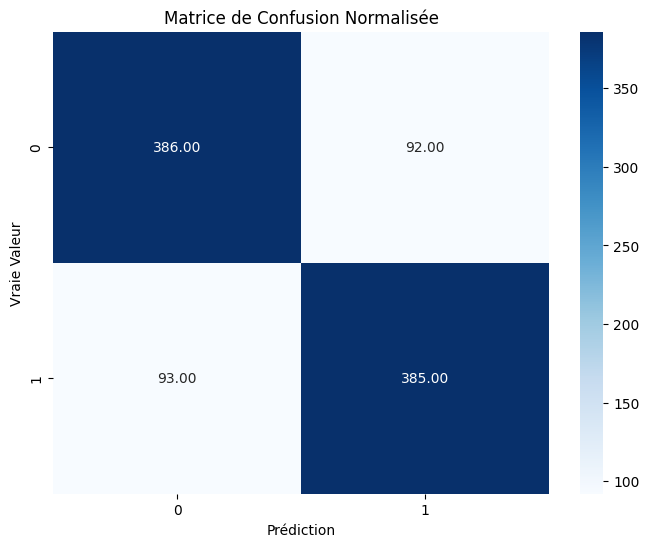

Accuracy: 0.80
Precision: 0.79
Recall: 0.82
F1 Score: 0.81
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       478
           1       0.79      0.82      0.81       478

    accuracy                           0.80       956
   macro avg       0.80      0.80      0.80       956
weighted avg       0.80      0.80      0.80       956



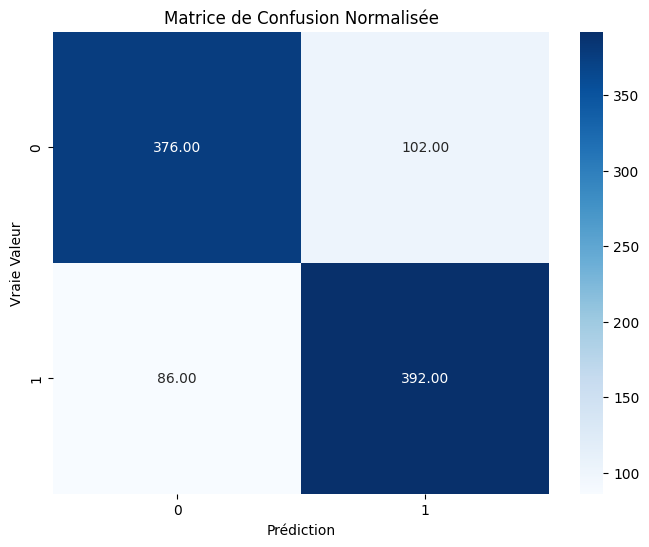

Accuracy: 0.80
Precision: 0.78
Recall: 0.85
F1 Score: 0.81
              precision    recall  f1-score   support

           0       0.83      0.76      0.79       478
           1       0.78      0.85      0.81       478

    accuracy                           0.80       956
   macro avg       0.81      0.80      0.80       956
weighted avg       0.81      0.80      0.80       956



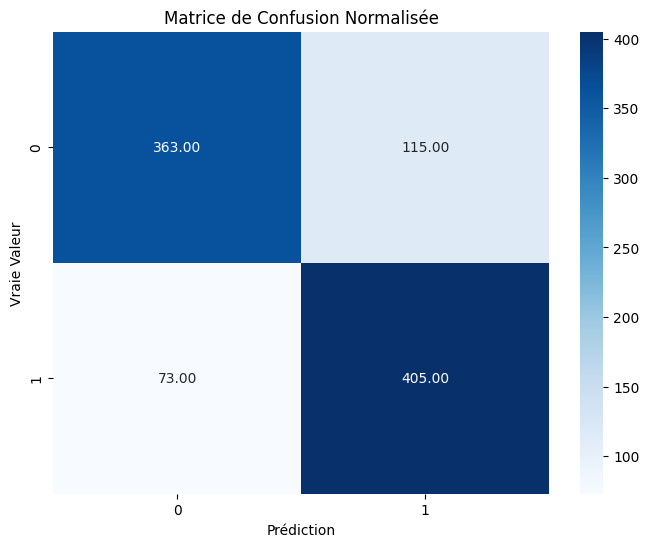

'\n# Trouver le modèle le plus proche de la moyenne des rappels\nclosest_model = models[0]\n\n# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test\nX_test = testset.drop(columns=[\'fire\'])\ny_test = testset[\'fire\']\nX_test = scaler.transform(X_test)\ny_pred = closest_model.predict(X_test)\n\n# Évaluation du modèle sélectionné\naccuracy = accuracy_score(y_test, y_pred)\nprecision = precision_score(y_test, y_pred)\nrecall = recall_score(y_test, y_pred)\nf1 = f1_score(y_test, y_pred)\n\nprint(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")\nprint(f"Accuracy: {accuracy:.2f}")\nprint(f"Precision: {precision:.2f}")\nprint(f"Recall: {recall:.2f}")\nprint(f"F1 Score: {f1:.2f}")\n\n# Affichage du rapport de classification\nprint(classification_report(y_test, y_pred))\n\n# Matrice de confusion\ncm = confusion_matrix(y_test, y_pred)\nplt.figure(figsize=(8, 6))\nsns.heatmap(cm, annot=True, cmap=\'Blues\', fmt=\'.2f\')\nplt.xlabel(\'Prédicti

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier,RandomForestClassifier
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)


      #class_weight={0:1,1:99}
      random_forest =  BaggingClassifier(LogisticRegression(C=0.1, solver='liblinear', max_iter=1000),n_estimators=100,random_state=42)
      random_forest.fit(X_train, y_train)
      models.append(random_forest)

      # Prédiction sur l'ensemble de test
      y_pred = random_forest.predict(X_val)


      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      recalls.append(recall)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()

'''
# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = models[0]

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()
'''


Accuracy: 0.83
Precision: 0.81
Recall: 0.86
F1 Score: 0.83
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       478
           1       0.81      0.86      0.83       478

    accuracy                           0.83       956
   macro avg       0.83      0.83      0.83       956
weighted avg       0.83      0.83      0.83       956



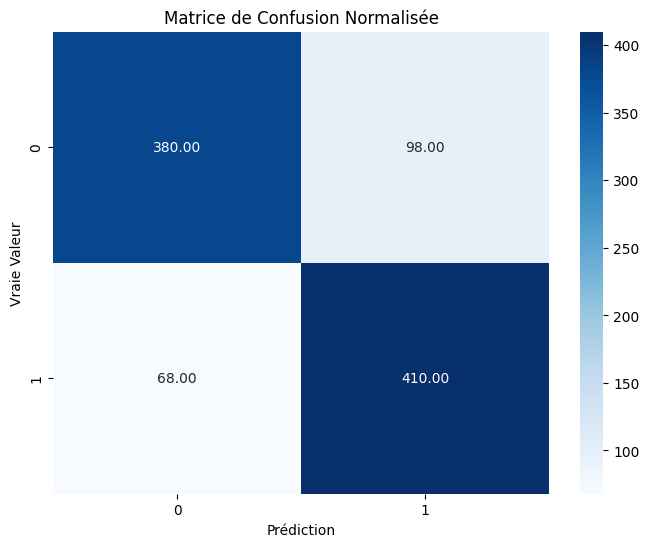

Accuracy: 0.81
Precision: 0.80
Recall: 0.83
F1 Score: 0.81
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       478
           1       0.80      0.83      0.81       478

    accuracy                           0.81       956
   macro avg       0.81      0.81      0.81       956
weighted avg       0.81      0.81      0.81       956



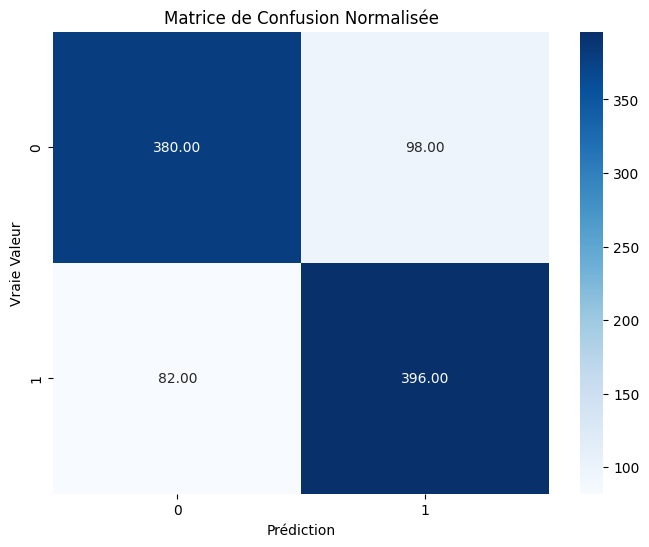

Accuracy: 0.80
Precision: 0.81
Recall: 0.80
F1 Score: 0.80
              precision    recall  f1-score   support

           0       0.80      0.81      0.80       478
           1       0.81      0.80      0.80       478

    accuracy                           0.80       956
   macro avg       0.80      0.80      0.80       956
weighted avg       0.80      0.80      0.80       956



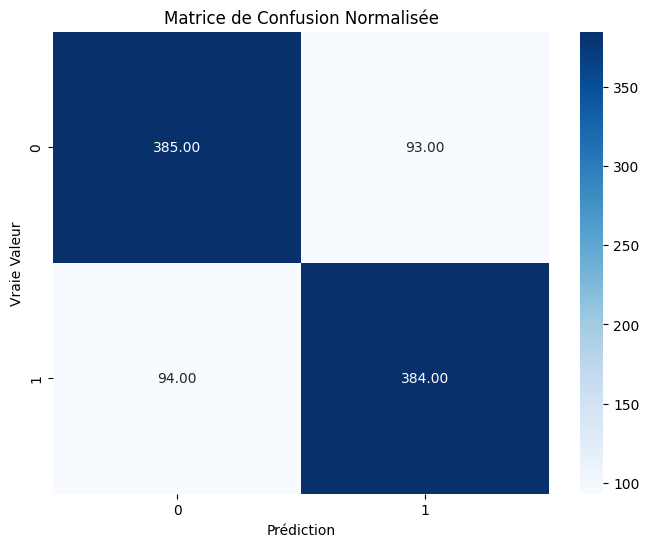

Accuracy: 0.80
Precision: 0.79
Recall: 0.82
F1 Score: 0.81
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       478
           1       0.79      0.82      0.81       478

    accuracy                           0.80       956
   macro avg       0.80      0.80      0.80       956
weighted avg       0.80      0.80      0.80       956



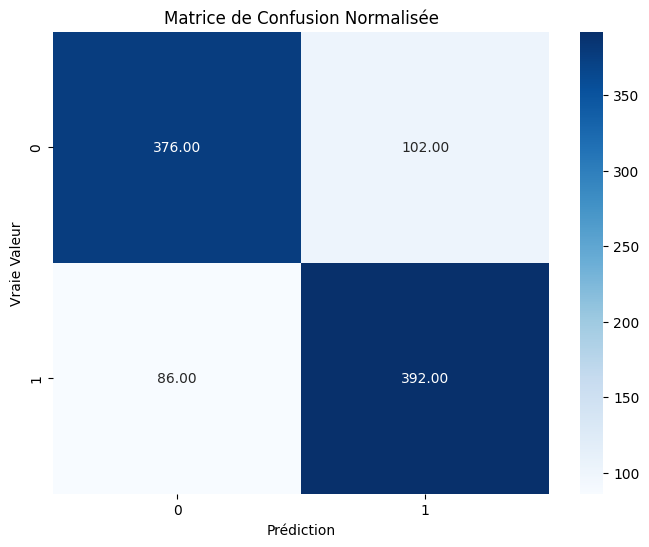

Accuracy: 0.80
Precision: 0.78
Recall: 0.85
F1 Score: 0.81
              precision    recall  f1-score   support

           0       0.83      0.76      0.79       478
           1       0.78      0.85      0.81       478

    accuracy                           0.80       956
   macro avg       0.80      0.80      0.80       956
weighted avg       0.80      0.80      0.80       956



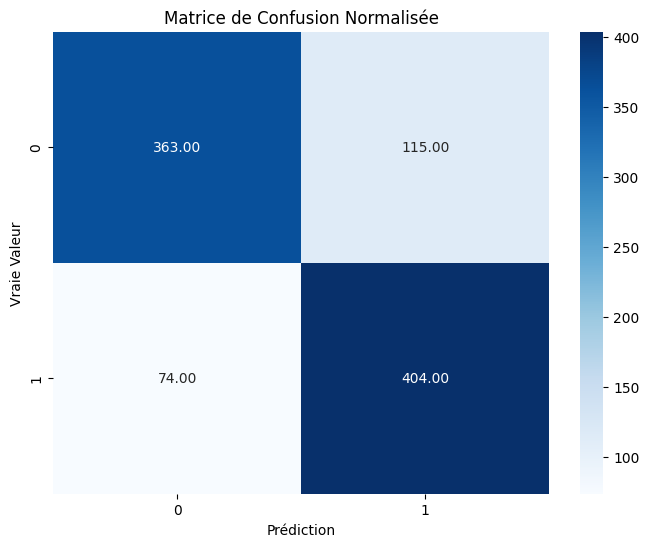

Modèle sélectionné avec un rappel proche de la moyenne des rappels.
Accuracy: 0.77
Precision: 0.71
Recall: 0.89
F1 Score: 0.79
              precision    recall  f1-score   support

           0       0.85      0.64      0.73       653
           1       0.71      0.89      0.79       653

    accuracy                           0.77      1306
   macro avg       0.78      0.77      0.76      1306
weighted avg       0.78      0.77      0.76      1306



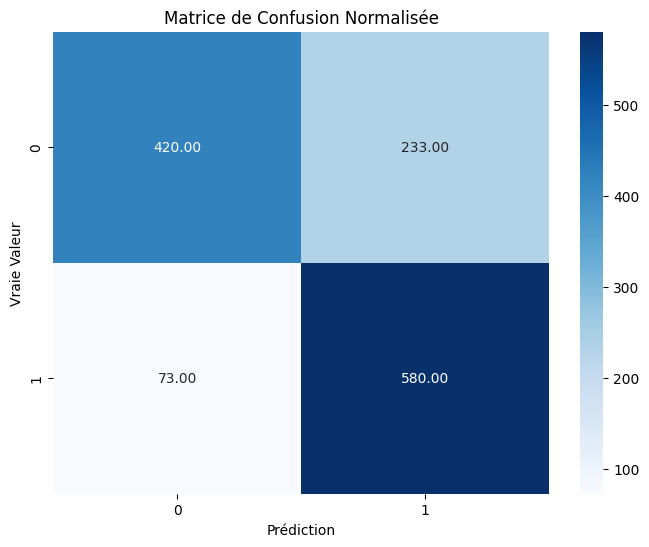

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)

      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      logistic_regression = LogisticRegression(C=0.1, solver='liblinear', max_iter=1000)
      logistic_regression.fit(X_train, y_train)
      models.append(logistic_regression)

      # Prédiction sur l'ensemble de test
      y_pred = logistic_regression.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      recalls.append(recall)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()
mean_recall = np.mean(recalls)

# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = None
closest_recall_diff = float('inf')  # Initialisation avec une valeur infinie
for model, recall in zip(models, recalls):
    recall_diff = abs(recall - mean_recall)
    if recall_diff < closest_recall_diff:
        closest_model = model
        closest_recall_diff = recall_diff

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()


Accuracy: 0.83
Precision: 0.81
Recall: 0.85
F1 Score: 0.83
              precision    recall  f1-score   support

           0       0.85      0.80      0.82       478
           1       0.81      0.85      0.83       478

    accuracy                           0.83       956
   macro avg       0.83      0.83      0.83       956
weighted avg       0.83      0.83      0.83       956



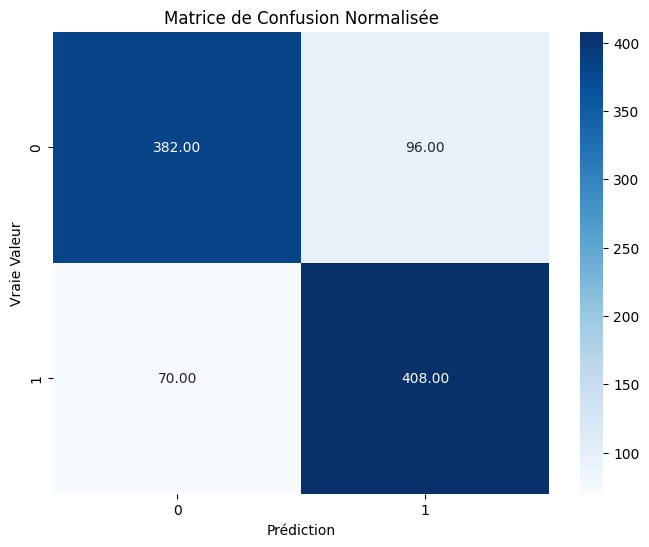

Accuracy: 0.81
Precision: 0.80
Recall: 0.82
F1 Score: 0.81
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       478
           1       0.80      0.82      0.81       478

    accuracy                           0.81       956
   macro avg       0.81      0.81      0.81       956
weighted avg       0.81      0.81      0.81       956



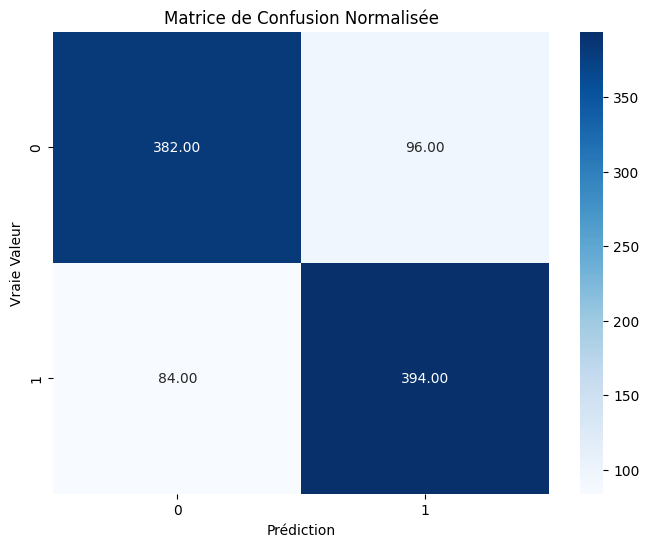

Accuracy: 0.80
Precision: 0.81
Recall: 0.80
F1 Score: 0.80
              precision    recall  f1-score   support

           0       0.80      0.81      0.80       478
           1       0.81      0.80      0.80       478

    accuracy                           0.80       956
   macro avg       0.80      0.80      0.80       956
weighted avg       0.80      0.80      0.80       956



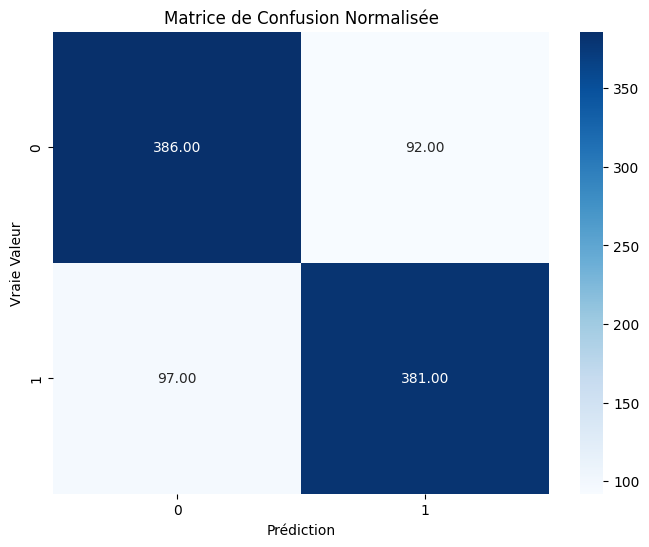

Accuracy: 0.80
Precision: 0.79
Recall: 0.82
F1 Score: 0.80
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       478
           1       0.79      0.82      0.80       478

    accuracy                           0.80       956
   macro avg       0.80      0.80      0.80       956
weighted avg       0.80      0.80      0.80       956



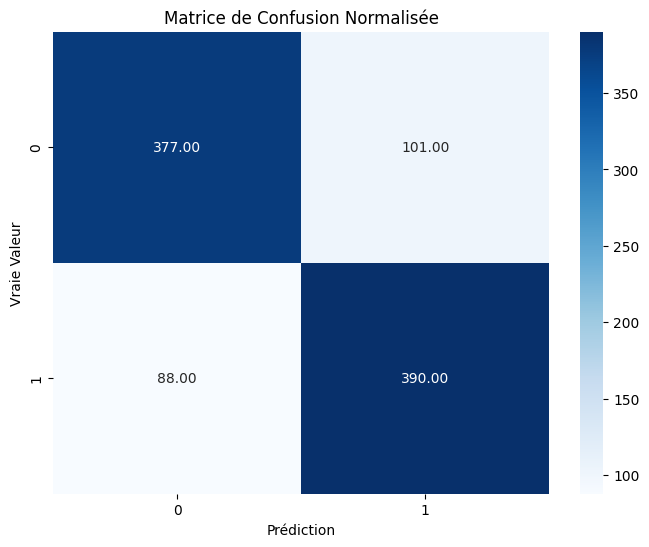

Accuracy: 0.80
Precision: 0.78
Recall: 0.84
F1 Score: 0.81
              precision    recall  f1-score   support

           0       0.83      0.76      0.80       478
           1       0.78      0.84      0.81       478

    accuracy                           0.80       956
   macro avg       0.81      0.80      0.80       956
weighted avg       0.81      0.80      0.80       956



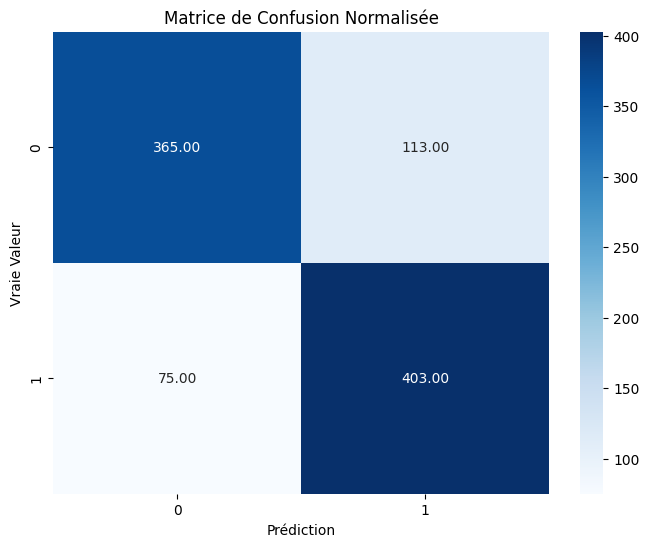

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)

      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      logistic_regression = LogisticRegression(C=0.1, solver='newton-cg', max_iter=1000)
      logistic_regression.fit(X_train, y_train)

      # Prédiction sur l'ensemble de test
      y_pred = logistic_regression.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


Accuracy: 0.83
Precision: 0.81
Recall: 0.86
F1 Score: 0.83
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       478
           1       0.81      0.86      0.83       478

    accuracy                           0.83       956
   macro avg       0.83      0.83      0.83       956
weighted avg       0.83      0.83      0.83       956



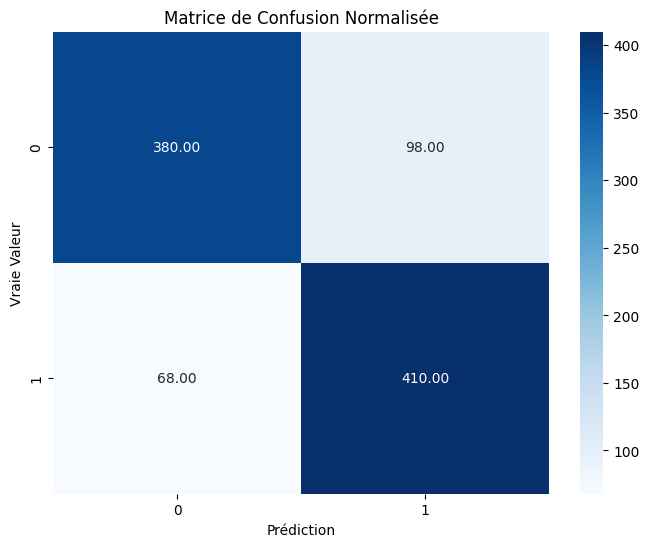

Accuracy: 0.81
Precision: 0.80
Recall: 0.83
F1 Score: 0.81
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       478
           1       0.80      0.83      0.81       478

    accuracy                           0.81       956
   macro avg       0.81      0.81      0.81       956
weighted avg       0.81      0.81      0.81       956



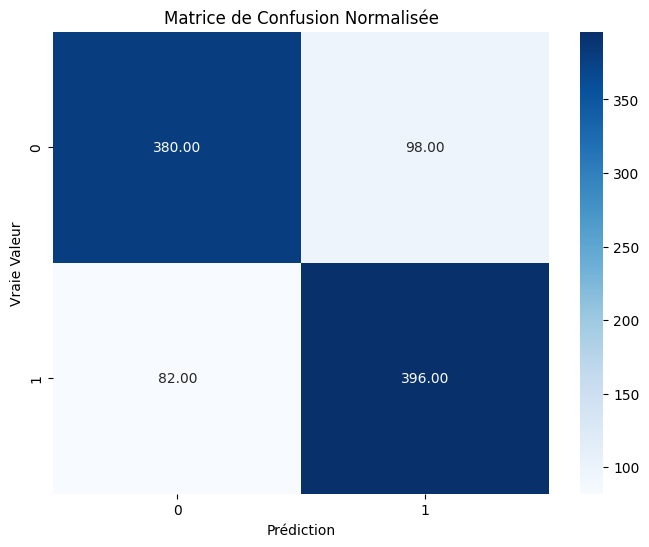

Accuracy: 0.80
Precision: 0.81
Recall: 0.80
F1 Score: 0.80
              precision    recall  f1-score   support

           0       0.80      0.81      0.80       478
           1       0.81      0.80      0.80       478

    accuracy                           0.80       956
   macro avg       0.80      0.80      0.80       956
weighted avg       0.80      0.80      0.80       956



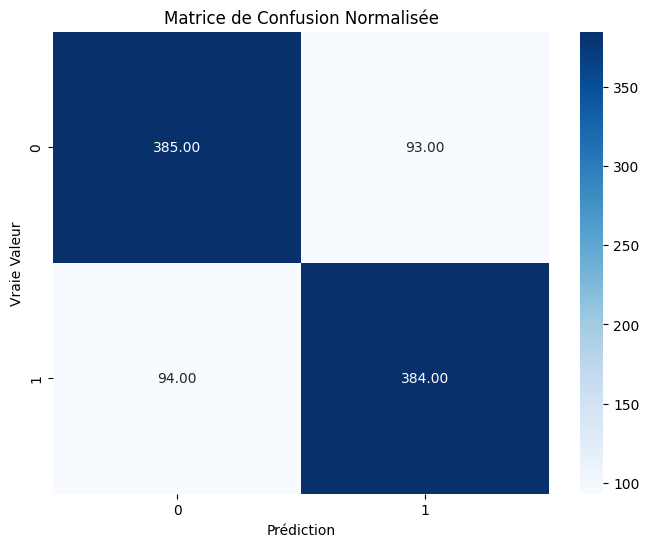

Accuracy: 0.80
Precision: 0.79
Recall: 0.82
F1 Score: 0.81
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       478
           1       0.79      0.82      0.81       478

    accuracy                           0.80       956
   macro avg       0.80      0.80      0.80       956
weighted avg       0.80      0.80      0.80       956



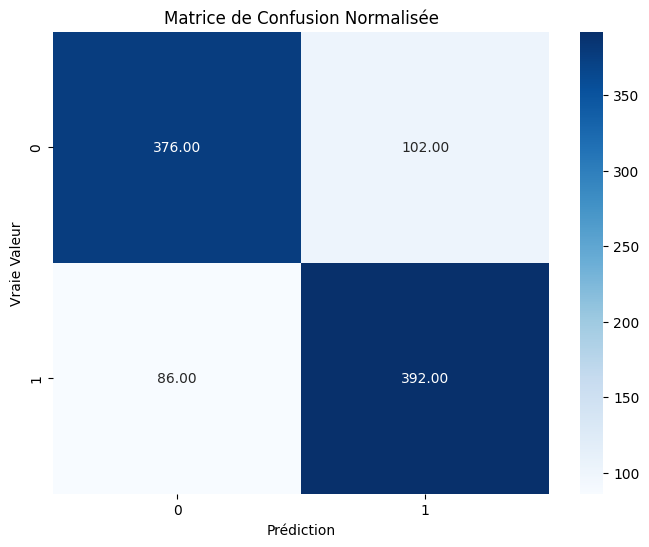

Accuracy: 0.80
Precision: 0.78
Recall: 0.85
F1 Score: 0.81
              precision    recall  f1-score   support

           0       0.83      0.76      0.79       478
           1       0.78      0.85      0.81       478

    accuracy                           0.80       956
   macro avg       0.80      0.80      0.80       956
weighted avg       0.80      0.80      0.80       956



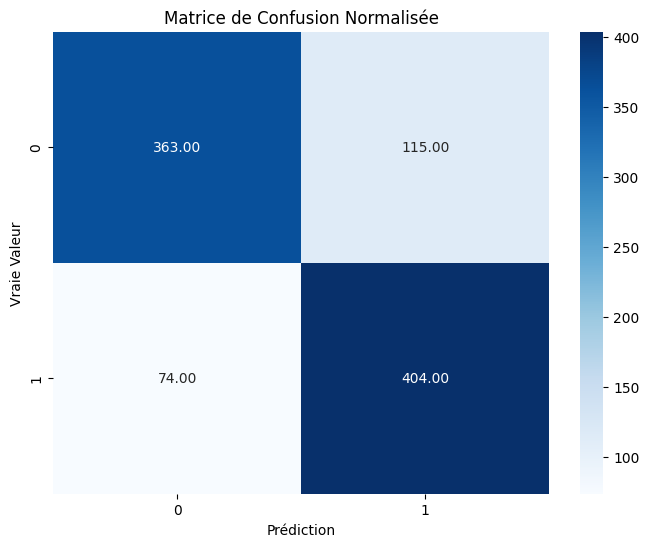

Modèle sélectionné avec un rappel proche de la moyenne des rappels.
Accuracy: 0.77
Precision: 0.71
Recall: 0.89
F1 Score: 0.79
              precision    recall  f1-score   support

           0       0.85      0.64      0.73       653
           1       0.71      0.89      0.79       653

    accuracy                           0.77      1306
   macro avg       0.78      0.77      0.76      1306
weighted avg       0.78      0.77      0.76      1306



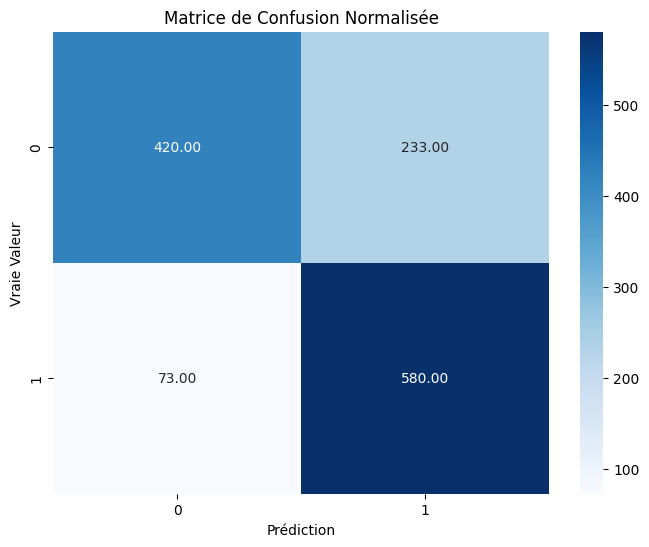

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

X = trainset.drop(columns=['fire'])
y = trainset['fire']
recalls=[]
models=[]
stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)
      logistic_regression = LogisticRegression(tol=1e-6,C=0.1, solver='liblinear', max_iter=1000)
      logistic_regression.fit(X_train, y_train)
      models.append(logistic_regression)

      # Prédiction sur l'ensemble de test
      y_pred = logistic_regression.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)
      recalls.append(recall)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()

mean_recall = np.mean(recalls)

# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = None
closest_recall_diff = float('inf')  # Initialisation avec une valeur infinie
for model, recall in zip(models, recalls):
    recall_diff = abs(recall - mean_recall)
    if recall_diff < closest_recall_diff:
        closest_model = model
        closest_recall_diff = recall_diff

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()

Accuracy: 0.83
Precision: 0.81
Recall: 0.85
F1 Score: 0.83
              precision    recall  f1-score   support

           0       0.85      0.80      0.82       478
           1       0.81      0.85      0.83       478

    accuracy                           0.83       956
   macro avg       0.83      0.83      0.83       956
weighted avg       0.83      0.83      0.83       956



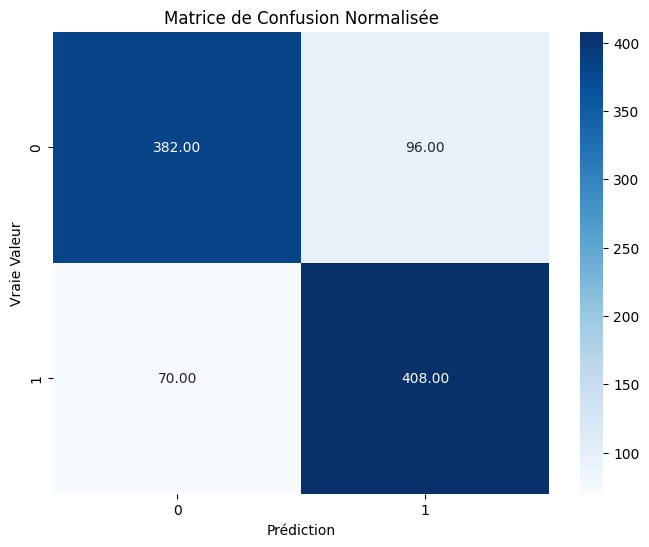

Accuracy: 0.81
Precision: 0.80
Recall: 0.82
F1 Score: 0.81
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       478
           1       0.80      0.82      0.81       478

    accuracy                           0.81       956
   macro avg       0.81      0.81      0.81       956
weighted avg       0.81      0.81      0.81       956



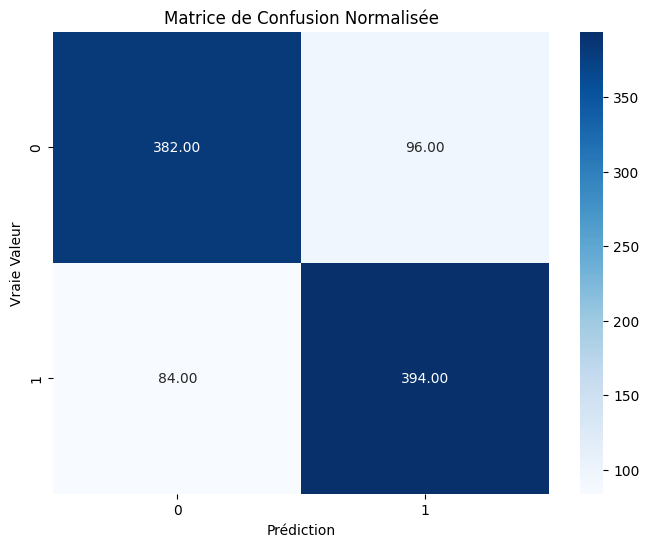

Accuracy: 0.80
Precision: 0.81
Recall: 0.80
F1 Score: 0.80
              precision    recall  f1-score   support

           0       0.80      0.81      0.80       478
           1       0.81      0.80      0.80       478

    accuracy                           0.80       956
   macro avg       0.80      0.80      0.80       956
weighted avg       0.80      0.80      0.80       956



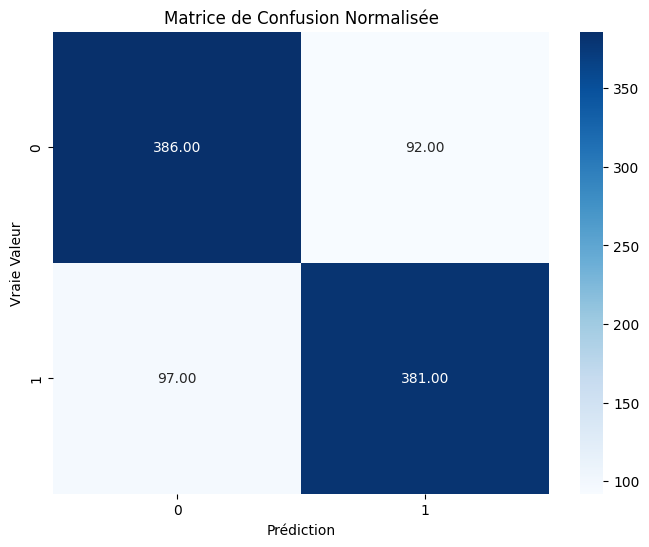

Accuracy: 0.80
Precision: 0.79
Recall: 0.82
F1 Score: 0.80
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       478
           1       0.79      0.82      0.80       478

    accuracy                           0.80       956
   macro avg       0.80      0.80      0.80       956
weighted avg       0.80      0.80      0.80       956



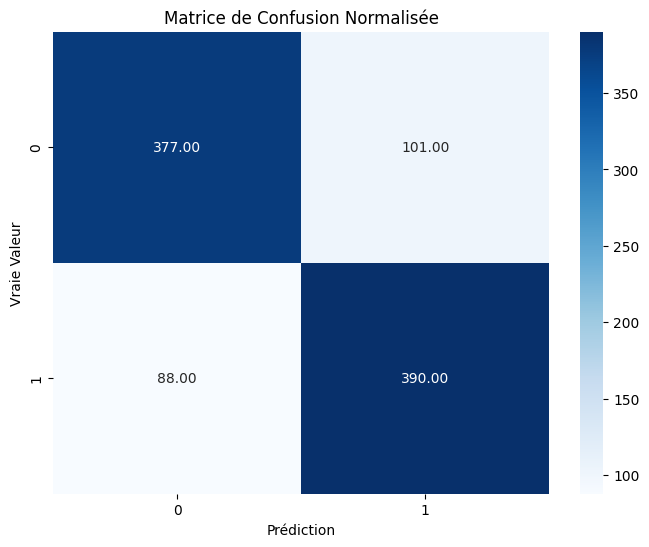

Accuracy: 0.80
Precision: 0.78
Recall: 0.84
F1 Score: 0.81
              precision    recall  f1-score   support

           0       0.83      0.76      0.80       478
           1       0.78      0.84      0.81       478

    accuracy                           0.80       956
   macro avg       0.81      0.80      0.80       956
weighted avg       0.81      0.80      0.80       956



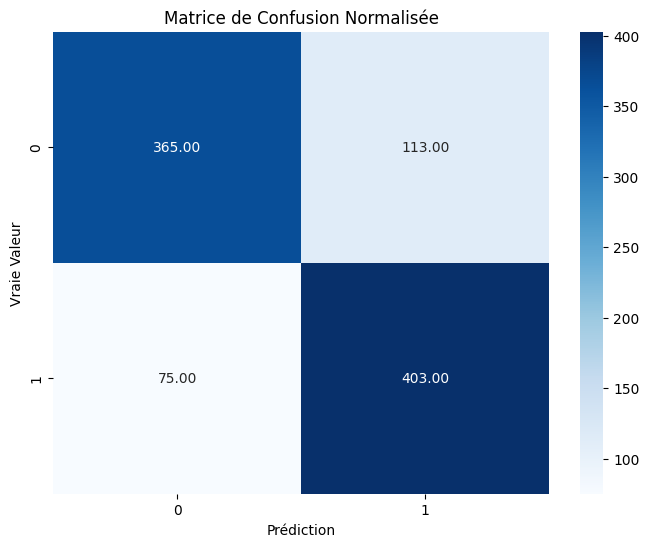

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)
      logistic_regression = LogisticRegression(C=0.1, solver='sag', max_iter=500)
      logistic_regression.fit(X_train, y_train)

      # Prédiction sur l'ensemble de test
      y_pred = logistic_regression.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()

Epoch 1/10
120/120 [==============================] - 1s 2ms/step - loss: 0.4948 - accuracy: 0.7522
Epoch 2/10
120/120 [==============================] - 0s 2ms/step - loss: 0.4027 - accuracy: 0.8113
Epoch 3/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3800 - accuracy: 0.8246
Epoch 4/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3508 - accuracy: 0.8380
Epoch 5/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3411 - accuracy: 0.8484
Epoch 6/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3285 - accuracy: 0.8487
Epoch 7/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3126 - accuracy: 0.8573
Epoch 8/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3037 - accuracy: 0.8636
Epoch 9/10
120/120 [==============================] - 0s 2ms/step - loss: 0.2904 - accuracy: 0.8680
Epoch 10/10
30/30 [==============================] - 0s 1ms/step
Accuracy: 0.86
Precision: 0.83
Reca

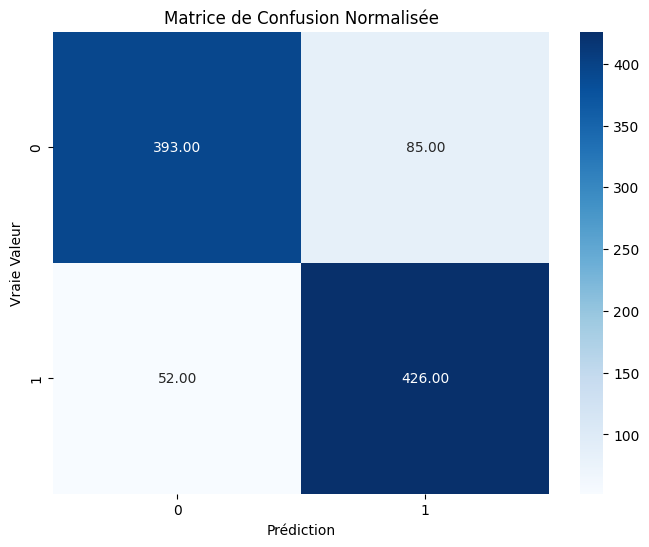

Epoch 1/10
120/120 [==============================] - 1s 3ms/step - loss: 0.4974 - accuracy: 0.7465
Epoch 2/10
120/120 [==============================] - 0s 3ms/step - loss: 0.4025 - accuracy: 0.8082
Epoch 3/10
120/120 [==============================] - 0s 3ms/step - loss: 0.3767 - accuracy: 0.8202
Epoch 4/10
120/120 [==============================] - 0s 3ms/step - loss: 0.3577 - accuracy: 0.8346
Epoch 5/10
120/120 [==============================] - 0s 3ms/step - loss: 0.3425 - accuracy: 0.8340
Epoch 6/10
120/120 [==============================] - 0s 3ms/step - loss: 0.3256 - accuracy: 0.8500
Epoch 7/10
120/120 [==============================] - 0s 3ms/step - loss: 0.3134 - accuracy: 0.8549
Epoch 8/10
120/120 [==============================] - 0s 3ms/step - loss: 0.3020 - accuracy: 0.8636
Epoch 9/10
120/120 [==============================] - 0s 3ms/step - loss: 0.2955 - accuracy: 0.8664
Epoch 10/10
30/30 [==============================] - 0s 1ms/step
Accuracy: 0.84
Precision: 0.82
Reca

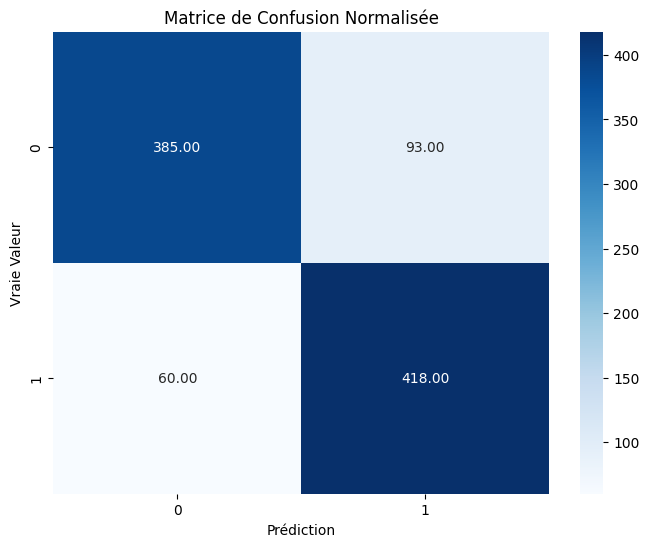

Epoch 1/10
120/120 [==============================] - 2s 2ms/step - loss: 0.4922 - accuracy: 0.7493
Epoch 2/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3947 - accuracy: 0.8152
Epoch 3/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3711 - accuracy: 0.8280
Epoch 4/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3426 - accuracy: 0.8450
Epoch 5/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3281 - accuracy: 0.8505
Epoch 6/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3151 - accuracy: 0.8625
Epoch 7/10
120/120 [==============================] - 0s 2ms/step - loss: 0.2988 - accuracy: 0.8641
Epoch 8/10
120/120 [==============================] - 0s 2ms/step - loss: 0.2903 - accuracy: 0.8693
Epoch 9/10
120/120 [==============================] - 0s 2ms/step - loss: 0.2793 - accuracy: 0.8790
Epoch 10/10
30/30 [==============================] - 0s 1ms/step
Accuracy: 0.83
Precision: 0.83
Reca

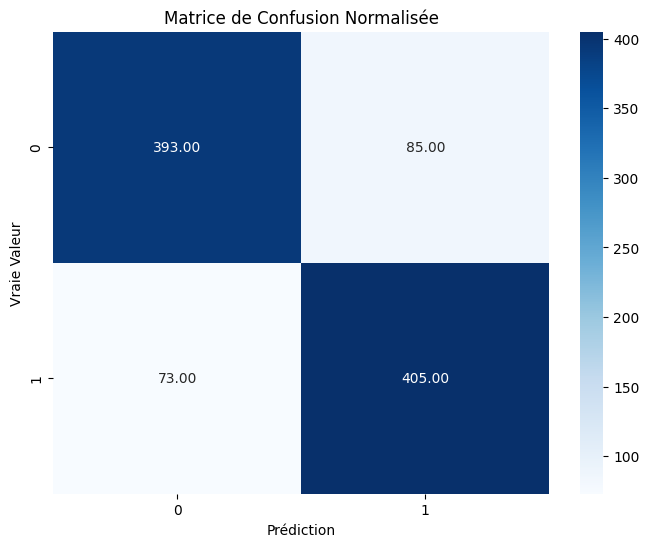

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)


      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}


      # Créer le modèle séquentiel
      model = Sequential([
                Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
                Dense(64, activation='relu'),
                Dense(64, activation='relu'),
                Dense(1, activation='sigmoid')
            ])

      # Compiler le modèle
      model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])


# Entraîner le modèle
      history = model.fit(X_train, y_train, epochs=10)
      y_pred = (model.predict(X_val) > 0.5).astype("int32")


      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


Epoch 1/10
120/120 [==============================] - 3s 4ms/step - loss: 0.5237 - accuracy: 0.7311
Epoch 2/10
120/120 [==============================] - 0s 3ms/step - loss: 0.4132 - accuracy: 0.8074
Epoch 3/10
120/120 [==============================] - 0s 3ms/step - loss: 0.3877 - accuracy: 0.8199
Epoch 4/10
120/120 [==============================] - 0s 4ms/step - loss: 0.3558 - accuracy: 0.8346
Epoch 5/10
120/120 [==============================] - 1s 5ms/step - loss: 0.3344 - accuracy: 0.8495
Epoch 6/10
120/120 [==============================] - 1s 4ms/step - loss: 0.3232 - accuracy: 0.8552
Epoch 7/10
120/120 [==============================] - 0s 4ms/step - loss: 0.3051 - accuracy: 0.8680
Epoch 8/10
120/120 [==============================] - 1s 4ms/step - loss: 0.2906 - accuracy: 0.8711
Epoch 9/10
120/120 [==============================] - 0s 4ms/step - loss: 0.2706 - accuracy: 0.8806
Epoch 10/10
30/30 [==============================] - 0s 3ms/step
Accuracy: 0.86
Precision: 0.86
Reca

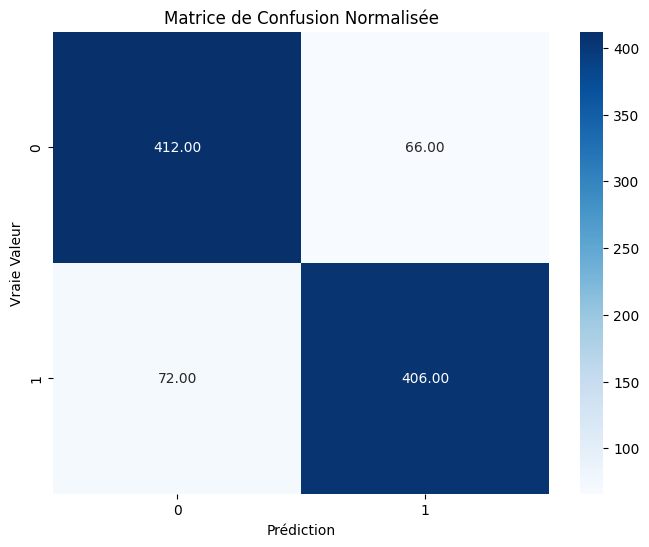

Epoch 1/10
120/120 [==============================] - 1s 3ms/step - loss: 0.4912 - accuracy: 0.7394
Epoch 2/10
120/120 [==============================] - 0s 2ms/step - loss: 0.4078 - accuracy: 0.8105
Epoch 3/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3767 - accuracy: 0.8170
Epoch 4/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3579 - accuracy: 0.8233
Epoch 5/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3423 - accuracy: 0.8411
Epoch 6/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3274 - accuracy: 0.8474
Epoch 7/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3126 - accuracy: 0.8518
Epoch 8/10
120/120 [==============================] - 0s 2ms/step - loss: 0.2994 - accuracy: 0.8549
Epoch 9/10
120/120 [==============================] - 0s 2ms/step - loss: 0.2970 - accuracy: 0.8602
Epoch 10/10
30/30 [==============================] - 0s 2ms/step
Accuracy: 0.84
Precision: 0.83
Reca

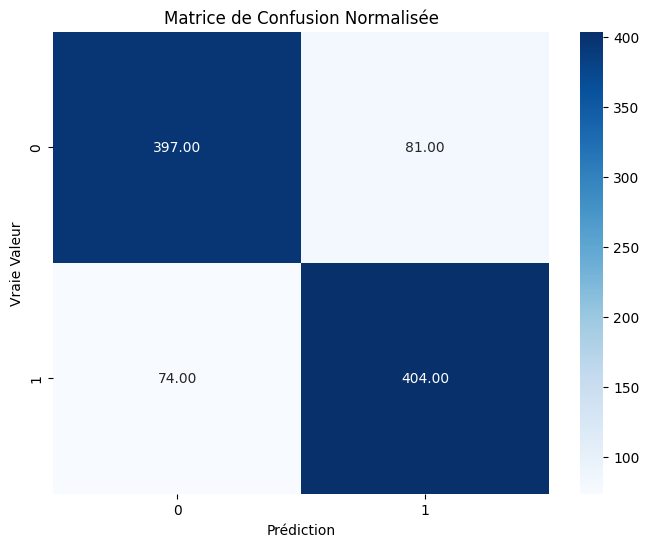

Epoch 1/10
120/120 [==============================] - 1s 2ms/step - loss: 0.5022 - accuracy: 0.7467
Epoch 2/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3973 - accuracy: 0.8084
Epoch 3/10
120/120 [==============================] - 0s 2ms/step - loss: 0.3669 - accuracy: 0.8330
Epoch 4/10
120/120 [==============================] - 0s 4ms/step - loss: 0.3389 - accuracy: 0.8393
Epoch 5/10
120/120 [==============================] - 0s 3ms/step - loss: 0.3168 - accuracy: 0.8536
Epoch 6/10
120/120 [==============================] - 0s 4ms/step - loss: 0.3008 - accuracy: 0.8615
Epoch 7/10
120/120 [==============================] - 0s 3ms/step - loss: 0.2802 - accuracy: 0.8782
Epoch 8/10
120/120 [==============================] - 0s 4ms/step - loss: 0.2827 - accuracy: 0.8745
Epoch 9/10
120/120 [==============================] - 0s 3ms/step - loss: 0.2590 - accuracy: 0.8845
Epoch 10/10
30/30 [==============================] - 0s 2ms/step
Accuracy: 0.82
Precision: 0.80
Reca

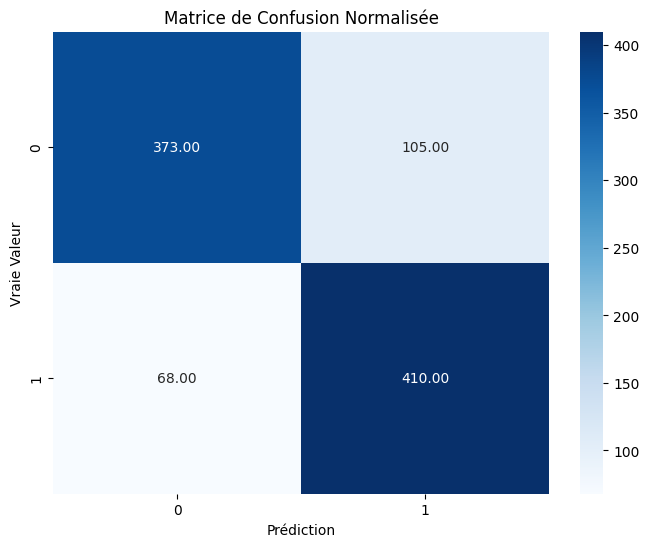

41/41 [==============================] - 0s 2ms/step
Modèle sélectionné avec un rappel proche de la moyenne des rappels.
Accuracy: 0.79
Precision: 0.74
Recall: 0.89
F1 Score: 0.81
              precision    recall  f1-score   support

           0       0.86      0.69      0.77       653
           1       0.74      0.89      0.81       653

    accuracy                           0.79      1306
   macro avg       0.80      0.79      0.79      1306
weighted avg       0.80      0.79      0.79      1306



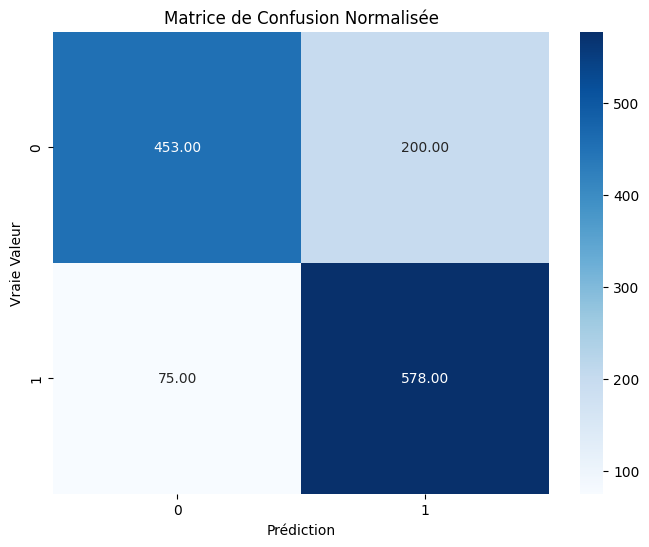

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]

stratified_split = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)


      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}


      # Créer le modèle séquentiel
      model = Sequential([
                Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
                Dense(64, activation='relu'),
                Dense(64, activation='relu'),
                Dense(64, activation='relu'),
                Dense(64, activation='relu'),
                Dense(1, activation='sigmoid')
            ])

      # Compiler le modèle
      model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])


# Entraîner le modèle
      history = model.fit(X_train, y_train, epochs=10)
      y_pred = (model.predict(X_val) > 0.5).astype("int32")
      models.append(model)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      recalls.append(recall)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()
mean_recall = np.mean(recalls)

# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = None
closest_recall_diff = float('inf')  # Initialisation avec une valeur infinie
for model, recall in zip(models, recalls):
    recall_diff = abs(recall - mean_recall)
    if recall_diff < closest_recall_diff:
        closest_model = model
        closest_recall_diff = recall_diff

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = (closest_model.predict(X_test) > 0.5).astype("int32")

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()


Epoch 1/100
122/122 [==============================] - 2s 3ms/step - loss: 0.4189 - accuracy: 0.8001
Epoch 2/100
122/122 [==============================] - 0s 2ms/step - loss: 0.3043 - accuracy: 0.8674
Epoch 3/100
122/122 [==============================] - 0s 3ms/step - loss: 0.2719 - accuracy: 0.8744
Epoch 4/100
122/122 [==============================] - 0s 2ms/step - loss: 0.2623 - accuracy: 0.8878
Epoch 5/100
122/122 [==============================] - 0s 2ms/step - loss: 0.2612 - accuracy: 0.8873
Epoch 6/100
122/122 [==============================] - 0s 2ms/step - loss: 0.2317 - accuracy: 0.9022
Epoch 7/100
122/122 [==============================] - 0s 3ms/step - loss: 0.2195 - accuracy: 0.9020
Epoch 8/100
122/122 [==============================] - 0s 3ms/step - loss: 0.2161 - accuracy: 0.9071
Epoch 9/100
122/122 [==============================] - 0s 2ms/step - loss: 0.2029 - accuracy: 0.9100
Epoch 10/100
122/122 [==============================] - 0s 2ms/step - loss: 0.1986 - accura

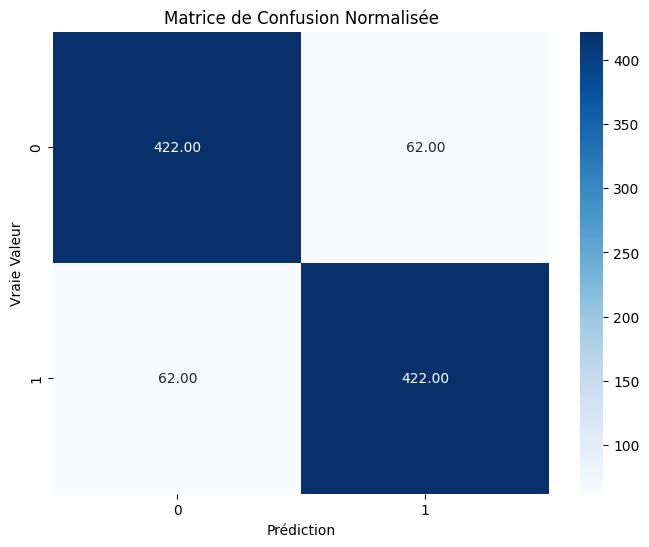

Epoch 1/100
122/122 [==============================] - 2s 3ms/step - loss: 0.4313 - accuracy: 0.8034
Epoch 2/100
122/122 [==============================] - 1s 4ms/step - loss: 0.3242 - accuracy: 0.8563
Epoch 3/100
122/122 [==============================] - 0s 4ms/step - loss: 0.2970 - accuracy: 0.8718
Epoch 4/100
122/122 [==============================] - 0s 4ms/step - loss: 0.2856 - accuracy: 0.8785
Epoch 5/100
122/122 [==============================] - 1s 4ms/step - loss: 0.2583 - accuracy: 0.8947
Epoch 6/100
122/122 [==============================] - 0s 4ms/step - loss: 0.2626 - accuracy: 0.8934
Epoch 7/100
122/122 [==============================] - 1s 4ms/step - loss: 0.2360 - accuracy: 0.8994
Epoch 8/100
122/122 [==============================] - 1s 4ms/step - loss: 0.2212 - accuracy: 0.9079
Epoch 9/100
122/122 [==============================] - 0s 4ms/step - loss: 0.2110 - accuracy: 0.9149
Epoch 10/100
122/122 [==============================] - 0s 4ms/step - loss: 0.2046 - accura

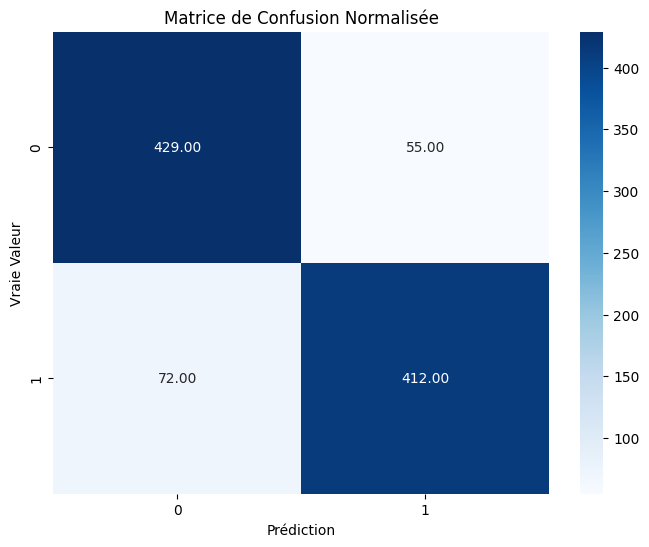

Epoch 1/100
122/122 [==============================] - 1s 2ms/step - loss: 0.4314 - accuracy: 0.7913
Epoch 2/100
122/122 [==============================] - 0s 3ms/step - loss: 0.3170 - accuracy: 0.8633
Epoch 3/100
122/122 [==============================] - 0s 3ms/step - loss: 0.2916 - accuracy: 0.8756
Epoch 4/100
122/122 [==============================] - 0s 3ms/step - loss: 0.2691 - accuracy: 0.8847
Epoch 5/100
122/122 [==============================] - 0s 3ms/step - loss: 0.2590 - accuracy: 0.8883
Epoch 6/100
122/122 [==============================] - 0s 3ms/step - loss: 0.2472 - accuracy: 0.8909
Epoch 7/100
122/122 [==============================] - 0s 4ms/step - loss: 0.2433 - accuracy: 0.8940
Epoch 8/100
122/122 [==============================] - 1s 4ms/step - loss: 0.2207 - accuracy: 0.9051
Epoch 9/100
122/122 [==============================] - 0s 3ms/step - loss: 0.2158 - accuracy: 0.9107
Epoch 10/100
122/122 [==============================] - 0s 4ms/step - loss: 0.2068 - accura

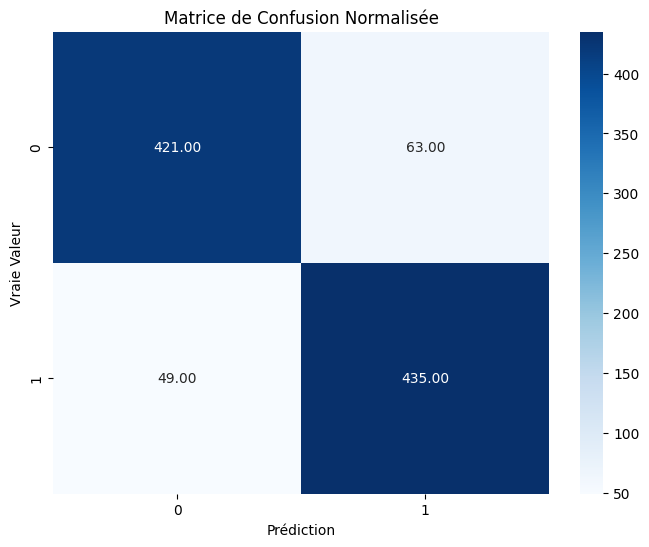

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)


      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}


      # Créer le modèle séquentiel
      model = Sequential([
                Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
                Dense(64, activation='relu'),
                Dense(64, activation='relu'),
                Dense(64, activation='relu'),
                Dense(64, activation='relu'),
                Dense(1, activation='sigmoid')
            ])

      # Compiler le modèle
      model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])


# Entraîner le modèle
      history = model.fit(X_train, y_train, epochs=100)
      y_pred = (model.predict(X_val) > 0.5).astype("int32")


      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


Epoch 1/10
122/122 [==============================] - 1s 4ms/step - loss: 0.6377 - accuracy: 0.7005
Epoch 2/10
122/122 [==============================] - 0s 3ms/step - loss: 0.5446 - accuracy: 0.7500
Epoch 3/10
122/122 [==============================] - 0s 4ms/step - loss: 0.4487 - accuracy: 0.7980
Epoch 4/10
122/122 [==============================] - 0s 3ms/step - loss: 0.3822 - accuracy: 0.8336
Epoch 5/10
122/122 [==============================] - 0s 3ms/step - loss: 0.3466 - accuracy: 0.8478
Epoch 6/10
122/122 [==============================] - 0s 3ms/step - loss: 0.3253 - accuracy: 0.8602
Epoch 7/10
122/122 [==============================] - 0s 4ms/step - loss: 0.3093 - accuracy: 0.8638
Epoch 8/10
122/122 [==============================] - 1s 5ms/step - loss: 0.2965 - accuracy: 0.8705
Epoch 9/10
122/122 [==============================] - 1s 4ms/step - loss: 0.2896 - accuracy: 0.8751
Epoch 10/10
31/31 [==============================] - 0s 4ms/step
Accuracy: 0.88
Precision: 0.87
Reca

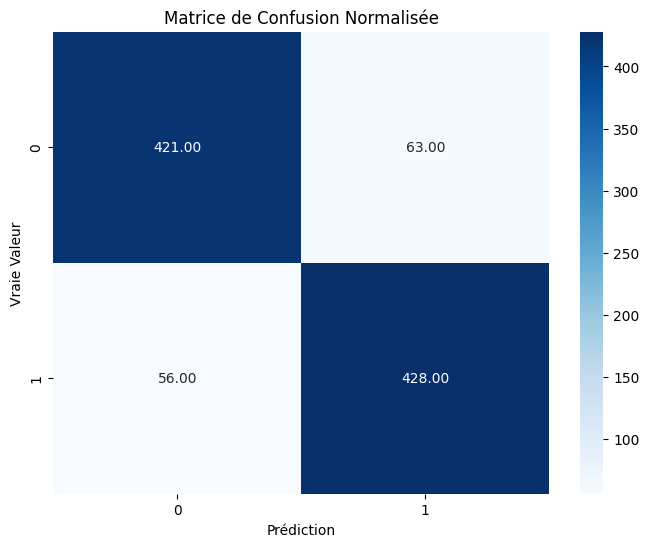

Epoch 1/10
122/122 [==============================] - 2s 4ms/step - loss: 0.6481 - accuracy: 0.6592
Epoch 2/10
122/122 [==============================] - 0s 4ms/step - loss: 0.5788 - accuracy: 0.7585
Epoch 3/10
122/122 [==============================] - 0s 3ms/step - loss: 0.5041 - accuracy: 0.7902
Epoch 4/10
122/122 [==============================] - 0s 3ms/step - loss: 0.4287 - accuracy: 0.8220
Epoch 5/10
122/122 [==============================] - 0s 3ms/step - loss: 0.3784 - accuracy: 0.8424
Epoch 6/10
122/122 [==============================] - 0s 3ms/step - loss: 0.3502 - accuracy: 0.8517
Epoch 7/10
122/122 [==============================] - 0s 3ms/step - loss: 0.3327 - accuracy: 0.8599
Epoch 8/10
122/122 [==============================] - 0s 3ms/step - loss: 0.3215 - accuracy: 0.8604
Epoch 9/10
122/122 [==============================] - 0s 3ms/step - loss: 0.3122 - accuracy: 0.8646
Epoch 10/10
31/31 [==============================] - 0s 3ms/step
Accuracy: 0.84
Precision: 0.90
Reca

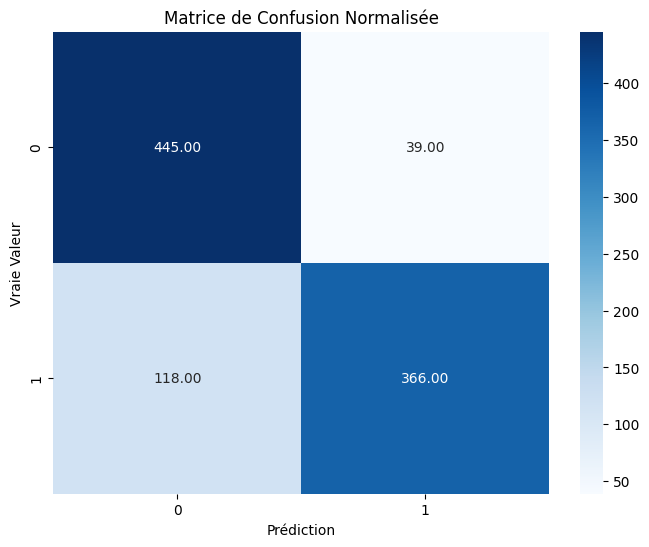

Epoch 1/10
122/122 [==============================] - 2s 3ms/step - loss: 0.6659 - accuracy: 0.6460
Epoch 2/10
122/122 [==============================] - 0s 3ms/step - loss: 0.6009 - accuracy: 0.7430
Epoch 3/10
122/122 [==============================] - 0s 3ms/step - loss: 0.5079 - accuracy: 0.7846
Epoch 4/10
122/122 [==============================] - 0s 4ms/step - loss: 0.4203 - accuracy: 0.8212
Epoch 5/10
122/122 [==============================] - 0s 4ms/step - loss: 0.3673 - accuracy: 0.8460
Epoch 6/10
122/122 [==============================] - 0s 4ms/step - loss: 0.3402 - accuracy: 0.8581
Epoch 7/10
122/122 [==============================] - 0s 4ms/step - loss: 0.3205 - accuracy: 0.8658
Epoch 8/10
122/122 [==============================] - 1s 6ms/step - loss: 0.3083 - accuracy: 0.8718
Epoch 9/10
122/122 [==============================] - 1s 6ms/step - loss: 0.2985 - accuracy: 0.8754
Epoch 10/10
31/31 [==============================] - 0s 6ms/step
Accuracy: 0.87
Precision: 0.86
Reca

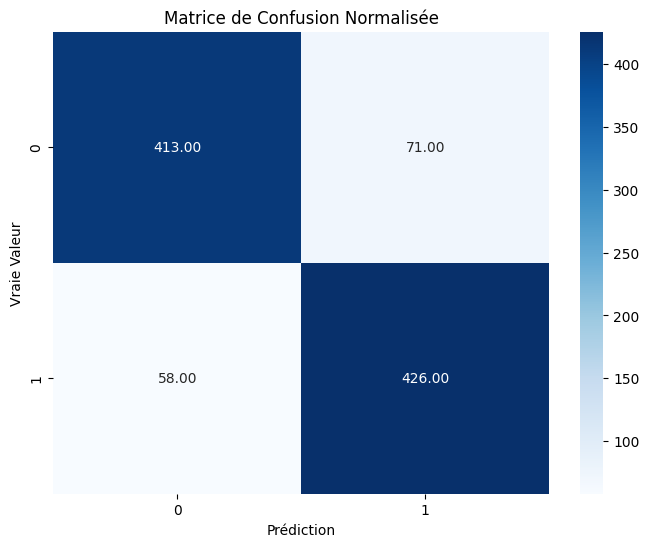

Epoch 1/10
122/122 [==============================] - 2s 5ms/step - loss: 0.6445 - accuracy: 0.6963
Epoch 2/10
122/122 [==============================] - 1s 4ms/step - loss: 0.5616 - accuracy: 0.7500
Epoch 3/10
122/122 [==============================] - 1s 6ms/step - loss: 0.4693 - accuracy: 0.7908
Epoch 4/10
122/122 [==============================] - 1s 7ms/step - loss: 0.3972 - accuracy: 0.8220
Epoch 5/10
122/122 [==============================] - 1s 7ms/step - loss: 0.3615 - accuracy: 0.8429
Epoch 6/10
122/122 [==============================] - 2s 18ms/step - loss: 0.3363 - accuracy: 0.8532
Epoch 7/10
122/122 [==============================] - 1s 12ms/step - loss: 0.3265 - accuracy: 0.8540
Epoch 8/10
122/122 [==============================] - 1s 9ms/step - loss: 0.3139 - accuracy: 0.8589
Epoch 9/10
122/122 [==============================] - 1s 9ms/step - loss: 0.3076 - accuracy: 0.8656
Epoch 10/10
31/31 [==============================] - 0s 3ms/step
Accuracy: 0.87
Precision: 0.88
Re

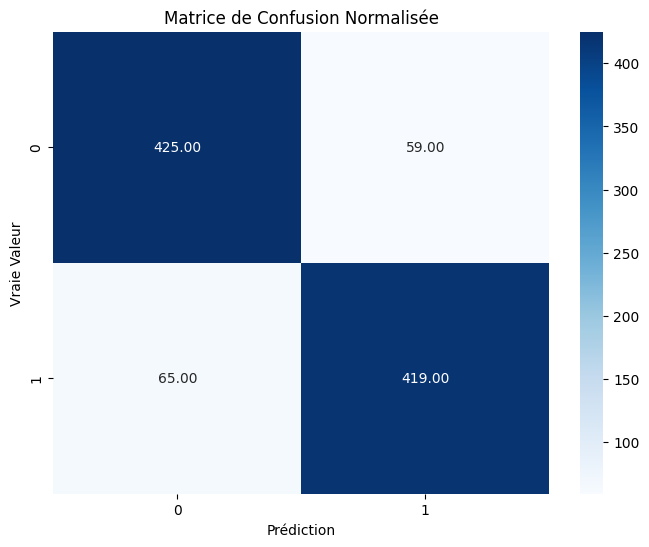

Epoch 1/10
122/122 [==============================] - 2s 3ms/step - loss: 0.6671 - accuracy: 0.6029
Epoch 2/10
122/122 [==============================] - 0s 3ms/step - loss: 0.5911 - accuracy: 0.7343
Epoch 3/10
122/122 [==============================] - 0s 3ms/step - loss: 0.4993 - accuracy: 0.7815
Epoch 4/10
122/122 [==============================] - 0s 3ms/step - loss: 0.4168 - accuracy: 0.8225
Epoch 5/10
122/122 [==============================] - 0s 4ms/step - loss: 0.3662 - accuracy: 0.8416
Epoch 6/10
122/122 [==============================] - 0s 4ms/step - loss: 0.3395 - accuracy: 0.8547
Epoch 7/10
122/122 [==============================] - 0s 4ms/step - loss: 0.3224 - accuracy: 0.8633
Epoch 8/10
122/122 [==============================] - 1s 6ms/step - loss: 0.3143 - accuracy: 0.8661
Epoch 9/10
122/122 [==============================] - 1s 6ms/step - loss: 0.3033 - accuracy: 0.8702
Epoch 10/10
31/31 [==============================] - 0s 2ms/step
Accuracy: 0.87
Precision: 0.85
Reca

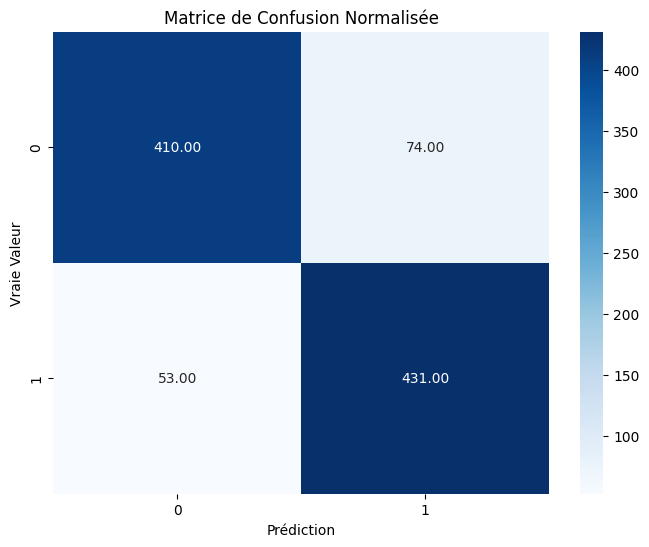

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)


      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}


      # Créer le modèle séquentiel
      model = Sequential([
                Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
                Dense(64, activation='relu'),
                Dense(64, activation='relu'),
                Dense(64, activation='relu'),
                Dense(64, activation='relu'),
                Dense(1, activation='sigmoid')
            ])

      # Compiler le modèle
      model.compile(optimizer='SGD',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])


# Entraîner le modèle
      history = model.fit(X_train, y_train, epochs=10)
      y_pred = (model.predict(X_val) > 0.5).astype("int32")


      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


Epoch 1/10
122/122 [==============================] - 3s 6ms/step - loss: 0.4048 - accuracy: 0.8111
Epoch 2/10
122/122 [==============================] - 1s 6ms/step - loss: 0.3016 - accuracy: 0.8658
Epoch 3/10
122/122 [==============================] - 1s 5ms/step - loss: 0.2815 - accuracy: 0.8798
Epoch 4/10
122/122 [==============================] - 1s 5ms/step - loss: 0.2569 - accuracy: 0.8867
Epoch 5/10
122/122 [==============================] - 1s 8ms/step - loss: 0.2450 - accuracy: 0.8916
Epoch 6/10
122/122 [==============================] - 1s 9ms/step - loss: 0.2386 - accuracy: 0.8973
Epoch 7/10
122/122 [==============================] - 1s 9ms/step - loss: 0.2157 - accuracy: 0.9079
Epoch 8/10
122/122 [==============================] - 1s 8ms/step - loss: 0.2161 - accuracy: 0.9035
Epoch 9/10
122/122 [==============================] - 1s 8ms/step - loss: 0.2037 - accuracy: 0.9146
Epoch 10/10
31/31 [==============================] - 0s 3ms/step
Accuracy: 0.86
Precision: 0.87
Reca

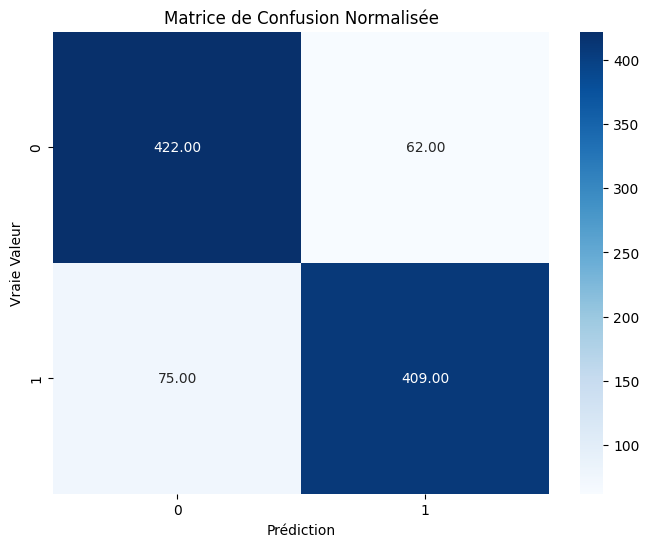

Epoch 1/10
122/122 [==============================] - 3s 7ms/step - loss: 0.4101 - accuracy: 0.8191
Epoch 2/10
122/122 [==============================] - 1s 9ms/step - loss: 0.3199 - accuracy: 0.8622
Epoch 3/10
122/122 [==============================] - 1s 11ms/step - loss: 0.2986 - accuracy: 0.8710
Epoch 4/10
122/122 [==============================] - 1s 8ms/step - loss: 0.2738 - accuracy: 0.8849
Epoch 5/10
122/122 [==============================] - 1s 8ms/step - loss: 0.2541 - accuracy: 0.8885
Epoch 6/10
122/122 [==============================] - 1s 8ms/step - loss: 0.2445 - accuracy: 0.8937
Epoch 7/10
122/122 [==============================] - 1s 8ms/step - loss: 0.2327 - accuracy: 0.8986
Epoch 8/10
122/122 [==============================] - 1s 10ms/step - loss: 0.2231 - accuracy: 0.9051
Epoch 9/10
122/122 [==============================] - 1s 6ms/step - loss: 0.2073 - accuracy: 0.9167
Epoch 10/10
31/31 [==============================] - 0s 3ms/step
Accuracy: 0.87
Precision: 0.85
Re

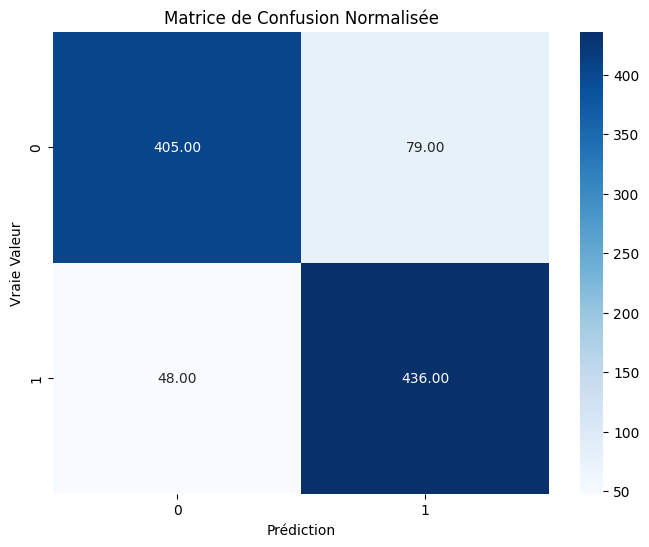

Epoch 1/10
122/122 [==============================] - 5s 9ms/step - loss: 0.4197 - accuracy: 0.8057
Epoch 2/10
122/122 [==============================] - 1s 7ms/step - loss: 0.3124 - accuracy: 0.8679
Epoch 3/10
122/122 [==============================] - 1s 5ms/step - loss: 0.2863 - accuracy: 0.8700
Epoch 4/10
122/122 [==============================] - 0s 4ms/step - loss: 0.2700 - accuracy: 0.8818
Epoch 5/10
122/122 [==============================] - 0s 3ms/step - loss: 0.2578 - accuracy: 0.8909
Epoch 6/10
122/122 [==============================] - 0s 4ms/step - loss: 0.2443 - accuracy: 0.8909
Epoch 7/10
122/122 [==============================] - 0s 4ms/step - loss: 0.2247 - accuracy: 0.9009
Epoch 8/10
122/122 [==============================] - 0s 4ms/step - loss: 0.2121 - accuracy: 0.9053
Epoch 9/10
122/122 [==============================] - 0s 4ms/step - loss: 0.2013 - accuracy: 0.9112
Epoch 10/10
31/31 [==============================] - 0s 2ms/step
Accuracy: 0.88
Precision: 0.89
Reca

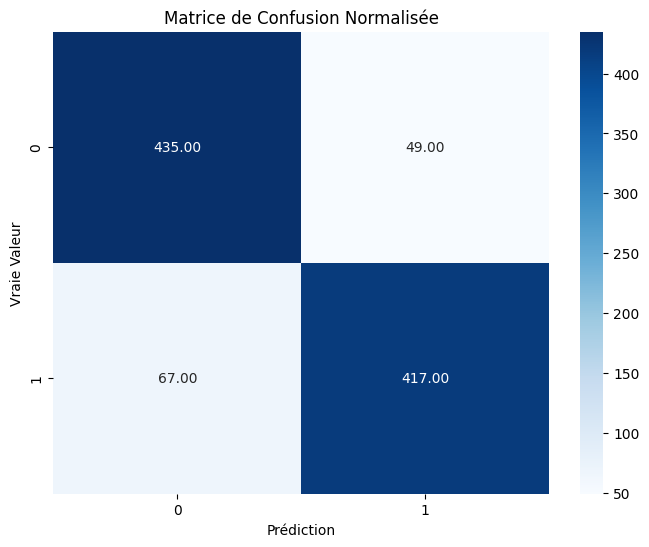

Epoch 1/10
122/122 [==============================] - 2s 4ms/step - loss: 0.4280 - accuracy: 0.8026
Epoch 2/10
122/122 [==============================] - 0s 4ms/step - loss: 0.3184 - accuracy: 0.8540
Epoch 3/10
122/122 [==============================] - 0s 3ms/step - loss: 0.2890 - accuracy: 0.8692
Epoch 4/10
122/122 [==============================] - 1s 5ms/step - loss: 0.2704 - accuracy: 0.8782
Epoch 5/10
122/122 [==============================] - 1s 7ms/step - loss: 0.2578 - accuracy: 0.8847
Epoch 6/10
122/122 [==============================] - 1s 9ms/step - loss: 0.2543 - accuracy: 0.8914
Epoch 7/10
122/122 [==============================] - 1s 9ms/step - loss: 0.2332 - accuracy: 0.9012
Epoch 8/10
122/122 [==============================] - 1s 10ms/step - loss: 0.2267 - accuracy: 0.9056
Epoch 9/10
122/122 [==============================] - 1s 6ms/step - loss: 0.2054 - accuracy: 0.9128
Epoch 10/10
31/31 [==============================] - 0s 3ms/step
Accuracy: 0.89
Precision: 0.87
Rec

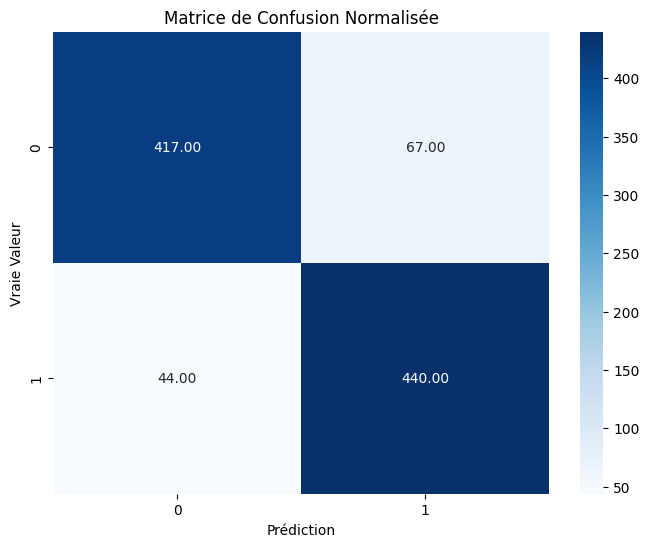

Epoch 1/10
122/122 [==============================] - 2s 3ms/step - loss: 0.4234 - accuracy: 0.8124
Epoch 2/10
122/122 [==============================] - 0s 3ms/step - loss: 0.3167 - accuracy: 0.8612
Epoch 3/10
122/122 [==============================] - 0s 3ms/step - loss: 0.2947 - accuracy: 0.8720
Epoch 4/10
122/122 [==============================] - 0s 3ms/step - loss: 0.2740 - accuracy: 0.8824
Epoch 5/10
122/122 [==============================] - 0s 3ms/step - loss: 0.2493 - accuracy: 0.8955
Epoch 6/10
122/122 [==============================] - 0s 3ms/step - loss: 0.2423 - accuracy: 0.8994
Epoch 7/10
122/122 [==============================] - 1s 5ms/step - loss: 0.2361 - accuracy: 0.9048
Epoch 8/10
122/122 [==============================] - 1s 5ms/step - loss: 0.2157 - accuracy: 0.9133
Epoch 9/10
122/122 [==============================] - 1s 6ms/step - loss: 0.2027 - accuracy: 0.9182
Epoch 10/10
31/31 [==============================] - 0s 3ms/step
Accuracy: 0.89
Precision: 0.86
Reca

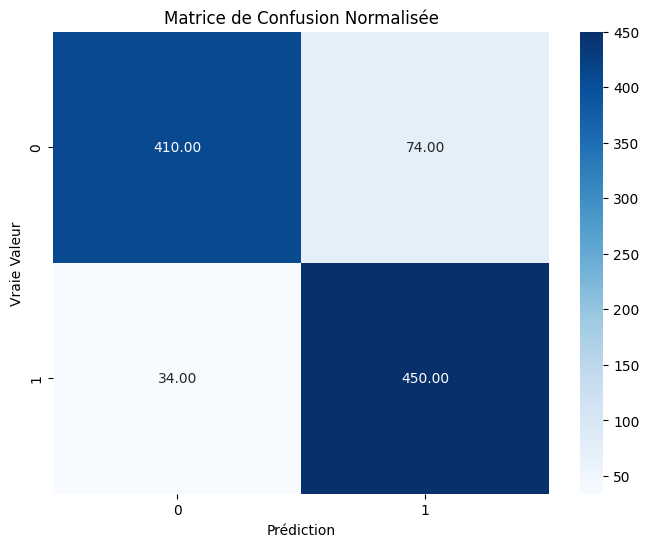

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)


      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}


      # Créer le modèle séquentiel
      model = Sequential([
                Dense(192, activation='relu', input_shape=(X_train.shape[1],)),
                Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
                Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
                Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
                Dense(64, activation='relu'),
                Dense(64, activation='relu'),
                Dense(64, activation='relu'),
                Dense(32, activation='relu'),
                Dense(1, activation='sigmoid')
            ])

      # Compiler le modèle
      model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])


# Entraîner le modèle
      history = model.fit(X_train, y_train, epochs=10)
      y_pred = (model.predict(X_val) > 0.5).astype("int32")


      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


Accuracy: 0.85
Precision: 0.83
Recall: 0.87
F1 Score: 0.85
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       478
           1       0.83      0.87      0.85       478

    accuracy                           0.85       956
   macro avg       0.85      0.85      0.85       956
weighted avg       0.85      0.85      0.85       956



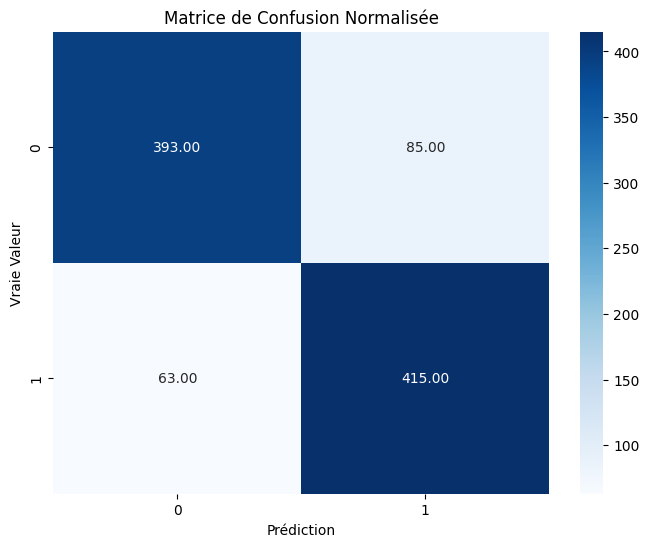

Accuracy: 0.84
Precision: 0.84
Recall: 0.85
F1 Score: 0.84
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       478
           1       0.84      0.85      0.84       478

    accuracy                           0.84       956
   macro avg       0.84      0.84      0.84       956
weighted avg       0.84      0.84      0.84       956



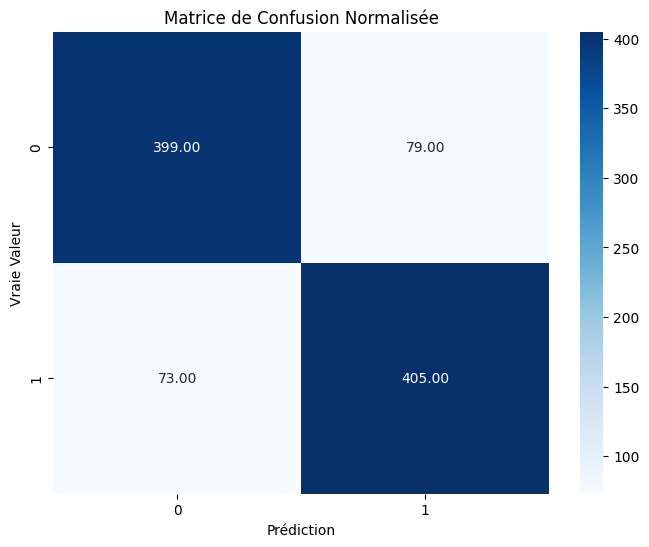

Accuracy: 0.82
Precision: 0.80
Recall: 0.85
F1 Score: 0.82
              precision    recall  f1-score   support

           0       0.84      0.79      0.82       478
           1       0.80      0.85      0.82       478

    accuracy                           0.82       956
   macro avg       0.82      0.82      0.82       956
weighted avg       0.82      0.82      0.82       956



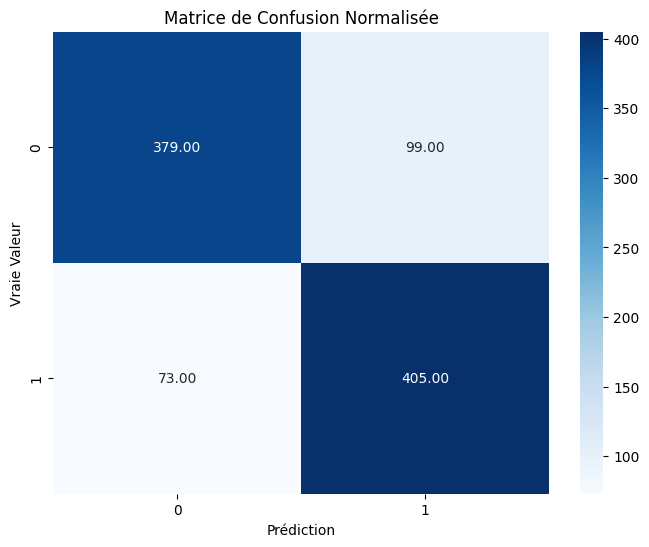

Accuracy: 0.82
Precision: 0.80
Recall: 0.86
F1 Score: 0.83
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       478
           1       0.80      0.86      0.83       478

    accuracy                           0.82       956
   macro avg       0.83      0.82      0.82       956
weighted avg       0.83      0.82      0.82       956



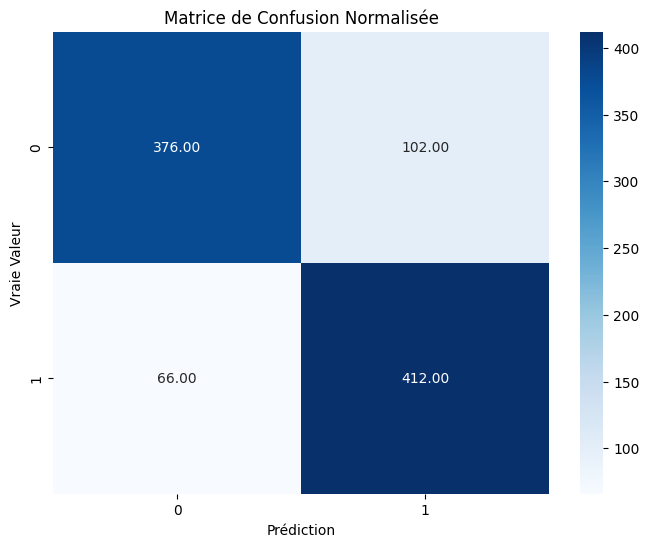

Accuracy: 0.82
Precision: 0.80
Recall: 0.87
F1 Score: 0.83
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       478
           1       0.80      0.87      0.83       478

    accuracy                           0.82       956
   macro avg       0.83      0.82      0.82       956
weighted avg       0.83      0.82      0.82       956



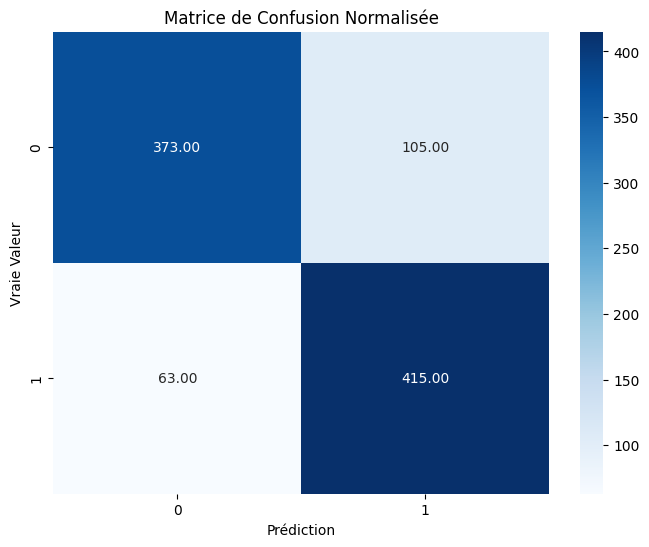

Modèle sélectionné avec un rappel proche de la moyenne des rappels.
Accuracy: 0.78
Precision: 0.75
Recall: 0.83
F1 Score: 0.79
              precision    recall  f1-score   support

           0       0.81      0.72      0.76       653
           1       0.75      0.83      0.79       653

    accuracy                           0.78      1306
   macro avg       0.78      0.78      0.78      1306
weighted avg       0.78      0.78      0.78      1306



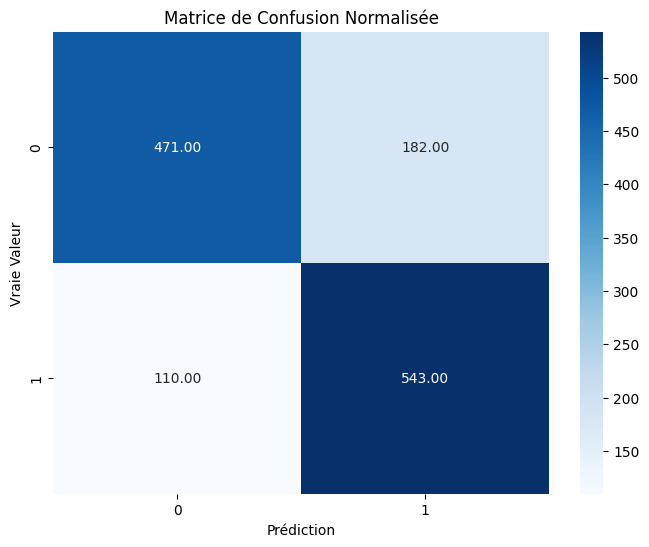

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.svm import SVC

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)
      svm_model = SVC(kernel='rbf',C=100,tol=1e-5,random_state=42)
      svm_model.fit(X_train, y_train)
      models.append(svm_model)
      y_pred = svm_model.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      recalls.append(recall)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()
mean_recall = np.mean(recalls)

# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = None
closest_recall_diff = float('inf')  # Initialisation avec une valeur infinie
for model, recall in zip(models, recalls):
    recall_diff = abs(recall - mean_recall)
    if recall_diff < closest_recall_diff:
        closest_model = model
        closest_recall_diff = recall_diff

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()

Accuracy: 0.69
Precision: 0.69
Recall: 0.69
F1 Score: 0.69
              precision    recall  f1-score   support

           0       0.69      0.69      0.69       484
           1       0.69      0.69      0.69       484

    accuracy                           0.69       968
   macro avg       0.69      0.69      0.69       968
weighted avg       0.69      0.69      0.69       968



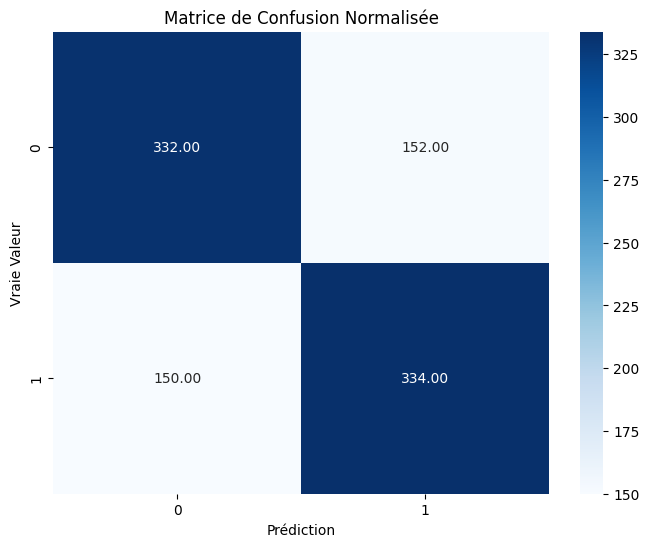

Accuracy: 0.69
Precision: 0.69
Recall: 0.69
F1 Score: 0.69
              precision    recall  f1-score   support

           0       0.69      0.69      0.69       484
           1       0.69      0.69      0.69       484

    accuracy                           0.69       968
   macro avg       0.69      0.69      0.69       968
weighted avg       0.69      0.69      0.69       968



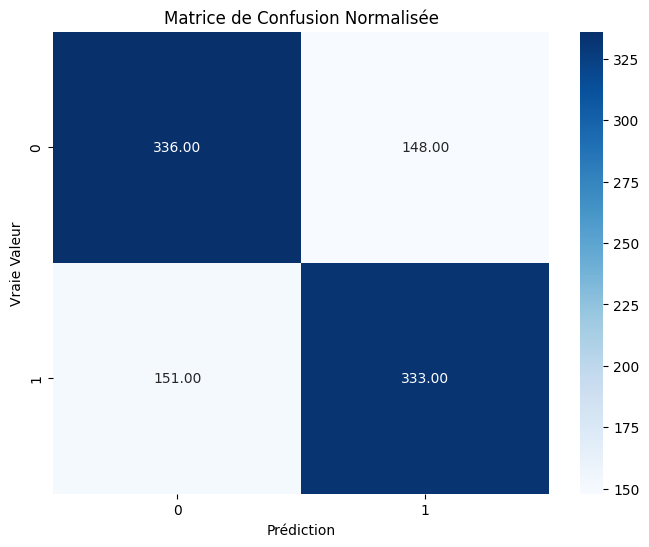

Accuracy: 0.71
Precision: 0.71
Recall: 0.69
F1 Score: 0.70
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       484
           1       0.71      0.69      0.70       484

    accuracy                           0.71       968
   macro avg       0.71      0.71      0.71       968
weighted avg       0.71      0.71      0.71       968



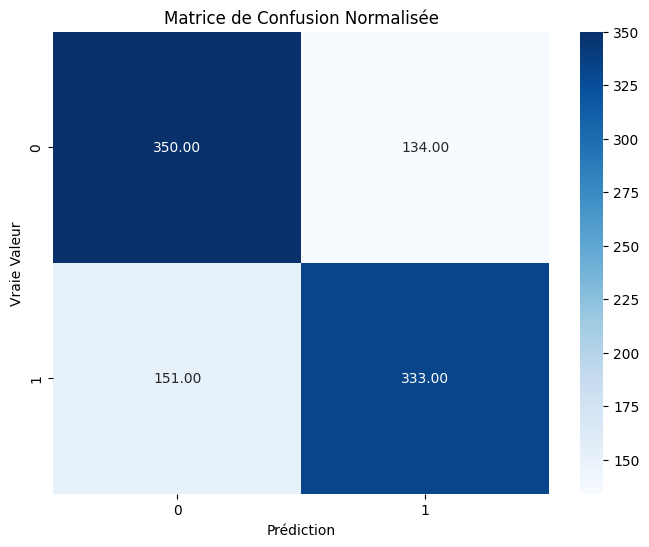

Accuracy: 0.68
Precision: 0.68
Recall: 0.69
F1 Score: 0.69
              precision    recall  f1-score   support

           0       0.69      0.68      0.68       484
           1       0.68      0.69      0.69       484

    accuracy                           0.68       968
   macro avg       0.68      0.68      0.68       968
weighted avg       0.68      0.68      0.68       968



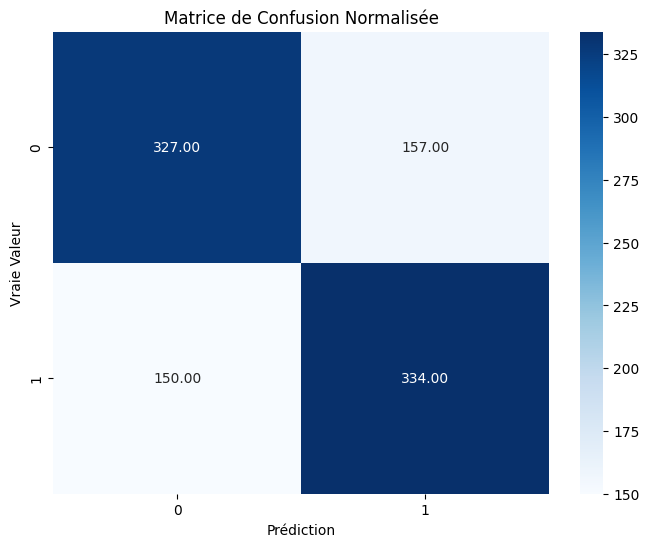

Accuracy: 0.72
Precision: 0.72
Recall: 0.72
F1 Score: 0.72
              precision    recall  f1-score   support

           0       0.72      0.72      0.72       484
           1       0.72      0.72      0.72       484

    accuracy                           0.72       968
   macro avg       0.72      0.72      0.72       968
weighted avg       0.72      0.72      0.72       968



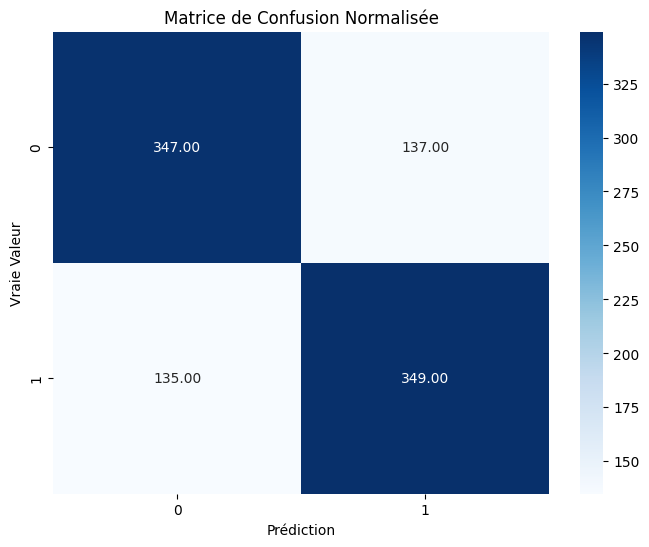

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.svm import SVC

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)
      svm_model = SVC(kernel='sigmoid',C=1,random_state=42)
      svm_model.fit(X_train, y_train)
      y_pred = svm_model.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()

Accuracy: 0.69
Precision: 0.69
Recall: 0.69
F1 Score: 0.69
              precision    recall  f1-score   support

           0       0.69      0.68      0.69       484
           1       0.69      0.69      0.69       484

    accuracy                           0.69       968
   macro avg       0.69      0.69      0.69       968
weighted avg       0.69      0.69      0.69       968



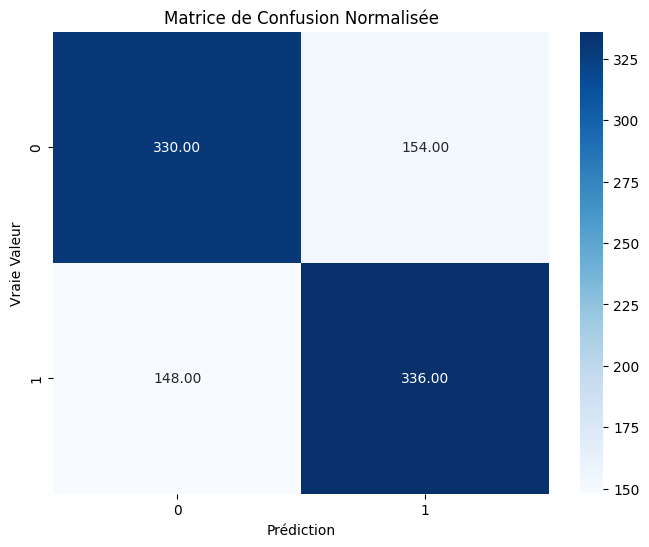

Accuracy: 0.69
Precision: 0.69
Recall: 0.69
F1 Score: 0.69
              precision    recall  f1-score   support

           0       0.69      0.69      0.69       484
           1       0.69      0.69      0.69       484

    accuracy                           0.69       968
   macro avg       0.69      0.69      0.69       968
weighted avg       0.69      0.69      0.69       968



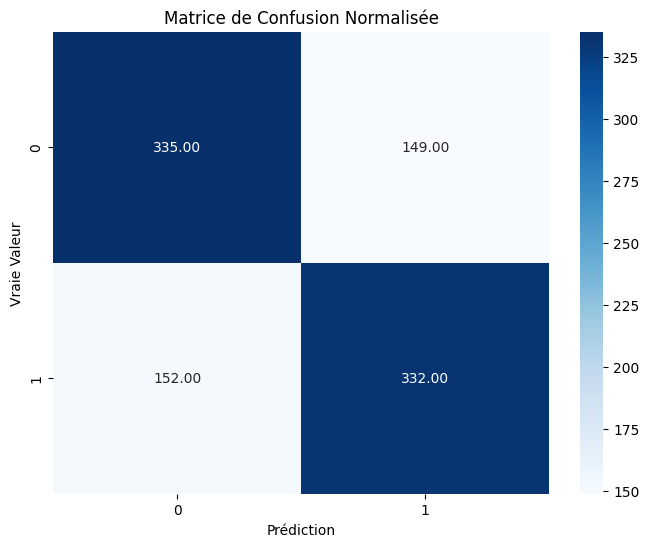

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.svm import SVC

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)
      svm_model = SVC(kernel='sigmoid',C=100,random_state=42,max_iter=1000)
      svm_model.fit(X_train, y_train)
      y_pred = svm_model.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()

In [ ]:
X = trainset.drop(columns=['fire'])
y = trainset['fire']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']

In [ ]:
from sklearn.preprocessing import StandardScaler

# Créer un objet StandardScaler
scaler = StandardScaler()

# Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
X_train = scaler.fit_transform(X_train)
# Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
X_val = scaler.fit_transform(X_val)
X_test = scaler.transform(X_test)

<ipython-input-15-72efbff6b5b0>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class',data=pd.DataFrame({'Class': y_train}), palette='viridis')
<ipython-input-15-72efbff6b5b0>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class',data=pd.DataFrame({'Class': y_train_nearmiss}), palette='viridis')


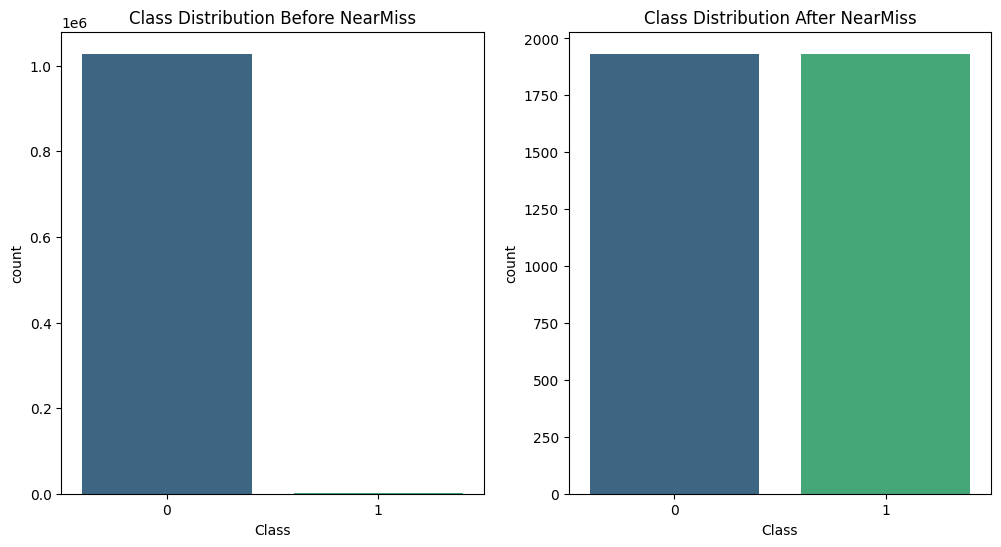

In [ ]:
from imblearn.under_sampling import NearMiss
# Apply NearMiss to the training data
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
nearmiss = NearMiss()
X_train_nearmiss, y_train_nearmiss = nearmiss.fit_resample (X_train, y_train)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.countplot(x='Class',data=pd.DataFrame({'Class': y_train}), palette='viridis')
plt.title('Class Distribution Before NearMiss')
plt.subplot(1, 2, 2)
sns.countplot(x='Class',data=pd.DataFrame({'Class': y_train_nearmiss}), palette='viridis')
plt.title('Class Distribution After NearMiss')
plt.show()

In [ ]:
from imblearn.under_sampling import NearMiss
# Apply NearMiss to the training data
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)
nearmiss = NearMiss()
X_train_nearmiss, y_train_nearmiss = nearmiss.fit_resample (X_train, y_train)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.countplot(x='Class',data=pd.DataFrame({'Class': y_train}), palette='viridis')
plt.title('Class Distribution Before NearMiss')
plt.subplot(1, 2, 2)
sns.countplot(x='Class',data=pd.DataFrame({'Class': y_train_nearmiss}), palette='viridis')
plt.title('Class Distribution After NearMiss')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mode
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


y_test_combined_list = []
predictions = []
random_wafaa_models= []
# Nombre de tuples à inclure dans chaque ensemble
fire_indices = np.where(trainset['fire'] == 1)[0]
fire_samples = len(fire_indices)
print(fire_samples)

#np.where(y_train == 1)[0]

# Liste pour stocker les 100 ensembles de données
data_sets = []

for i in range(150):

    # Sélectionner aléatoirement count_per_set tuples de la classe 0
    class_1_subset = trainset.iloc[fire_indices]
    class_0_subset = trainset[trainset['fire'] == 0].sample(n=fire_samples*2)


    # Concaténer les deux sous-ensembles
    subset = pd.concat([class_0_subset, class_1_subset])

    # Ajouter le sous-ensemble à la liste des ensembles de données
    data_sets.append(subset)

i=0

for dataset in data_sets:

    print("*******************************************")
    i=i+1
    print("tree:",i)
    # Séparation des caractéristiques et des étiquettes
    X = dataset.drop('fire', axis=1)  # Supprimez la colonne 'fire' pour obtenir les caractéristiques
    y = dataset['fire']  # Obtenez les étiquettes 'fire'

    # Diviser les données en ensemble de formation (train) et ensemble de test (test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()

    # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
    X_train = scaler.fit_transform(X_train)
    # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
    X_test = scaler.transform(X_test)

    # Création du modèle d'arbre de décision
    rf_classifier = DecisionTreeClassifier()
    rf_classifier.fit(X_train, y_train)

    # Prédiction sur l'ensemble de test
    y_pred_rf = rf_classifier.predict(X_test)

    y_test_combined_list.append(y_test)

    # Ajout des prédictions à la liste
    predictions.append(y_pred_rf)

    random_wafaa_models.append(rf_classifier)

    # Évaluation des performances du modèle
    accuracy = accuracy_score(y_test, y_pred_rf)
    print(f'Accuracy: {accuracy:.2f}')

    # Affichage du rapport de classification
    print(classification_report(y_test, y_pred_rf))

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred_rf)
    cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie Valeur')
    plt.title('Matrice de Confusion Normalisée')
    plt.show()

# Convertir les prédictions en un tableau numpy
predictions_array = np.array(predictions)

# Calculer le mode (vote majoritaire) pour chaque tuple de données
ensemble_predictions = mode(predictions_array, axis=0)[0]

print(ensemble_predictions.shape)
print("*********************************************")
# Boucle pour évaluer chaque ensemble de test combiné sauvegardé
for y_test_combined_saved in y_test_combined_list:
    accuracy = accuracy_score(y_test_combined_saved, ensemble_predictions)
    print(f'Accuracy: {accuracy:.2f}')

    # Affichage du rapport de classification
    print(classification_report(y_test_combined_saved, ensemble_predictions))

    # Matrice de confusion
    cm = confusion_matrix(y_test_combined_saved, ensemble_predictions)
    cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie Valeur')
    plt.title('Matrice de Confusion Normalisée')
    plt.show()





In [ ]:
y_test_combined_list=[]
predictions = []
for model in random_wafaa_models:

    # Séparation des caractéristiques et des étiquettes
    X_test = testset.drop('fire', axis=1)  # Supprimez la colonne 'fire' pour obtenir les caractéristiques
    y_test = testset['fire']  # Obtenez les étiquettes 'fire'
    X_test = scaler.transform(X_test)

    y_pred_rf = model.predict(X_test)

    y_test_combined_list.append(y_test)

    # Ajout des prédictions à la liste
    predictions.append(y_pred_rf)

    # Évaluation des performances du modèle
    accuracy = accuracy_score(y_test, y_pred_rf)
    print(f'Accuracy: {accuracy:.2f}')

    # Affichage du rapport de classification
    print(classification_report(y_test, y_pred_rf))

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred_rf)
    cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie Valeur')
    plt.title('Matrice de Confusion Normalisée')
    plt.show()

# Convertir les prédictions en un tableau numpy
predictions_array = np.array(predictions)

# Calculer le mode (vote majoritaire) pour chaque tuple de données
ensemble_predictions = mode(predictions_array, axis=0)[0]

print(ensemble_predictions.shape)
print("*********************************************")
# Boucle pour évaluer chaque ensemble de test combiné sauvegardé
for y_test_combined_saved in y_test_combined_list:
    accuracy = accuracy_score(y_test_combined_saved, ensemble_predictions)
    print(f'Accuracy: {accuracy:.2f}')

    # Affichage du rapport de classification
    print(classification_report(y_test_combined_saved, ensemble_predictions))

    # Matrice de confusion
    cm = confusion_matrix(y_test_combined_saved, ensemble_predictions)
    cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie Valeur')
    plt.title('Matrice de Confusion Normalisée')
    plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mode
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


y_test_combined_list = []
predictions = []
random_wafaa_models= []
ensemble_predictions = []
# Nombre de tuples à inclure dans chaque ensemble
fire_indices = np.where(trainset['fire'] == 1)[0]
fire_samples = len(fire_indices)
print(fire_samples)

#np.where(y_train == 1)[0]

# Liste pour stocker les 100 ensembles de données
data_sets = []

for i in range(150):

    # Sélectionner aléatoirement count_per_set tuples de la classe 0
    class_1_subset = trainset.iloc[fire_indices]
    class_0_subset = trainset[trainset['fire'] == 0].sample(n=fire_samples*2)


    # Concaténer les deux sous-ensembles
    subset = pd.concat([class_0_subset, class_1_subset])

    # Ajouter le sous-ensemble à la liste des ensembles de données
    data_sets.append(subset)

i=0

for dataset in data_sets:

    print("*******************************************")
    i=i+1
    print("tree:",i)
    # Séparation des caractéristiques et des étiquettes
    X = dataset.drop('fire', axis=1)  # Supprimez la colonne 'fire' pour obtenir les caractéristiques
    y = dataset['fire']  # Obtenez les étiquettes 'fire'

    # Diviser les données en ensemble de formation (train) et ensemble de test (test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()

    # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
    X_train = scaler.fit_transform(X_train)
    # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
    X_test = scaler.transform(X_test)

    # Création du modèle d'arbre de décision
    rf_classifier = DecisionTreeClassifier()
    rf_classifier.fit(X_train, y_train)

    # Prédiction sur l'ensemble de test
    y_pred_rf = rf_classifier.predict(X_test)

    y_test_combined_list.append(y_test)

    # Ajout des prédictions à la liste
    predictions.append(y_pred_rf)

    random_wafaa_models.append(rf_classifier)

# Convertir les prédictions en un tableau numpy

for index in range(len(predictions)):
    # Initialisez la somme des prédictions pour cet indice
    sum_predictions = 0

    # Pour chaque modèle, ajoutez sa prédiction à la somme
    for i in range(len(predictions[index])):
        sum_predictions += predictions[index][i]

    # Divisez la somme par le nombre de modèles pour obtenir la prédiction finale pour cet indice
    final_prediction = sum_predictions / len(predictions)

    # Ajoutez la prédiction finale à votre liste de prédictions finales
    ensemble_predictions = np.append(ensemble_predictions, final_prediction)

seuil_decision = 0.5
classes_predictions_finales = []

for prediction in ensemble_predictions:
    classe_prediction = 1 if prediction >= seuil_decision else 0
    classes_predictions_finales.append(classe_prediction)

print(ensemble_predictions.shape)
print("*********************************************")
# Boucle pour évaluer chaque ensemble de test combiné sauvegardé
for y_test_combined_saved in y_test_combined_list:
    accuracy = accuracy_score(y_test_combined_saved, ensemble_predictions)
    print(f'Accuracy: {accuracy:.2f}')

    # Affichage du rapport de classification
    print(classification_report(y_test_combined_saved, ensemble_predictions))

    # Matrice de confusion
    cm = confusion_matrix(y_test_combined_saved, ensemble_predictions)
    cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie Valeur')
    plt.title('Matrice de Confusion Normalisée')
    plt.show()





2468
*******************************************
tree: 1
*******************************************
tree: 2
*******************************************
tree: 3
*******************************************
tree: 4
*******************************************
tree: 5
*******************************************
tree: 6
*******************************************
tree: 7
*******************************************
tree: 8
*******************************************
tree: 9
*******************************************
tree: 10
*******************************************
tree: 11
*******************************************
tree: 12
*******************************************
tree: 13
*******************************************
tree: 14
*******************************************
tree: 15
*******************************************
tree: 16
*******************************************
tree: 17
*******************************************
tree: 18
*******************************************
tree: 

In [ ]:
y_test_combined_list=[]
predictions = []
for model in random_wafaa_models:

    # Séparation des caractéristiques et des étiquettes
    X_test = testset.drop('fire', axis=1)  # Supprimez la colonne 'fire' pour obtenir les caractéristiques
    y_test = testset['fire']  # Obtenez les étiquettes 'fire'
    X_test = scaler.transform(X_test)

    y_pred_rf = model.predict(X_test)

    y_test_combined_list.append(y_test)

    # Ajout des prédictions à la liste
    predictions.append(y_pred_rf)

    # Évaluation des performances du modèle
    accuracy = accuracy_score(y_test, y_pred_rf)
    print(f'Accuracy: {accuracy:.2f}')

    # Affichage du rapport de classification
    print(classification_report(y_test, y_pred_rf))

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred_rf)
    cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie Valeur')
    plt.title('Matrice de Confusion Normalisée')
    plt.show()

for index in range(len(predictions)):
    # Initialisez la somme des prédictions pour cet indice
    sum_predictions = 0

    # Pour chaque modèle, ajoutez sa prédiction à la somme
    for i in range(len(predictions[index])):
        sum_predictions += predictions[index][i]

    # Divisez la somme par le nombre de modèles pour obtenir la prédiction finale pour cet indice
    final_prediction = sum_predictions / len(predictions)

    # Ajoutez la prédiction finale à votre liste de prédictions finales
    ensemble_predictions.append(final_prediction)

seuil_decision = 0.5
classes_predictions_finales = []

for prediction in ensemble_predictions:
    classe_prediction = 1 if prediction >= seuil_decision else 0
    classes_predictions_finales.append(classe_prediction)

print(ensemble_predictions.shape)
print("*********************************************")
# Boucle pour évaluer chaque ensemble de test combiné sauvegardé
for y_test_combined_saved in y_test_combined_list:
    accuracy = accuracy_score(y_test_combined_saved, ensemble_predictions)
    print(f'Accuracy: {accuracy:.2f}')

    # Affichage du rapport de classification
    print(classification_report(y_test_combined_saved, ensemble_predictions))

    # Matrice de confusion
    cm = confusion_matrix(y_test_combined_saved, ensemble_predictions)
    cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie Valeur')
    plt.title('Matrice de Confusion Normalisée')
    plt.show()


training data augmente:

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto')
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
X_train=X_resampled
y_train=y_resampled

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto')
X_resampled, y_resampled = smote.fit_resample(X_val, y_val)

In [ ]:
X_val=X_resampled
y_val=y_resampled

Accuracy: 1.00
Precision: 0.23
Recall: 0.19
F1 Score: 0.21
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257076
           1       0.23      0.19      0.21       462

    accuracy                           1.00    257538
   macro avg       0.62      0.59      0.60    257538
weighted avg       1.00      1.00      1.00    257538



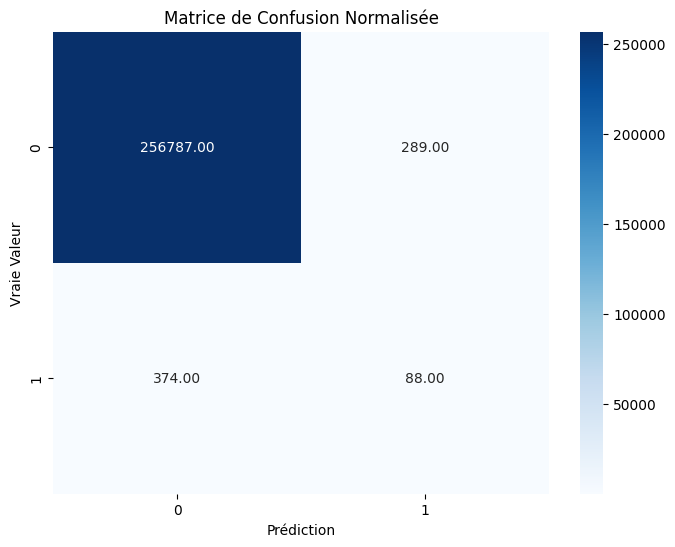

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier



# Création et entraînement du modèle SVM avec poids de classe personnalisés
#class_weight={0:1,1:99}
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)

# Prédiction sur l'ensemble de test
y_pred = decision_tree.predict(X_val)

# Évaluation du modèle
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)


print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_val, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_val, y_pred)
#cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()


In [ ]:
X.columns

Index(['Unnamed: 0', 'GRIDCODE', 'AREA', 'LCCCODE', 'sand % topsoil',
       'silt % topsoil', 'clay % topsoil', 'pH water topsoil', 'OC % topsoil',
       'N % topsoil', 'BS % topsoil', 'CEC topsoil', 'CEC clay topsoil',
       'CaCO3 % topsoil', 'BD topsoil', 'C/N topsoil', 'population', '_mean',
       '_min', '_max', '_variance', 'MAX_TEMPERATURE_C', 'MIN_TEMPERATURE_C',
       'WINDSPEED_MAX_KMH', 'HUMIDITY_MAX_PERCENT', 'PRESSURE_MAX_MB',
       'HEATINDEX_MAX_C', 'DEWPOINT_MAX_C', 'WINDTEMP_MAX_C', 'TOTAL_SNOW_MM',
       'UV_INDEX', 'TEMPERATURE_JOURNEE', 'TEMPERATURE_NIGHT', 'Data_x',
       'Data_y', 'Data', 'Datad', 'Month', 'Day'],
      dtype='object')

In [ ]:
import joblib
joblib.dump(decision_tree, f'/content/DTmodelee.pkl')

['/content/DTmodelee.pkl']

In [ ]:
import sklearn
print(sklearn.__version__)


1.4.2


In [ ]:
pip install scikit-learn==1.4.2


Accuracy: 0.90
Precision: 1.00
Recall: 0.80
F1 Score: 0.89
              precision    recall  f1-score   support

           0       0.83      1.00      0.91    407365
           1       1.00      0.80      0.89    407365

    accuracy                           0.90    814730
   macro avg       0.91      0.90      0.90    814730
weighted avg       0.91      0.90      0.90    814730



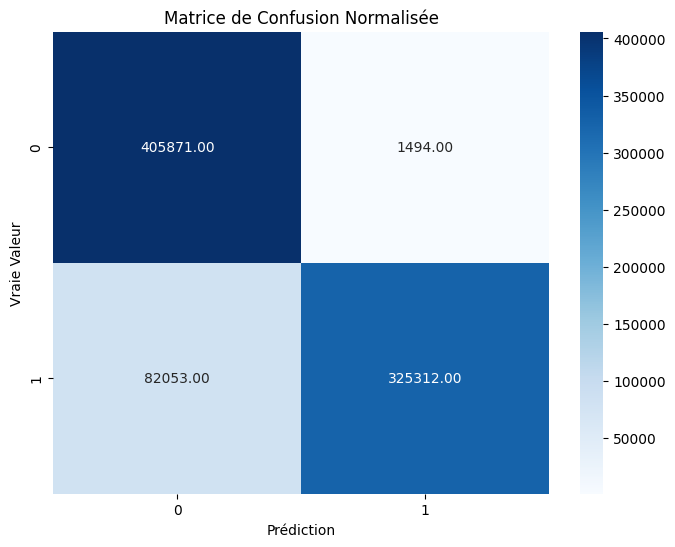

Accuracy: 0.92
Precision: 1.00
Recall: 0.84
F1 Score: 0.91
              precision    recall  f1-score   support

           0       0.86      1.00      0.93    407365
           1       1.00      0.84      0.91    407365

    accuracy                           0.92    814730
   macro avg       0.93      0.92      0.92    814730
weighted avg       0.93      0.92      0.92    814730



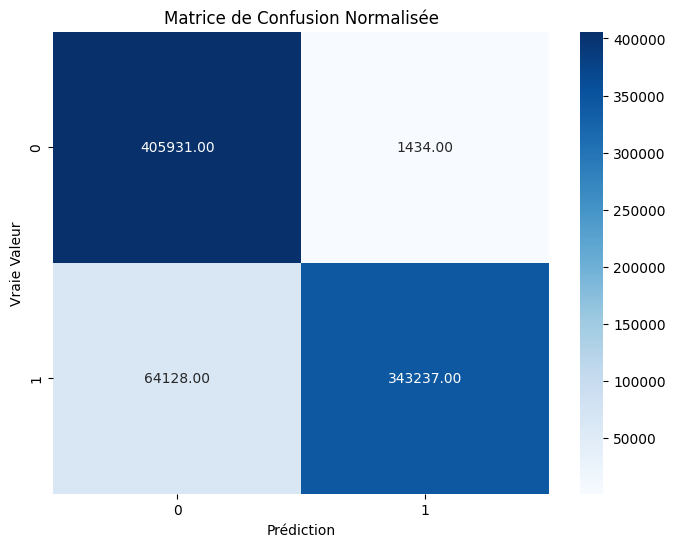

Accuracy: 0.91
Precision: 1.00
Recall: 0.82
F1 Score: 0.90
              precision    recall  f1-score   support

           0       0.85      1.00      0.92    407365
           1       1.00      0.82      0.90    407365

    accuracy                           0.91    814730
   macro avg       0.92      0.91      0.91    814730
weighted avg       0.92      0.91      0.91    814730



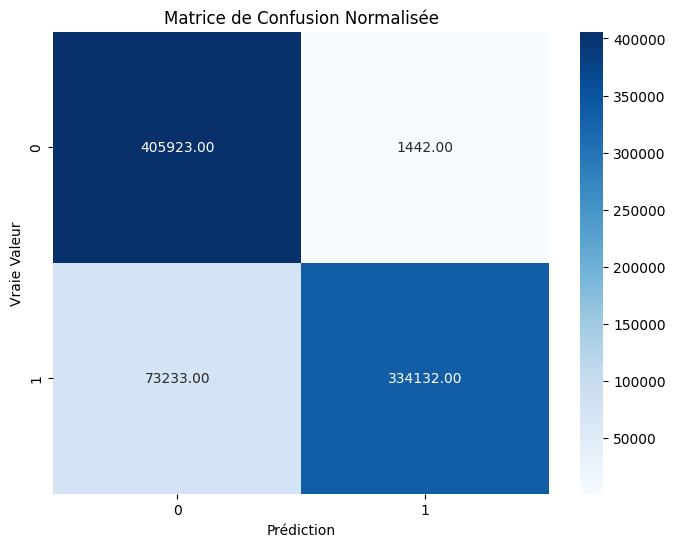

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      smote = SMOTE(sampling_strategy='auto')
      X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
      X_train=X_resampled
      y_train=y_resampled

      smote = SMOTE(sampling_strategy='auto')
      X_resampled, y_resampled = smote.fit_resample(X_val, y_val)
      X_val=X_resampled
      y_val=y_resampled

      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      random_forest = RandomForestClassifier(n_estimators=150)
      random_forest.fit(X_train, y_train)

      # Prédiction sur l'ensemble de test
      y_pred = random_forest.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier,RandomForestClassifier

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      smote = SMOTE(sampling_strategy='auto')
      X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
      X_train=X_resampled
      y_train=y_resampled

      smote = SMOTE(sampling_strategy='auto')
      X_resampled, y_resampled = smote.fit_resample(X_val, y_val)
      X_val=X_resampled
      y_val=y_resampled

      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      random_forest = AdaBoostClassifier(DecisionTreeClassifier(max_depth=10),n_estimators=100,random_state=42)
      random_forest.fit(X_train, y_train)

      # Prédiction sur l'ensemble de test
      y_pred = random_forest.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


Accuracy: 0.88
Precision: 0.87
Recall: 0.90
F1 Score: 0.89
              precision    recall  f1-score   support

           0       0.90      0.87      0.88    257054
           1       0.87      0.90      0.89    257054

    accuracy                           0.88    514108
   macro avg       0.88      0.88      0.88    514108
weighted avg       0.88      0.88      0.88    514108



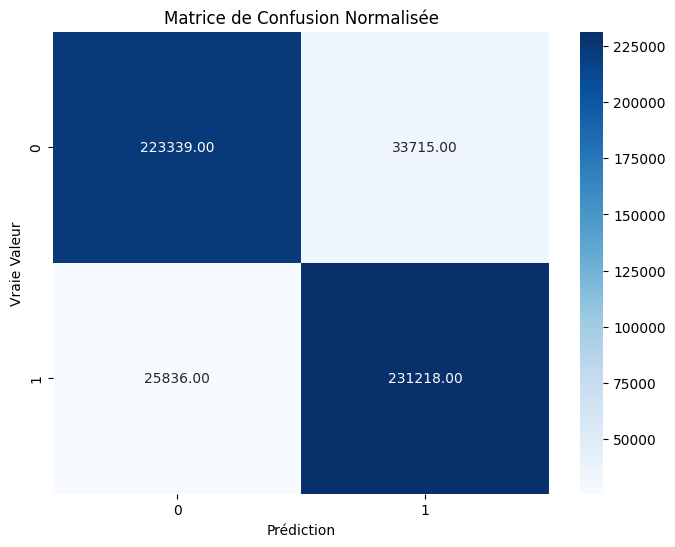

Accuracy: 0.88
Precision: 0.87
Recall: 0.89
F1 Score: 0.88
              precision    recall  f1-score   support

           0       0.89      0.87      0.88    257054
           1       0.87      0.89      0.88    257054

    accuracy                           0.88    514108
   macro avg       0.88      0.88      0.88    514108
weighted avg       0.88      0.88      0.88    514108



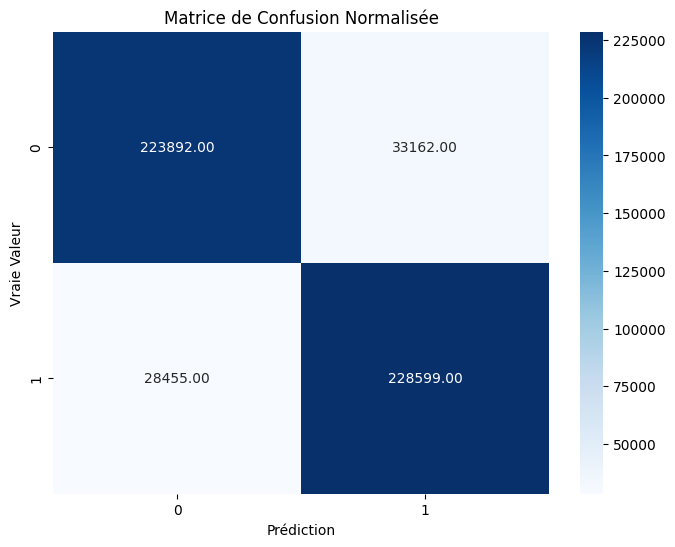

Accuracy: 0.89
Precision: 0.87
Recall: 0.91
F1 Score: 0.89
              precision    recall  f1-score   support

           0       0.91      0.87      0.89    257054
           1       0.87      0.91      0.89    257054

    accuracy                           0.89    514108
   macro avg       0.89      0.89      0.89    514108
weighted avg       0.89      0.89      0.89    514108



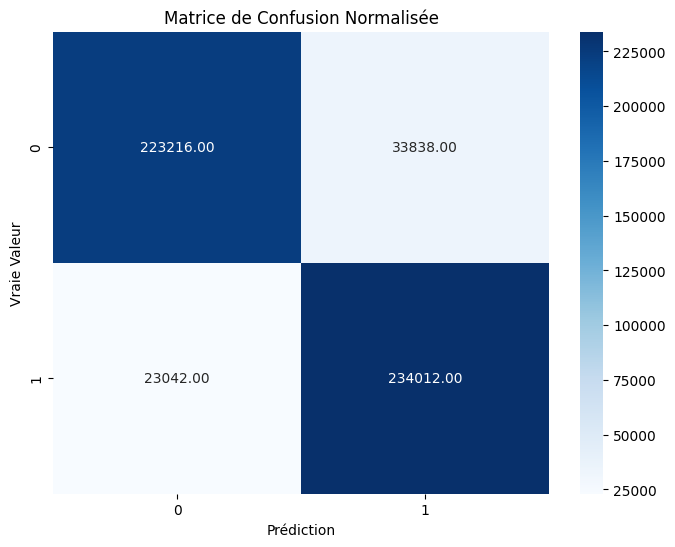

Accuracy: 0.89
Precision: 0.87
Recall: 0.90
F1 Score: 0.89
              precision    recall  f1-score   support

           0       0.90      0.87      0.89    257054
           1       0.87      0.90      0.89    257054

    accuracy                           0.89    514108
   macro avg       0.89      0.89      0.89    514108
weighted avg       0.89      0.89      0.89    514108



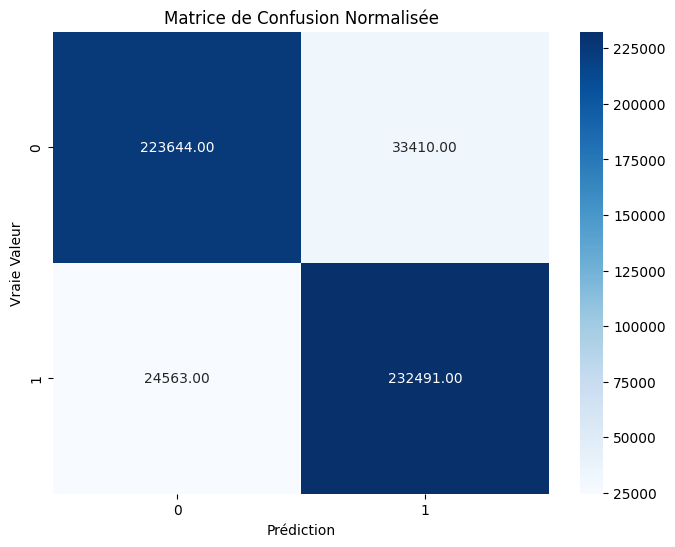

Accuracy: 0.89
Precision: 0.87
Recall: 0.90
F1 Score: 0.89
              precision    recall  f1-score   support

           0       0.90      0.87      0.88    257054
           1       0.87      0.90      0.89    257054

    accuracy                           0.89    514108
   macro avg       0.89      0.89      0.89    514108
weighted avg       0.89      0.89      0.89    514108



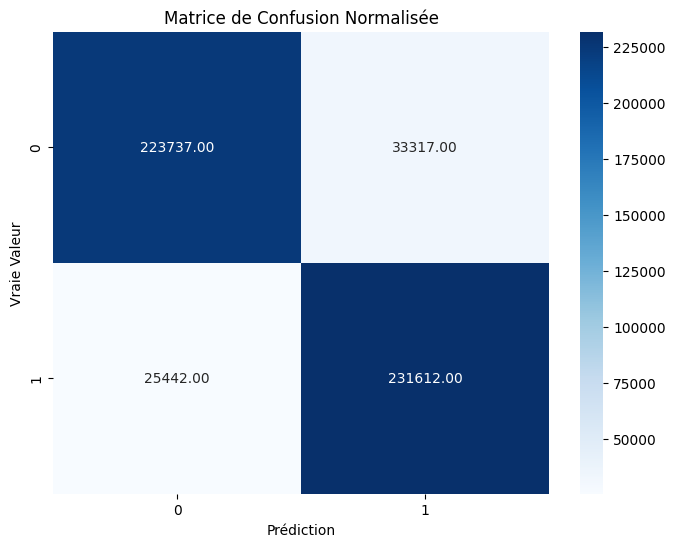

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      smote = SMOTE(sampling_strategy='auto')
      X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
      X_train=X_resampled
      y_train=y_resampled

      smote = SMOTE(sampling_strategy='auto')
      X_resampled, y_resampled = smote.fit_resample(X_val, y_val)
      X_val=X_resampled
      y_val=y_resampled

      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      logistic_regression = LogisticRegression(C=0.1, solver='liblinear', max_iter=1000)
      logistic_regression.fit(X_train, y_train)

      # Prédiction sur l'ensemble de test
      y_pred = logistic_regression.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


Accuracy: 0.88
Precision: 0.87
Recall: 0.90
F1 Score: 0.89
              precision    recall  f1-score   support

           0       0.90      0.87      0.88    257054
           1       0.87      0.90      0.89    257054

    accuracy                           0.88    514108
   macro avg       0.89      0.88      0.88    514108
weighted avg       0.89      0.88      0.88    514108



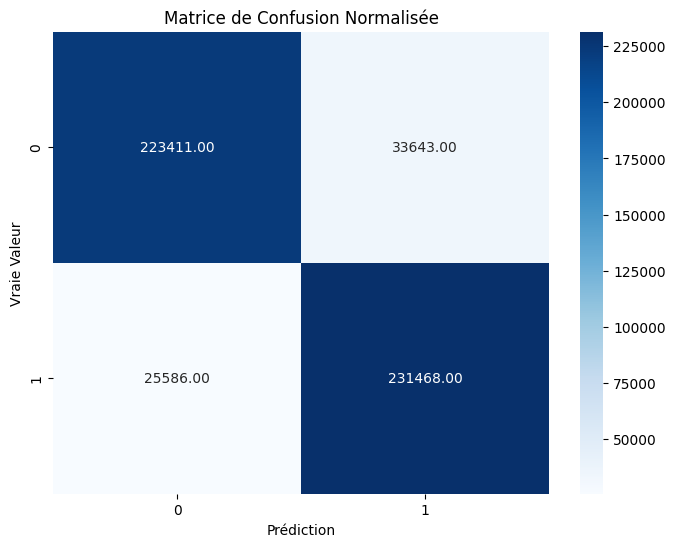

Accuracy: 0.88
Precision: 0.87
Recall: 0.89
F1 Score: 0.88
              precision    recall  f1-score   support

           0       0.89      0.87      0.88    257054
           1       0.87      0.89      0.88    257054

    accuracy                           0.88    514108
   macro avg       0.88      0.88      0.88    514108
weighted avg       0.88      0.88      0.88    514108



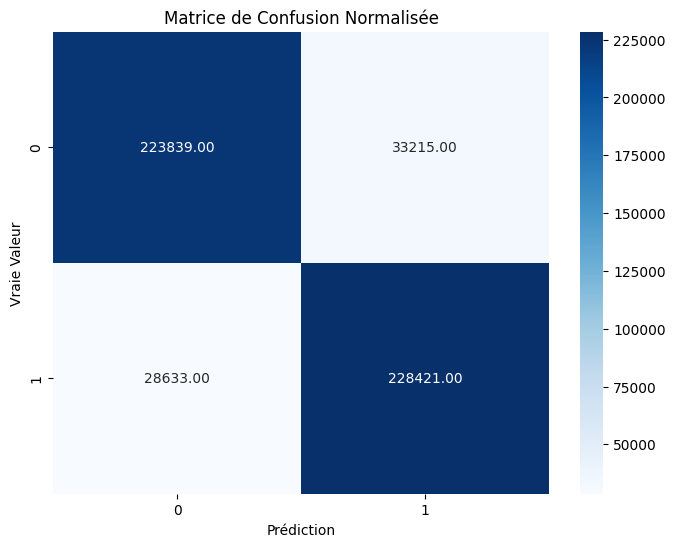

Accuracy: 0.89
Precision: 0.87
Recall: 0.91
F1 Score: 0.89
              precision    recall  f1-score   support

           0       0.91      0.87      0.89    257054
           1       0.87      0.91      0.89    257054

    accuracy                           0.89    514108
   macro avg       0.89      0.89      0.89    514108
weighted avg       0.89      0.89      0.89    514108



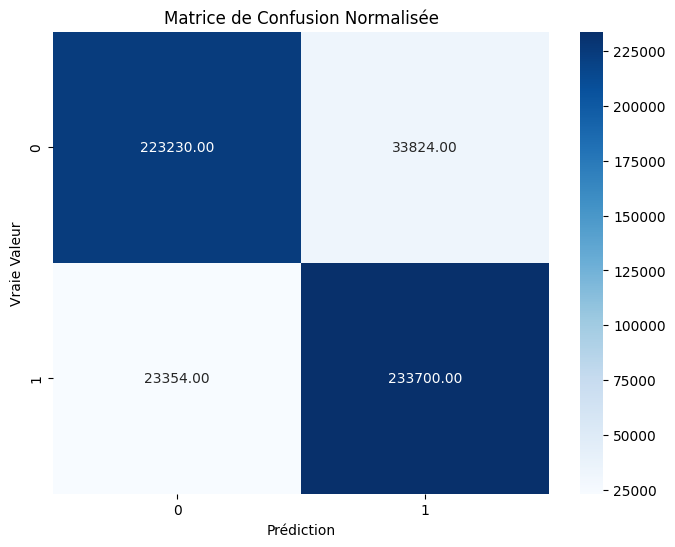

Accuracy: 0.89
Precision: 0.87
Recall: 0.90
F1 Score: 0.89
              precision    recall  f1-score   support

           0       0.90      0.87      0.89    257054
           1       0.87      0.90      0.89    257054

    accuracy                           0.89    514108
   macro avg       0.89      0.89      0.89    514108
weighted avg       0.89      0.89      0.89    514108



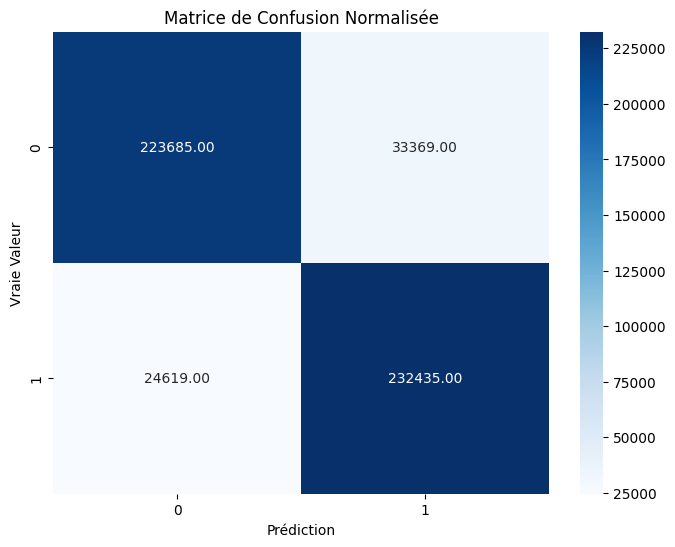

Accuracy: 0.89
Precision: 0.87
Recall: 0.90
F1 Score: 0.89
              precision    recall  f1-score   support

           0       0.90      0.87      0.88    257054
           1       0.87      0.90      0.89    257054

    accuracy                           0.89    514108
   macro avg       0.89      0.89      0.89    514108
weighted avg       0.89      0.89      0.89    514108



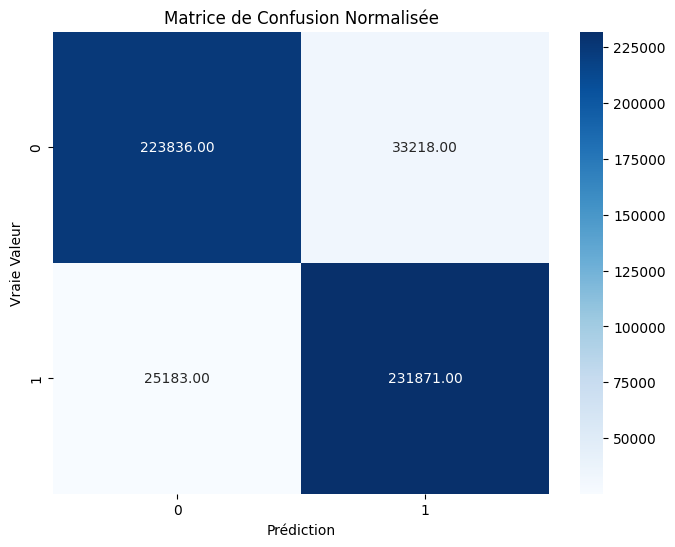

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      smote = SMOTE(sampling_strategy='auto')
      X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
      X_train=X_resampled
      y_train=y_resampled

      smote = SMOTE(sampling_strategy='auto')
      X_resampled, y_resampled = smote.fit_resample(X_val, y_val)
      X_val=X_resampled
      y_val=y_resampled

      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      logistic_regression = LogisticRegression(tol=1e-6,C=0.1, solver='liblinear', max_iter=1000)
      logistic_regression.fit(X_train, y_train)

      # Prédiction sur l'ensemble de test
      y_pred = logistic_regression.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

X = trainset.drop(columns=['fire'])
y = trainset['fire']

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      smote = SMOTE(sampling_strategy='auto')
      X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
      X_train=X_resampled
      y_train=y_resampled

      smote = SMOTE(sampling_strategy='auto')
      X_resampled, y_resampled = smote.fit_resample(X_val, y_val)
      X_val=X_resampled
      y_val=y_resampled

      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      svm_model = SVC(kernel='rbf',C=100,tol=1e-5,random_state=42)
      svm_model.fit(X_train, y_train)

      # Prédiction sur l'ensemble de test
      y_pred = svm_model.predict(X_test)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


svm:

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

# Création et entraînement du modèle SVM avec poids de classe personnalisés
svm_model = SVC(kernel='rbf',C=100,tol=1e-5,random_state=42)
svm_model.fit(X_train, y_train)

# Prédiction sur l'ensemble de test
y_pred = svm_model.predict(X_test)

# Évaluation du modèle
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()


In [ ]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# Création et entraînement du modèle SVM avec poids de classe personnalisés
from keras.models import Sequential
from keras.layers import Dense

# Créer le modèle séquentiel
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compiler le modèle
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


# Entraîner le modèle
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Prédiction sur l'ensemble de test
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Prédiction sur l'ensemble de test
y_pred = history.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()


Epoch 1/10
127302/127302 [==============================] - 508s 4ms/step - loss: 0.0980 - accuracy: 0.9676 - val_loss: 0.0993 - val_accuracy: 0.9682
Epoch 2/10
127302/127302 [==============================] - 479s 4ms/step - loss: 0.0572 - accuracy: 0.9836 - val_loss: 0.0676 - val_accuracy: 0.9786
Epoch 3/10
127302/127302 [==============================] - 470s 4ms/step - loss: 0.0480 - accuracy: 0.9868 - val_loss: 0.0712 - val_accuracy: 0.9782
Epoch 4/10
127302/127302 [==============================] - 478s 4ms/step - loss: 0.0431 - accuracy: 0.9883 - val_loss: 0.0639 - val_accuracy: 0.9820
Epoch 5/10
127302/127302 [==============================] - 487s 4ms/step - loss: 0.0399 - accuracy: 0.9894 - val_loss: 0.0562 - val_accuracy: 0.9839
Epoch 6/10
127302/127302 [==============================] - 509s 4ms/step - loss: 0.0376 - accuracy: 0.9901 - val_loss: 0.0653 - val_accuracy: 0.9803
Epoch 7/10
127302/127302 [==============================] - 472s 4ms/step - loss: 0.0357 - accuracy: